In [1]:
!python --version
import os
import warnings

#suppress warnings
warnings.filterwarnings('ignore')

Python 3.10.20


# Python libraries

In [2]:
import pandas as pd
import numpy as np
np.random.seed(42) ## for reproducibility --- this is important for the random number generation in the Bayesian model
import xarray as xr
xr.set_options(file_cache_maxsize=10)

import scipy as scipy
from scipy import stats
from scipy.optimize import curve_fit
import math
from scipy.stats import pearsonr, spearmanr, truncnorm
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor

import numpy as np
import pandas as pd


import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.patches import Circle

## for kriging plotting
from scipy.spatial import cKDTree
from pykrige.ok import OrdinaryKriging

import cartopy.crs as ccrs
import cmocean.cm as cmo

try:
    import proplot as plot
except ImportError:
    plot = None  # proplot is optional; install via: pip install proplot==0.9.7
import seaborn as sns
from shapely.geometry import Point, Polygon

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from ipywidgets import FloatRangeSlider, VBox
from IPython.display import display


from geopy.distance import distance, Distance, lonlat

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',
                    'font.weight': 'normal',
                    'axes.labelweight': 'normal',
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import string
import os
import requests
import io
from tqdm import tqdm
import time
from pathlib import Path


from cmdstanpy import CmdStanModel



# (Re)load your package
import TEXAS
# 1) Grab the low‐level functions you need
%load_ext autoreload
%autoreload 2
from TEXAS.stan.compiler import StanCompiler
from TEXAS.stan.sampler  import StanSampler
from TEXAS.stan.sampler import get_posterior, save_posterior
from TEXAS.stan.io import load_posterior
from TEXAS import predict_T_from_RI, predict_RI_from_T
from TEXAS.ensemble import generate_ensemble_auto
from TEXAS.data import MahalanobisOutlierDetector, build_invT_inputData, build_fwd_data
from TEXAS.plotting import *

import TEXAS
print(TEXAS.__version__)  

import importlib

import bayspline as bsl
import bayspar as bsr

from functools import partial

0.1.4


# Cosmetic settings

In [3]:
datatype_color_dict = {
    'coretop':'cyan9',
    'culture':'yellow9',
    'mesocosm':'pink9',
    'culmeso':'violet9',
    'culmesocore':'gray9',
}

datatype_marker_dict = {
    'culture':'^',
    'mesocosm':'s',
    'coretop':'.',
}

datatype2_color_dict = {
    'coretop_high23ratio':'cyan9',
    'coretop_low23ratio':'cyan3',
    'culture':'yellow9',
    'mesocosm':'pink9',
    'culmeso':'violet9',
    'culmesocore':'gray9',
}

period_color_dict = {
    'Quaternary':'#f8f987',
    'Neogene':'#f7e73d',
    'Paleogene':'#e59c59',
    'Cretaceous':'#96c657',
    'Jurassic':'#6db1c7'
}

def label_pvalues(x):
    if x<0.001:
        return r'$\it{P}$<.001'
    elif x<0.01:
        return r'$\it{P}$<.01'
    elif x<0.05:
        return r'$\it{P}$<.05'
    elif x<0.1:
        return r'$\it{P}$<.1'
    elif x>=0.1:
        return r'$\it{P}$>.1'

# Miscellaneous functions

In [4]:
def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,loN_meso = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(loN_meso,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    loN_cul, lat1 = origin
    loN_meso, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(loN_meso - loN_cul)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.ataN_meso(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient


import inspect
from IPython.display import Markdown
def display_function_signature(func):
    sig = inspect.signature(func)
    params = []
    for param_name, param in sig.parameters.items():
        if param.default != inspect.Parameter.empty:
            params.append(f"    {param_name}={param.default}")
        else:
            params.append(f"    {param_name}")

    formatted = f"{func.__name__}(\n" + ",\n".join(params) + "\n)"
    return Markdown(f"```python\n{formatted}\n```")

In [5]:
def predictSSTfromTEX(input_tex,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouten02, schouten03, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten02':(66.6667,-18.6667),
        'schouten03':(37.0370,0.5926),
        'kim2008':(56.2000,-10.7800),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrien17':(58.8235,-11.1765),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if method_name=='kim2010_tex86H':
        predictor = np.log10(input_tex)
    elif method_name=='liu2009':
        predictor = (1/input_tex)
    elif 'lnTEX' in method_name:
        predictor = np.log(input_tex)
    else:
        predictor = input_tex
        
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    
    predictedSST = slope*predictor+yintercept
    return predictedSST

def predictTEXfromSST(input_sst,method_name='kim2010_tex86H'):
    '''
    
    available methods:

    linear: schouten02, schouten03, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten02':(0.015,0.280),
        'schouten03':(0.027,-0.016),
        'kim2008':(0.017794,0.191815),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrien17':(0.021,0.105), #(0.021,0.105)  <--- recalculated from the Fig S2 in O'Brien et al., 2017 | (0.0170,0.19) <--- shown in the main text of O'Brien et al., 2017
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if 'lnTEX' in method_name:
        predictor = np.log(input_sst)
    else:
        predictor = input_sst
    
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    if method_name=='liu2009':
        predictedTEX = 1/(slope*predictor+yintercept)
    elif method_name=='kim2010_tex86H':
        predictedTEX = 10**((predictor-yintercept)/slope)
    else:
        predictedTEX = slope*predictor+yintercept
    return predictedTEX

In [6]:
# ── sig-fig helpers (self-contained) ─────────────────────────────────────────

def _n_decimals(scale: float) -> int:
    """Decimal places needed to show `scale` to 1-2 sig figs (GUM §7.2.6)."""
    if not math.isfinite(scale) or scale <= 0:
        return 3
    mag = math.floor(math.log10(abs(scale)))
    first_digit = int(abs(scale) / 10 ** mag)
    return max(0, 1 - mag) if first_digit <= 3 else max(0, -mag)


def _format_stat(median: float, std: float, fmt: str | None = None) -> str:
    """Return 'median ± std' formatted to appropriate significant figures.
    Uncertainty drives precision: 1 sig fig on std (2 if leading digit <= 3).

    Parameters
    ----------
    fmt : str or None
        Optional format spec override (e.g. ``'.3f'``, ``'.2e'``).
        When given, both median and std are formatted with this spec and
        the automatic sig-fig logic is bypassed entirely.
    """
    if fmt is not None:
        return f"{median:{fmt}} ± {std:{fmt}}"
    if not math.isfinite(std) or std <= 0:
        return f"{median:.3g}"
    n_dec = _n_decimals(std)
    fmt   = f".{n_dec}f"
    return f"{round(median, n_dec):{fmt}} ± {round(std, n_dec):{fmt}}"


# ── formatting helpers ────────────────────────────────────────────────────────

def _fmt_r2(r2: float) -> str:
    """R² precision driven by unexplained variance; capped at 3 d.p."""
    n = min(_n_decimals(1 - r2), 3)
    return f"{round(r2, n):.{n}f}"


def _fmt_rmse(rmse: float) -> str:
    """RMSE always reported to 2 sig figs."""
    mag = math.floor(math.log10(abs(rmse)))
    n   = max(0, 1 - mag)
    return f"{round(rmse, n):.{n}f}"


def _fmt_delta_r2(dr2: float) -> str:
    if abs(dr2) == 0:
        return f"{dr2:.3f}"
    n = _n_decimals(abs(dr2))
    return f"{round(dr2, n):.{n}f}"


def _fmt_p(p: float) -> str:
    if p < 0.001:
        return "<0.001"
    mag = math.floor(math.log10(abs(p)))
    return f"{round(p, -mag + 1):.2e}"


def _fmt_coef(coef: float, ci_halfwidth: float) -> str:
    """coef ± 95% CI, precision driven by CI half-width."""
    sigma = ci_halfwidth / 1.96
    return _format_stat(coef, sigma)


def _fmt_delta(delta: float) -> str:
    """Delta to 2 sig figs with sign."""
    if abs(delta) == 0:
        return "+0.000"
    d_mag = math.floor(math.log10(abs(delta)))
    nd    = max(0, 1 - d_mag)
    return f"{delta:+.{nd}f}"


## Logistic equations

In [7]:
def logistic(x, x0, k, L, b):
    return L / (1 + np.exp(-k * (x - x0))) + b

def logistic_fixed_upper(x, x0, k, b):
    return (1-b) / (1 + np.exp(-k * (x - x0))) + b

def inverse_logistic_fixed_upper(y, x0, k, b):
    return x0 + (np.log((1 - b)/y - 1) / -k)


def generalized_logistic_model(x, x0, a, b, k, v):
    """
    Generalized logistic model function.

    Parameters:
    - x0: Inflection point
    - a: Upper asymptote (right asymptote), default=1
    - b: Lower asymptote (left asymptote)
    - c: Typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    - k: Slope
    - v: Shape parameter
    - Q: Exponent
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = b + ((a - b) / np.power(1 + np.exp(-k * (x - x0)), 1/v))
    return Y

def generalized_logistic_model_fixed_upper(x, x0, b, k, v):
    """
    Generalized logistic model function.

    Parameters:
    - x0: Inflection point
    - a: Upper asymptote (right asymptote), default=1
    - b: Lower asymptote (left asymptote)
    - c: Typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    - k: Slope
    - v: Shape parameter
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = b + ((1 - b) / np.power(1 + np.exp(-k * (x - x0)), 1/v))
    return Y

def inverse_generalized_logistic_model_fixed_upper(y, x0, b, k, v):
    """
    Inverse of the generalized logistic model function with a fixed upper asymptote.
    Parameters:
    - y: The output value for which to compute the inverse.
    - x0: Inflection point
    - b: Lower asymptote (left asymptote)
    - k: Slope
    - v: Shape parameter
    Returns:
    - The input value x corresponding to the output y in the generalized logistic model.
    """
    term = ((1 - b) / (y - b))**v - 1
    x = x0 - (np.log(term) / k)
    return x

In [8]:
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

# Set local path

In [9]:
from pathlib import Path
from cmdstanpy import set_cmdstan_path, cmdstan_path
from TEXAS.utils.paths import CMDSTAN_DIR

set_cmdstan_path(str(CMDSTAN_DIR))
print("Set CMDSTAN ->", cmdstan_path())

# Detect environment
IN_DOCKER = Path("/home/micromamba/app").exists()

if IN_DOCKER:
    local_onedrive_path = Path("/mnt/onedrive")
    local_github_path = Path("/home/micromamba/app")
    print(local_github_path)
else:
    local_onedrive_path = Path.home() / "OneDrive"   # adjust if needed
    local_github_path = Path.home() / "Documents/GitHub/TEXAS"
    print(local_github_path)

Set CMDSTAN -> /opt/cmdstan/cmdstan-2.36.0
/home/micromamba/app


In [10]:
### Regression dataset compilation
fpath = os.path.join(local_github_path,'data/spreadsheets')
fname = r'ds_gridded_screened_global_compilation_finalized.csv'

gridded_combined_df = pd.read_csv(os.path.join(fpath, fname))
gridded_combined_df

,match_lat_04deg,match_lon_04deg,regionName,reference_name,datatype,Strains,organism_commonName,organism_broadClass,organism_broadClass2,organism_broadClass3,...,thermoNO3_se,weighted_tex,weighted_tex_cren2,weighted_tex_cren3,weighted_tex_cren5,ocean_region_id,ocean_region,ocean_region_abbrev,pred_scaledRI_cren3,scaledRI_cren3_res
0,-77.875,-40.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.158812,1.761114,1.533491,1.647303,1.874926,24.0,Weddell Sea,Weddell Sea,0.457926,0.053892
1,-77.375,-158.375,Ross Sea,Kim2010,coretop,coretop,coretop,coretop,coretop,coretop,...,0.000000,1.575668,1.421365,1.498516,1.652819,27.0,Ross Sea,Ross Sea,0.458010,-0.016332
2,-77.125,-45.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.131073,1.648903,1.464398,1.556650,1.741155,24.0,Weddell Sea,Weddell Sea,0.457896,-0.044579
3,-76.625,-35.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.158812,1.547138,1.425926,1.486532,1.607744,24.0,Weddell Sea,Weddell Sea,0.458058,-0.022778
4,-76.375,-33.875,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.041285,1.604469,1.425698,1.515084,1.693855,24.0,Weddell Sea,Weddell Sea,0.457869,-0.008493
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1571,NaN,NaN,mesocosm,Wuchter2004,mesocosm,mesocosm,NorthSea_mesocosm,NorthSea_mesocosm,mesocosm,mesocosm,...,NaN,1.673550,1.594122,1.633836,1.713264,NaN,NaN,NaN,0.624380,0.065443
1572,NaN,NaN,mesocosm,Schouten2007,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm,...,NaN,1.793452,1.683386,1.738419,1.848485,NaN,NaN,NaN,0.669433,-0.032805
1573,NaN,NaN,mesocosm,Schouten2007,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm,...,NaN,2.269506,1.779857,2.024682,2.514331,NaN,NaN,NaN,0.771095,-0.096599
1574,NaN,NaN,mesocosm,Schouten2007,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm,...,NaN,2.414045,1.989968,2.202006,2.626083,NaN,NaN,NaN,0.820891,0.095499


In [11]:
gridded_combined_df.groupby('organism_broadClass4').describe()['TEX86']

,count,mean,std,min,25%,50%,75%,max
organism_broadClass4,,,,,,,,
Coretop,1513.0,0.522263,0.128165,0.293000,0.410686,0.507700,0.628371,0.886000
Group 1.1b,12.0,0.878518,0.188628,0.320388,0.861690,0.943443,0.986874,0.994442
Marine Group 1.1a,33.0,0.522152,0.112942,0.339403,0.444356,0.508786,0.592257,0.767980
Mesocosm,8.0,0.591488,0.178141,0.334578,0.476640,0.608391,0.721737,0.813041
Non-marine Group 1.1a,10.0,0.586409,0.140227,0.320388,0.517301,0.592712,0.641534,0.806931


In [12]:
def pred_texRI_fn(x, method_name='zhang16'):
    """
    Predicts the ring index (RI) based on the TEX86 value using the Zhang16 method.
    
    Parameters:
    x (float or array-like): The TEX86 value(s).
    method_name (str): The method to use for prediction. Default is 'zhang16'.
    
    Returns:
    float or array-like: The predicted ring index (RI) value(s).
    """
    if method_name == 'zhang16':
        return -0.77 * x + 3.32 * x**2 + 1.59
    elif method_name == 'linear_thisStudy':
        return 3.1517 * x + 0.5808
    elif method_name == 'exp_thisStudy':
        return np.exp(1.4352 * x + 0.0244)
        
    else:
        raise ValueError(f"Method '{method_name}' is not implemented.")

# Calibration posteriors

In [13]:
# # Save data for Stan
# y_params = ['scaledRI','scaledRI_cren3']
# for y_param in y_params:
#     cul_df = gridded_combined_df[gridded_combined_df['datatype']=='culture'].dropna(subset=[y_param,'SST']).reset_index(drop=True)
#     meso_df = gridded_combined_df[gridded_combined_df['datatype']=='mesocosm'].dropna(subset=[y_param,'SST']).reset_index(drop=True)
#     data = build_fwd_data(
#         t_cul = cul_df['SST'].values,
#         proxy_cul = cul_df[y_param].values,
#         t_meso = meso_df['SST'].values,
#         proxy_meso = meso_df[y_param].values,
#     )

#     stan_file_name = 'gen_logi_fixed_culmeso'
#     gen_logi_fixed_cul_meso_post_ds, diag = get_posterior(
#                                                 data=data, 
#                                                 proxy_name=y_param,
#                                                 stan_file=stan_file_name,
#                                                 temptype='cultureT')


#     # Save posteriors
#     save_posterior(gen_logi_fixed_cul_meso_post_ds,filename_suffix="_032326")



In [14]:
# legend_labels = ['Top layer: Culture + Mesocosm (T) | scaledRI', 
#                  'Top layer: Culture + Mesocosm (T) | scaledRI_cren3',
#                  'Prior']
# # ── Forward posteriors from 032326 run ────────────────────────────────────────                                                                                                                 
# post_fwd_032326 = [
#     "gen_logi_fixed_culmeso_cultureT_scaledRI_cren3_032326",                                                                                              
# ]  

# fig, axs = plot_prior_distributions(
#     posterior_datasets=post_fwd_032326,
#     posterior_labels_list=legend_labels,
#     use_linestyle_by_param=True,
#     show_histogram=False,
#     set_leg_max_ncol=1,
#     set_fig_height_factor=3,
#     show_suptitle=False,
#     show_annotation=True,
#     show_subplot_legend=False,
#     show_figure_legend=False,
#     show_prior_expression=True,
# )

# axs[0,0].set_xlim(25,45)
# axs[0,0].set_ylim(0,0.2)
# # axs[0,1].set_xlim(0,0.4)
# # axs[0,2].set_xlim(0.38,0.46)
# # axs[1,0].set_xlim(0,6)
# # axs[1,0].set_ylim(0,1)
# # axs[1,1].set_xlim(0,6)
# axs[1,1].set_ylim(0,0.5)
# axs[1,2].set_xlim(-0.01,0)
# axs[1,2].set_ylim(0,1200)
# fig.tight_layout()

# for ax in axs.flatten():
    
#     ax.set_xlabel(ax.get_xlabel(), fontsize=14, color='gray7', fontweight='bold')
#     ax.set_ylabel(ax.get_ylabel(), fontsize=14, color='gray7', fontweight='bold')
    
#     # ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, color='gray7')
#     # ax.set_yticklabels(ax.get_yticklabels(), fontsize=12, color='gray7')
    
#     ax.spines[:].set_color('gray7')
    
    
#     ax.grid(False)
#     ax.set_ylim(bottom=0)
    
# h, l = axs[0,0].get_legend_handles_labels()
# fig.legend(h,['Prior','Top layer: Culture + Mesocosm (T)'],bbox_to_anchor=(0.65, 0.47))
# # Later in notebook
# fig.savefig("posterior_check.png", dpi=300)
# fig.set_facecolor("white")  # or whatever you want
# fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
# fig.savefig(os.path.join(fpath,'AppendixA_culmesoT_prior_distributions.pdf'),dpi=300,tight_layout=True,)

# Coretop analysis

In [15]:
coretop_df = gridded_combined_df[gridded_combined_df['datatype']=='coretop'].dropna(subset=['no3_sf2tc_avg', 'SST']).reset_index(drop=True)
coretop_df

,match_lat_04deg,match_lon_04deg,regionName,reference_name,datatype,Strains,organism_commonName,organism_broadClass,organism_broadClass2,organism_broadClass3,...,thermoNO3_se,weighted_tex,weighted_tex_cren2,weighted_tex_cren3,weighted_tex_cren5,ocean_region_id,ocean_region,ocean_region_abbrev,pred_scaledRI_cren3,scaledRI_cren3_res
0,-77.875,-40.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.158812,1.761114,1.533491,1.647303,1.874926,24.0,Weddell Sea,Weddell Sea,0.457926,0.053892
1,-77.375,-158.375,Ross Sea,Kim2010,coretop,coretop,coretop,coretop,coretop,coretop,...,0.000000,1.575668,1.421365,1.498516,1.652819,27.0,Ross Sea,Ross Sea,0.458010,-0.016332
2,-77.125,-45.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.131073,1.648903,1.464398,1.556650,1.741155,24.0,Weddell Sea,Weddell Sea,0.457896,-0.044579
3,-76.625,-35.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.158812,1.547138,1.425926,1.486532,1.607744,24.0,Weddell Sea,Weddell Sea,0.458058,-0.022778
4,-76.375,-33.875,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.041285,1.604469,1.425698,1.515084,1.693855,24.0,Weddell Sea,Weddell Sea,0.457869,-0.008493
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1508,84.125,46.625,Arctic Ocean,Kim2008,coretop,coretop,coretop,coretop,coretop,coretop,...,0.013632,1.680000,1.445333,1.562667,1.797333,0.0,Arctic Ocean,Arctic Ocean,0.458021,-0.007687
1509,84.875,40.625,Arctic Ocean,Kim2008,coretop,coretop,coretop,coretop,coretop,coretop,...,0.257496,1.635830,1.424415,1.530122,1.741537,0.0,Arctic Ocean,Arctic Ocean,0.457931,-0.013009
1510,86.875,-146.125,Arctic Ocean,Ho2014,coretop,coretop,coretop,coretop,coretop,coretop,...,0.022468,1.987319,1.454710,1.721014,2.253623,0.0,Arctic Ocean,Arctic Ocean,0.457974,-0.049640
1511,87.125,104.625,Arctic Ocean,Ho2014,coretop,coretop,coretop,coretop,coretop,coretop,...,0.037861,2.089165,1.560948,1.825056,2.353273,0.0,Arctic Ocean,Arctic Ocean,0.457878,-0.017178


In [16]:
np.percentile(load_posterior("gen_logi_fixed_hier_crtp_univ_priorApprox_SST_scaledRI_032326")["R2_full"].values.flatten(),50)

0.718402

In [17]:
# temp_params = ['SST','t_sf2tc_avg']
# y_params = ['scaledRI','scaledRI_cren3']
# reg_data = coretop_df[[*temp_params, *y_params]].dropna()   

# for temp_param in temp_params:
#     for y_param in y_params:                 
#         # Load the matching culmeso posterior for this proxy
#         # (saved in stage 1 with suffix from save_posterior filename)                                                                                                                
#         culmeso_post = load_posterior(       
#             f"gen_logi_fixed_culmeso_cultureT_{y_param}_032326"                                                                                                                      
#         )                                    
                    
#         data = build_fwd_data(               
#             t_crtp=reg_data[temp_param].values,
#             proxy_crtp=reg_data[y_param].values,                                                                                                                                     
#             culmeso_posterior=culmeso_post,   # auto-extracts hyperpriors                                                                                                            
#         )                                    
                                            
#         gen_logi_crtp_post_ds, diag = get_posterior(                                                                                                                                 
#             data=data,
#             proxy_name=y_param,              
#             stan_file='gen_logi_fixed_hier_crtp_univ_priorApprox',
#             temptype={'t_sf2tc_avg':'thermoT'}.get(temp_param,temp_param),                  
#         )                                    
#         save_posterior(gen_logi_crtp_post_ds, filename_suffix="_032326")  

In [19]:
# temp_params = ['SST','t_sf2tc_avg']
# y_params = ['scaledRI','scaledRI_cren3']
# secondary_predictors = ['gdgt23ratio']
# reg_data = coretop_df[[*temp_params, *y_params, *secondary_predictors]].dropna()   

# for temp_param in temp_params:
#     for y_param in y_params:                 
#         # Load the matching culmeso posterior for this proxy
#         # (saved in stage 1 with suffix from save_posterior filename)                                                                                                                
#         culmeso_post = load_posterior(       
#             f"gen_logi_fixed_culmeso_cultureT_{y_param}_032326"                                                                                                                      
#         )                                    
                    
#         data = build_fwd_data(               
#             t_crtp=reg_data[temp_param].values,
#             proxy_crtp=reg_data[y_param].values,
#             gdgt23ratio_crtp=reg_data['gdgt23ratio'].values,                                                                                                     
#             culmeso_posterior=culmeso_post,   # auto-extracts hyperpriors                                                                                                            
#         )                                    
                                            
#         gen_logi_crtp_post_ds, diag = get_posterior(                                                                                                                                 
#             data=data,
#             proxy_name=y_param,              
#             stan_file = 'gen_logi_fixed_hier_crtp_multiv_priorApprox' if secondary_predictors else 'gen_logi_fixed_hier_crtp_univ_priorApprox',
#             temptype={'t_sf2tc_avg':'thermoT'}.get(temp_param,temp_param),   
                           
#         )                                    
#         save_posterior(gen_logi_crtp_post_ds, filename_suffix="_032326")  

In [20]:
# temp_params = ['SST','t_sf2tc_avg']
# y_params = ['scaledRI','scaledRI_cren3']
# secondary_predictors = ['no3_sf2tc_avg']
# reg_data = coretop_df[[*temp_params, *y_params, *secondary_predictors]].dropna()   

# for temp_param in temp_params:
#     for y_param in y_params:                 
#         # Load the matching culmeso posterior for this proxy
#         # (saved in stage 1 with suffix from save_posterior filename)                                                                                                                
#         culmeso_post = load_posterior(       
#             f"gen_logi_fixed_culmeso_cultureT_{y_param}_032326"                                                                                                                      
#         )                                    
                    
#         data = build_fwd_data(               
#             t_crtp=reg_data[temp_param].values,
#             proxy_crtp=reg_data[y_param].values,
#             no3_crtp=reg_data['no3_sf2tc_avg'].values,                                                                                                     
#             culmeso_posterior=culmeso_post,   # auto-extracts hyperpriors  
#             no3_cutoff=1.8                                                              
#         )                                    
                                              
#         gen_logi_crtp_post_ds, diag = get_posterior(                                                                                                                                 
#             data=data,
#             proxy_name=y_param,
#             stan_file = 'gen_logi_fixed_hier_crtp_multiv_priorApprox' if secondary_predictors else 'gen_logi_fixed_hier_crtp_univ_priorApprox',
#             temptype={'t_sf2tc_avg':'thermoT'}.get(temp_param,temp_param),   
                           
#         )                                    
#         save_posterior(gen_logi_crtp_post_ds, filename_suffix="_032326")  

In [21]:
# temp_params = ['SST','t_sf2tc_avg']
# y_params = ['scaledRI','scaledRI_cren3']
# secondary_predictors = ['no3_sf2tc_avg']
# reg_data = coretop_df[[*temp_params, *y_params, *secondary_predictors]].dropna()   

# for temp_param in temp_params:
#     for y_param in y_params:                 
#         # Load the matching culmeso posterior for this proxy
#         # (saved in stage 1 with suffix from save_posterior filename)                                                                                                                
#         culmeso_post = load_posterior(       
#             f"gen_logi_fixed_culmeso_cultureT_{y_param}_032326"                                                                                                                      
#         )                                    
                    
#         data = build_fwd_data(               
#             t_crtp=reg_data[temp_param].values,
#             proxy_crtp=reg_data[y_param].values,
#             no3_crtp=reg_data['no3_sf2tc_avg'].values,                                                                                                     
#             culmeso_posterior=culmeso_post,   # auto-extracts hyperpriors  
#             no3_cutoff=1.0
                                                                                                                      
#         )                                    
                                              
#         gen_logi_crtp_post_ds, diag = get_posterior(                                                                                                                                 
#             data=data,
#             proxy_name=y_param,
#             stan_file = 'gen_logi_fixed_hier_crtp_multiv_priorApprox' if secondary_predictors else 'gen_logi_fixed_hier_crtp_univ_priorApprox',
#             temptype={'t_sf2tc_avg':'thermoT'}.get(temp_param,temp_param),   
                           
#         )                                    
#         save_posterior(gen_logi_crtp_post_ds, filename_suffix="_032326")  

In [22]:
# temp_params = ['SST','t_sf2tc_avg']
# y_params = ['scaledRI','scaledRI_cren3']
# secondary_predictors = ['no3_sf2tc_avg','gdgt23ratio']
# reg_data = coretop_df[[*temp_params, *y_params, *secondary_predictors]].dropna()   

# for temp_param in temp_params:
#     for y_param in y_params:                 
#         # Load the matching culmeso posterior for this proxy
#         # (saved in stage 1 with suffix from save_posterior filename)                                                                                                                
#         culmeso_post = load_posterior(       
#             f"gen_logi_fixed_culmeso_cultureT_{y_param}_032326"                                                                                                                      
#         )                                    
                    
#         data = build_fwd_data(               
#             t_crtp=reg_data[temp_param].values,
#             proxy_crtp=reg_data[y_param].values,
#             gdgt23ratio_crtp=reg_data['gdgt23ratio'].values,   
#             no3_crtp=reg_data['no3_sf2tc_avg'].values,                                                                                                     
#             culmeso_posterior=culmeso_post,   # auto-extracts hyperpriors  
#             no3_cutoff=1.8                                                                                                           
#         )                                    
                                            
#         gen_logi_crtp_post_ds, diag = get_posterior(                                                                                                                                 
#             data=data,
#             proxy_name=y_param,              
#             stan_file = 'gen_logi_fixed_hier_crtp_multiv_priorApprox' if secondary_predictors else 'gen_logi_fixed_hier_crtp_univ_priorApprox',
#             temptype={'t_sf2tc_avg':'thermoT'}.get(temp_param,temp_param),   
                           
#         )                                    
#         save_posterior(gen_logi_crtp_post_ds, filename_suffix="_032326")  

In [23]:
# temp_params = ['SST','t_sf2tc_avg']
# y_params = ['scaledRI','scaledRI_cren3']
# secondary_predictors = ['no3_sf2tc_avg','gdgt23ratio']
# reg_data = coretop_df[[*temp_params, *y_params, *secondary_predictors]].dropna()   

# for temp_param in temp_params:
#     for y_param in y_params:                 
#         # Load the matching culmeso posterior for this proxy
#         # (saved in stage 1 with suffix from save_posterior filename)                                                                                                                
#         culmeso_post = load_posterior(       
#             f"gen_logi_fixed_culmeso_cultureT_{y_param}_032326"                                                                                                                      
#         )                                    
                    
#         data = build_fwd_data(               
#             t_crtp=reg_data[temp_param].values,
#             proxy_crtp=reg_data[y_param].values,
#             gdgt23ratio_crtp=reg_data['gdgt23ratio'].values,   
#             no3_crtp=reg_data['no3_sf2tc_avg'].values,                                                                                                     
#             culmeso_posterior=culmeso_post,   # auto-extracts hyperpriors  
#             no3_cutoff=1.0                                                                                                           
#         )                                    
                                            
#         gen_logi_crtp_post_ds, diag = get_posterior(                                                                                                                                 
#             data=data,
#             proxy_name=y_param,              
#             stan_file = 'gen_logi_fixed_hier_crtp_multiv_priorApprox' if secondary_predictors else 'gen_logi_fixed_hier_crtp_univ_priorApprox',
#             temptype={'t_sf2tc_avg':'thermoT'}.get(temp_param,temp_param),   
                           
#         )                                    
#         save_posterior(gen_logi_crtp_post_ds, filename_suffix="_032326")  

In [24]:
# temp_params = ['SST', 't_sf2tc_avg']                                                                                                                          
# y_params = ['scaledRI', 'scaledRI_cren3']                                                                                                                            
# secondary_predictors = ['no3_sf2tc_avg', 'gdgt23ratio']                                                                                                              
                            
# # ── Add SD columns alongside the predictors ──────────────────────────────                                                                                          
# reg_data = coretop_df[[      
#     *temp_params, *y_params, *secondary_predictors,                                                                                                                  
#     'gdgt23ratio_se',       # per-site SE of G₂/₃ (same units as gdgt23ratio)
#     'thermoNO3_se',     # per-site SE of NO₃ (µmol/L)                                                                                                            
# ]].dropna()
                            
# for temp_param in temp_params:
#     for y_param in y_params: 
#         culmeso_post = load_posterior(
#             f"gen_logi_fixed_culmeso_cultureT_{y_param}_032326"
#         )                    

#         data = build_fwd_data(                                                                                                                                       
#             t_crtp=reg_data[temp_param].values,
#             proxy_crtp=reg_data[y_param].values,
#             gdgt23ratio_crtp=reg_data['gdgt23ratio'].values,
#             sd_gdgt23ratio_crtp=reg_data['gdgt23ratio_se'].values,     # ← new                                                                                       
#             no3_crtp=reg_data['no3_sf2tc_avg'].values,
#             sd_no3_crtp=reg_data['thermoNO3_se'].values,           # ← new                                                                                       
#             culmeso_posterior=culmeso_post,
#             no3_cutoff=1.0,
#             no3_eiv_cv_max=100.0,   # effectively no gate — all sub-threshold sites get EIV 
#         )       
                            
#         gen_logi_crtp_post_ds, diag = get_posterior(
#             data=data,
#             proxy_name=y_param,
#             stan_file='gen_logi_fixed_hier_crtp_multiv_priorApprox_werr',  # ← new                                                                                   
#             temptype={'t_sf2tc_avg': 'thermoT'}.get(temp_param, temp_param),
#         )                    
#         save_posterior(gen_logi_crtp_post_ds, filename_suffix="_041526_werr_new")  # ← distinguish output


In [25]:
# temp_params = ['SST', 't_sf2tc_avg']
# y_params = ['scaledRI', 'scaledRI_cren3']
# secondary_predictors = ['no3_sf2tc_avg', 'gdgt23ratio']                                                                                         
                    
# reg_data = coretop_df[[                                                                                                                         
#     *temp_params, *y_params, *secondary_predictors,                                                                                             
#     'gdgt23ratio_se',                                                                                                                           
#     'thermoNO3_se',                                                                                                                             
# ]].dropna()                                                                                                                                     
                
# stan_models = [
#     'gen_logi_fixed_hier_crtp_multiv_priorApprox_werr',  # latent-var EIV, fixed prior (updated)
#     'gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv',   # same + CV-gated EIV (new)                                                            
# ]       
        
# for temp_param in temp_params:                                                                                                                  
#     for y_param in y_params:
#         culmeso_post = load_posterior(
#             f"gen_logi_fixed_culmeso_cultureT_{y_param}_032326"
#         )                                                                                                                                       

#         data = build_fwd_data(                                                                                                                  
#             t_crtp=reg_data[temp_param].values,
#             proxy_crtp=reg_data[y_param].values,
#             gdgt23ratio_crtp=reg_data['gdgt23ratio'].values,
#             sd_gdgt23ratio_crtp=reg_data['gdgt23ratio_se'].values,                                                                              
#             no3_crtp=reg_data['no3_sf2tc_avg'].values,
#             sd_no3_crtp=reg_data['thermoNO3_se'].values,                                                                                        
#             no3_eiv_cv_max=0.3,   # CV gate: moves high-uncertainty sites to exact
#             culmeso_posterior=culmeso_post,                                                                                                     
#             no3_cutoff=1.0,
#         )                                                                                                                                       
        
#         for stan_model in stan_models:
#             model_tag = stan_model.split('_priorApprox_')[-1]  # 'werr' or 'eiv'                                                                
#             post, diag = get_posterior(                                                                                                         
#                 data=data,
#                 proxy_name=y_param,                                                                                                             
#                 stan_file=stan_model,                                                                                                           
#                 temptype={'t_sf2tc_avg': 'thermoT'}.get(temp_param, temp_param),
#             )                                                                                                                                   
#             save_posterior(post, filename_suffix=f"_041526_{model_tag}")


In [26]:
# temp_params = ['SST', 't_sf2tc_avg']                                                                                                                                 
# y_params = ['scaledRI', 'scaledRI_cren3']                                                                                                                            
# secondary_predictors = ['no3_sf2tc_avg', 'gdgt23ratio']                                                                                                              
                            
# # ── Add SD columns alongside the predictors ──────────────────────────────                                                                                          
# reg_data = coretop_df[[      
#     *temp_params, *y_params, *secondary_predictors,                                                                                                                  
#     'gdgt23ratio_se',       # per-site SE of G₂/₃ (same units as gdgt23ratio)
#     'thermoNO3_se',     # per-site SE of NO₃ (µmol/L)                                                                                                            
# ]].dropna()

# for temp_param in temp_params:
#     for y_param in y_params:

#         data = build_fwd_data(
#             t_cul=cul_df["SST"].values,
#             proxy_cul=cul_df["scaledRI_cren3"].values,
#             t_meso=meso_df["SST"].values,
#             proxy_meso=meso_df["scaledRI_cren3"].values,
#             t_crtp=reg_data[temp_param].values,
#             proxy_crtp=reg_data[y_param].values,
#             gdgt23ratio_crtp=reg_data["gdgt23ratio"].values,
#             sd_gdgt23ratio_crtp=reg_data["gdgt23ratio_se"].values,
#             no3_crtp=reg_data["no3_sf2tc_avg"].values,
#             sd_no3_crtp=reg_data["thermoNO3_se"].values,
#             no3_cutoff=1.0,
#         )

#         gen_logi_crtp_post_ds, diag = get_posterior(
#             data=data,
#             proxy_name=y_param,
#             stan_file="gen_logi_fixed_hier_crtp_multiv_odr",
#             temptype={"t_sf2tc_avg": "thermoT"}.get(temp_param, temp_param),
#         )

#         save_posterior(gen_logi_crtp_post_ds, filename_suffix="_041526_odr")         

In [27]:
temp_params = ['SST', 't_sf2tc_avg']                                                                                                                          
y_params = ['scaledRI', 'scaledRI_cren3']                                                                                                                            
secondary_predictors = ['no3_sf2tc_avg', 'gdgt23ratio']                                                                                                              
                            
# ── Add SD columns alongside the predictors ──────────────────────────────                                                                                          
reg_data = coretop_df[[      
    *temp_params, *y_params, *secondary_predictors,                                                                                                                  
    'gdgt23ratio_se',       # per-site SE of G₂/₃ (same units as gdgt23ratio)
    'thermoNO3_se',     # per-site SE of NO₃ (µmol/L)                                                                                                            
]].dropna()

for temp_param in temp_params:                                                                                                                                                     
    for y_param in y_params:

        # ── Stage 1: culmeso posterior (same as before) ───────────────────                                                                                                       
        culmeso_post = load_posterior(
            f"gen_logi_fixed_culmeso_cultureT_{y_param}_032326"                                                                                                                    
        )                                                                                                                                                                          

        # ── R2_thermal: extract from existing thermal-only coretop posterior                                                                                                      
        # Use the univ priorApprox run (no G23, no NO3) as the thermal baseline.
        _temptype = {'t_sf2tc_avg': 'thermoT'}.get(temp_param, temp_param)                                                                                                         
        thermal_post = load_posterior(                                                                                                                                             
            f"gen_logi_fixed_hier_crtp_univ_priorApprox_{_temptype}_{y_param}_032326"                                                                                              
        )                                                                                                                                                                          
        R2_thermal = float(thermal_post["R2_full"].mean())
        print(f"R2_thermal ({temp_param}, {y_param}): {R2_thermal:.3f}")                                                                                                           
                
        # ── Build data dict ───────────────────────────────────────────────                                                                                                       
        data = build_fwd_data(
            t_crtp               = reg_data[temp_param].values,                                                                                                                    
            proxy_crtp           = reg_data[y_param].values,
            gdgt23ratio_crtp     = reg_data['gdgt23ratio'].values,                                                                                                                 
            sd_gdgt23ratio_crtp  = reg_data['gdgt23ratio_se'].values,
            no3_crtp             = reg_data['no3_sf2tc_avg'].values,                                                                                                               
            sd_no3_crtp          = reg_data['thermoNO3_se'].values,                                                                                                                
            R2_thermal           = R2_thermal,          # ← new for ver2
            # sd_proxyObs omitted → defaults to 0.03 for all sites                                                                                                                 
            culmeso_posterior    = culmeso_post,                                                                                                                                   
            no3_cutoff           = 1.0,                                                                                                                                            
        )                                                                                                                                                                          
                
        # ── Run ver2 model ────────────────────────────────────────────────                                                                                                       
        post, diag = get_posterior(
            data       = data,                                                                                                                                                     
            proxy_name = y_param,
            stan_file  = 'gen_logi_fixed_hier_crtp_multiv_priorApprox_werr_ver2',                                                                                                  
            temptype   = _temptype,                                                                                                                                                
        )
        save_posterior(post, filename_suffix="_041626_werr_ver2")      

17:27:30 - cmdstanpy - INFO - compiling stan file /home/micromamba/app/src/TEXAS/stan_models/gen_logi_fixed_hier_crtp_multiv_priorApprox_werr_ver2.stan to exe file /home/micromamba/app/src/TEXAS/stan_models/gen_logi_fixed_hier_crtp_multiv_priorApprox_werr_ver2


R2_thermal (SST, scaledRI): 0.718
📦 build_fwd_data summary:
   culture:   —
   mesocosm:  —
   coretop:   N=1513  (t: -1.7–29.8°C, proxy: 0.327–0.844)
   predictors: gdgt23ratio ✓, sd_gdgt23ratio: 0.1–0.1 (ODR), sd_no3: 0.000943–1.43 µmol/L (1207/1513 sites have SE; CV gate applied at no3_cutoff), no3 ✓  (no3_cutoff=1, user-provided), CV gate (cv_max=0.3): 220 sites moved exact (CV≥0.3; sd_log10 would exceed 0.13), EIV indices: N_g23=1513, N_no3_valid=208 (EIV), N_no3_exact=354 (exact)
   hyperpriors from culmeso posterior  (suffix=culmeso, 4000 draws):
      t0: mean=36.1  sd=3.77
      k: mean=0.25  sd=0.0748
      b: mean=0.423  sd=0.0897
      v: mean=2.39  sd=1.21
🔍 Predictor auto-detection:
   Chosen group: crtp (from N_crtp, N=1513)
   GDGT23 keys in data: ['gdgt23ratio_crtp', 'use_gdgt23ratio', 'sd_gdgt23ratio_crtp'] → use_gdgt23ratio = 1  [ODR: sd_gdgt23ratio_crtp present]
   NO3 keys in data:    ['no3_crtp', 'use_no3', 'sd_no3_crtp', 'no3_cutoff', 'N_no3_valid', 'no3_valid_id

17:27:40 - cmdstanpy - INFO - compiled model executable: /home/micromamba/app/src/TEXAS/stan_models/gen_logi_fixed_hier_crtp_multiv_priorApprox_werr_ver2
17:27:40 - cmdstanpy - INFO - CmdStan start processing


✅ Compiled: gen_logi_fixed_hier_crtp_multiv_priorApprox_werr_ver2.stan


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

...

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

17:35:42 - cmdstanpy - INFO - CmdStan done processing.
17:35:42 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Location parameter[374] is -nan, but must be finite! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox_werr_ver2.stan', line 159, column 4 to column 41)
	Exception: normal_lpdf: Location parameter[374] is -nan, but must be finite! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox_werr_ver2.stan', line 159, column 4 to column 41)
	Exception: normal_lpdf: Location parameter[379] is inf, but must be finite! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox_werr_ver2.stan', line 159, column 4 to column 41)
	Exception: normal_lpdf: Location parameter[600] is inf, but must be finite! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox_werr_ver2.stan', line 159, column 4 to column 41)
	Exception: normal_lpdf: Location parameter[779] is inf, but must be finite! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox_werr_ver2.stan', line 159, column 4 to column 41


Saved forward posterior to /home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_multiv_priorApprox_werr_ver2_thermoT_gdgt23ratio_no3_1.0_scaledRI_cren3_041626_werr_ver2.nc  [proxy_name='scaledRI_cren3']


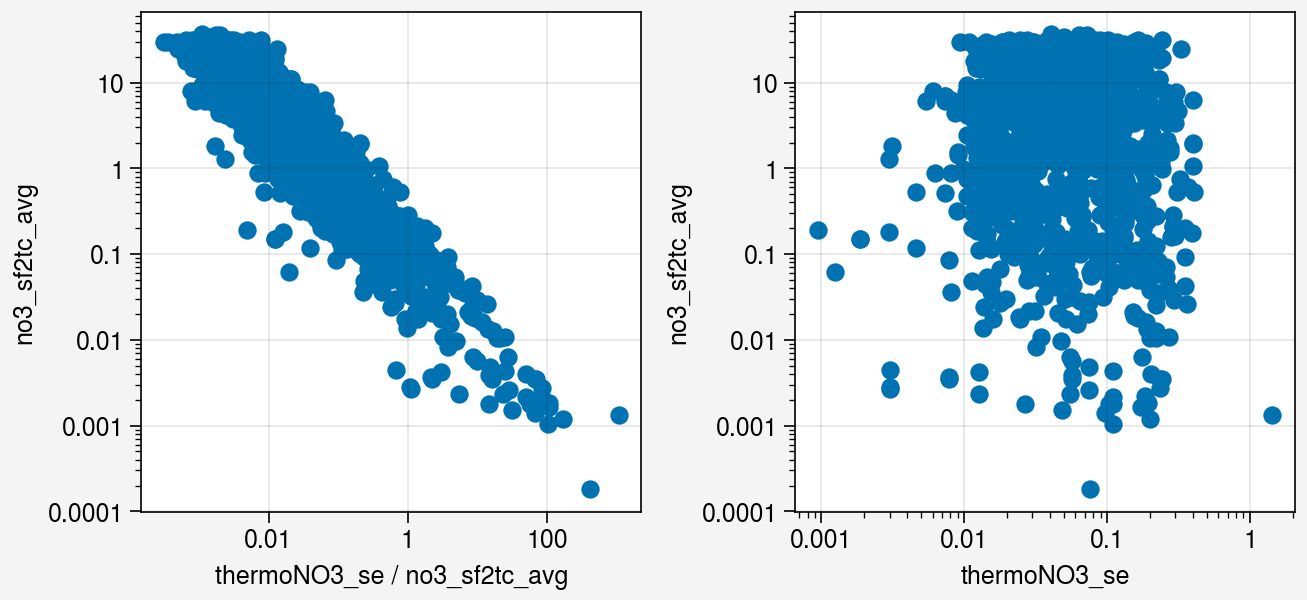

In [28]:
fig, axs = plot.subplots(ncols=2,share=0)
ax = axs[0]
ax.scatter(
    coretop_df['thermoNO3_se']/coretop_df['no3_sf2tc_avg'],
    coretop_df['no3_sf2tc_avg']
)

ax.format(
    xlabel='thermoNO3_se / no3_sf2tc_avg',
    xscale='log',
    yscale='log'
)

ax = axs[1]
ax.scatter(
    coretop_df['thermoNO3_se'],
    coretop_df['no3_sf2tc_avg']
)

ax.format(
    xscale='log',
    yscale='log'
)

# Figures for manuscript

### Temperature

WOA = World Ocean Atlas
Details:
- Temperature - Statistical mean on 1/4° grid for 1991-2020 climate normal
- Unit: Degree Celcius
- Link to download data: https://www.ncei.noaa.gov/thredds-ocean/fileServer/woa23/DATA/temperature/netcdf/decav91C0/0.25/woa23_decav91C0_t00_04.nc

In [29]:
fpath2 = fr'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature'
ts = xr.open_dataset(os.path.join(fpath2,'woa23_decav91C0_t00_04.nc'),decode_times=False).drop('time')

T_da = ts.isel(time=0).t_an.load()
T_da

<xarray.DataArray 't_an' (depth: 102, lat: 720, lon: 1440)>
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.6605101, -1.66081  , -1.65491  , ..., -1.6598101,
         -1.66031  , -1.66041  ],
        [-1.66861  , -1.66521  , -1.66721  , ..., -1.66961  ,
         -1.6665   , -1.66871  ],
        [-1.44921  , -1.44921  , -1.44921  , ..., -1.44921  ,
         -1.44921  , -1.44921  ]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
Attributes:
    standard_name:  sea_water_temperature
    long_name:      Objectively analyzed mean fields for sea_water_temperatur...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          degrees_celsius

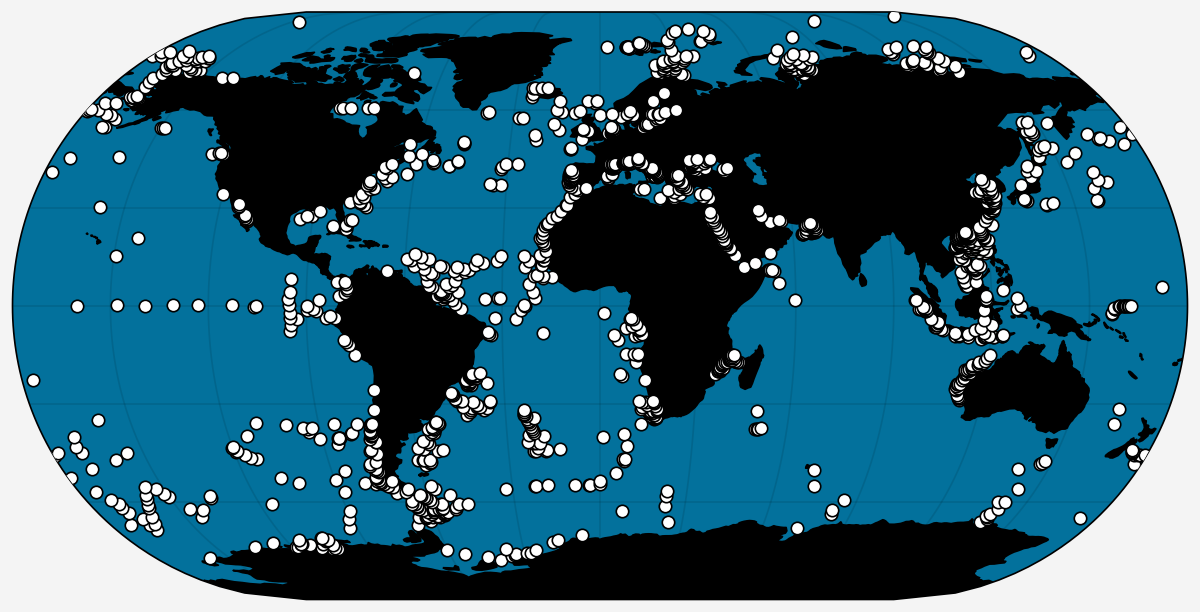

In [30]:
fig, ax = plot.subplots(width=6,proj='eck3',
                        # proj_kw={'lon_0':-150}
                        )
ax.format(
    land=True,landzorder=0,
    facecolor='ocean blue',
    # landcolor='gray7',
    coast=True,coastzorder=1,
    lonlines=30,
    latlines=30,
    # lonlabels='b',
    # latlabels='l',
    # title='Coretop locations',
)

plot_lat = coretop_df['match_lat_04deg']
plot_lon = coretop_df['match_lon_04deg']
ax.scatter(plot_lon, plot_lat, s=20, color='w', mec='k', facecolor='none', zorder=5)
fpath = f'{local_onedrive_path}/Postdoc/Workshops and Conferences/2025/AGU 2025/poster/figures'
fig.savefig(os.path.join(fpath,'coretop_locations_woa23_t00_04degC.pdf'),dpi=300,
            transparent=True)

# Posterior plots --- QC

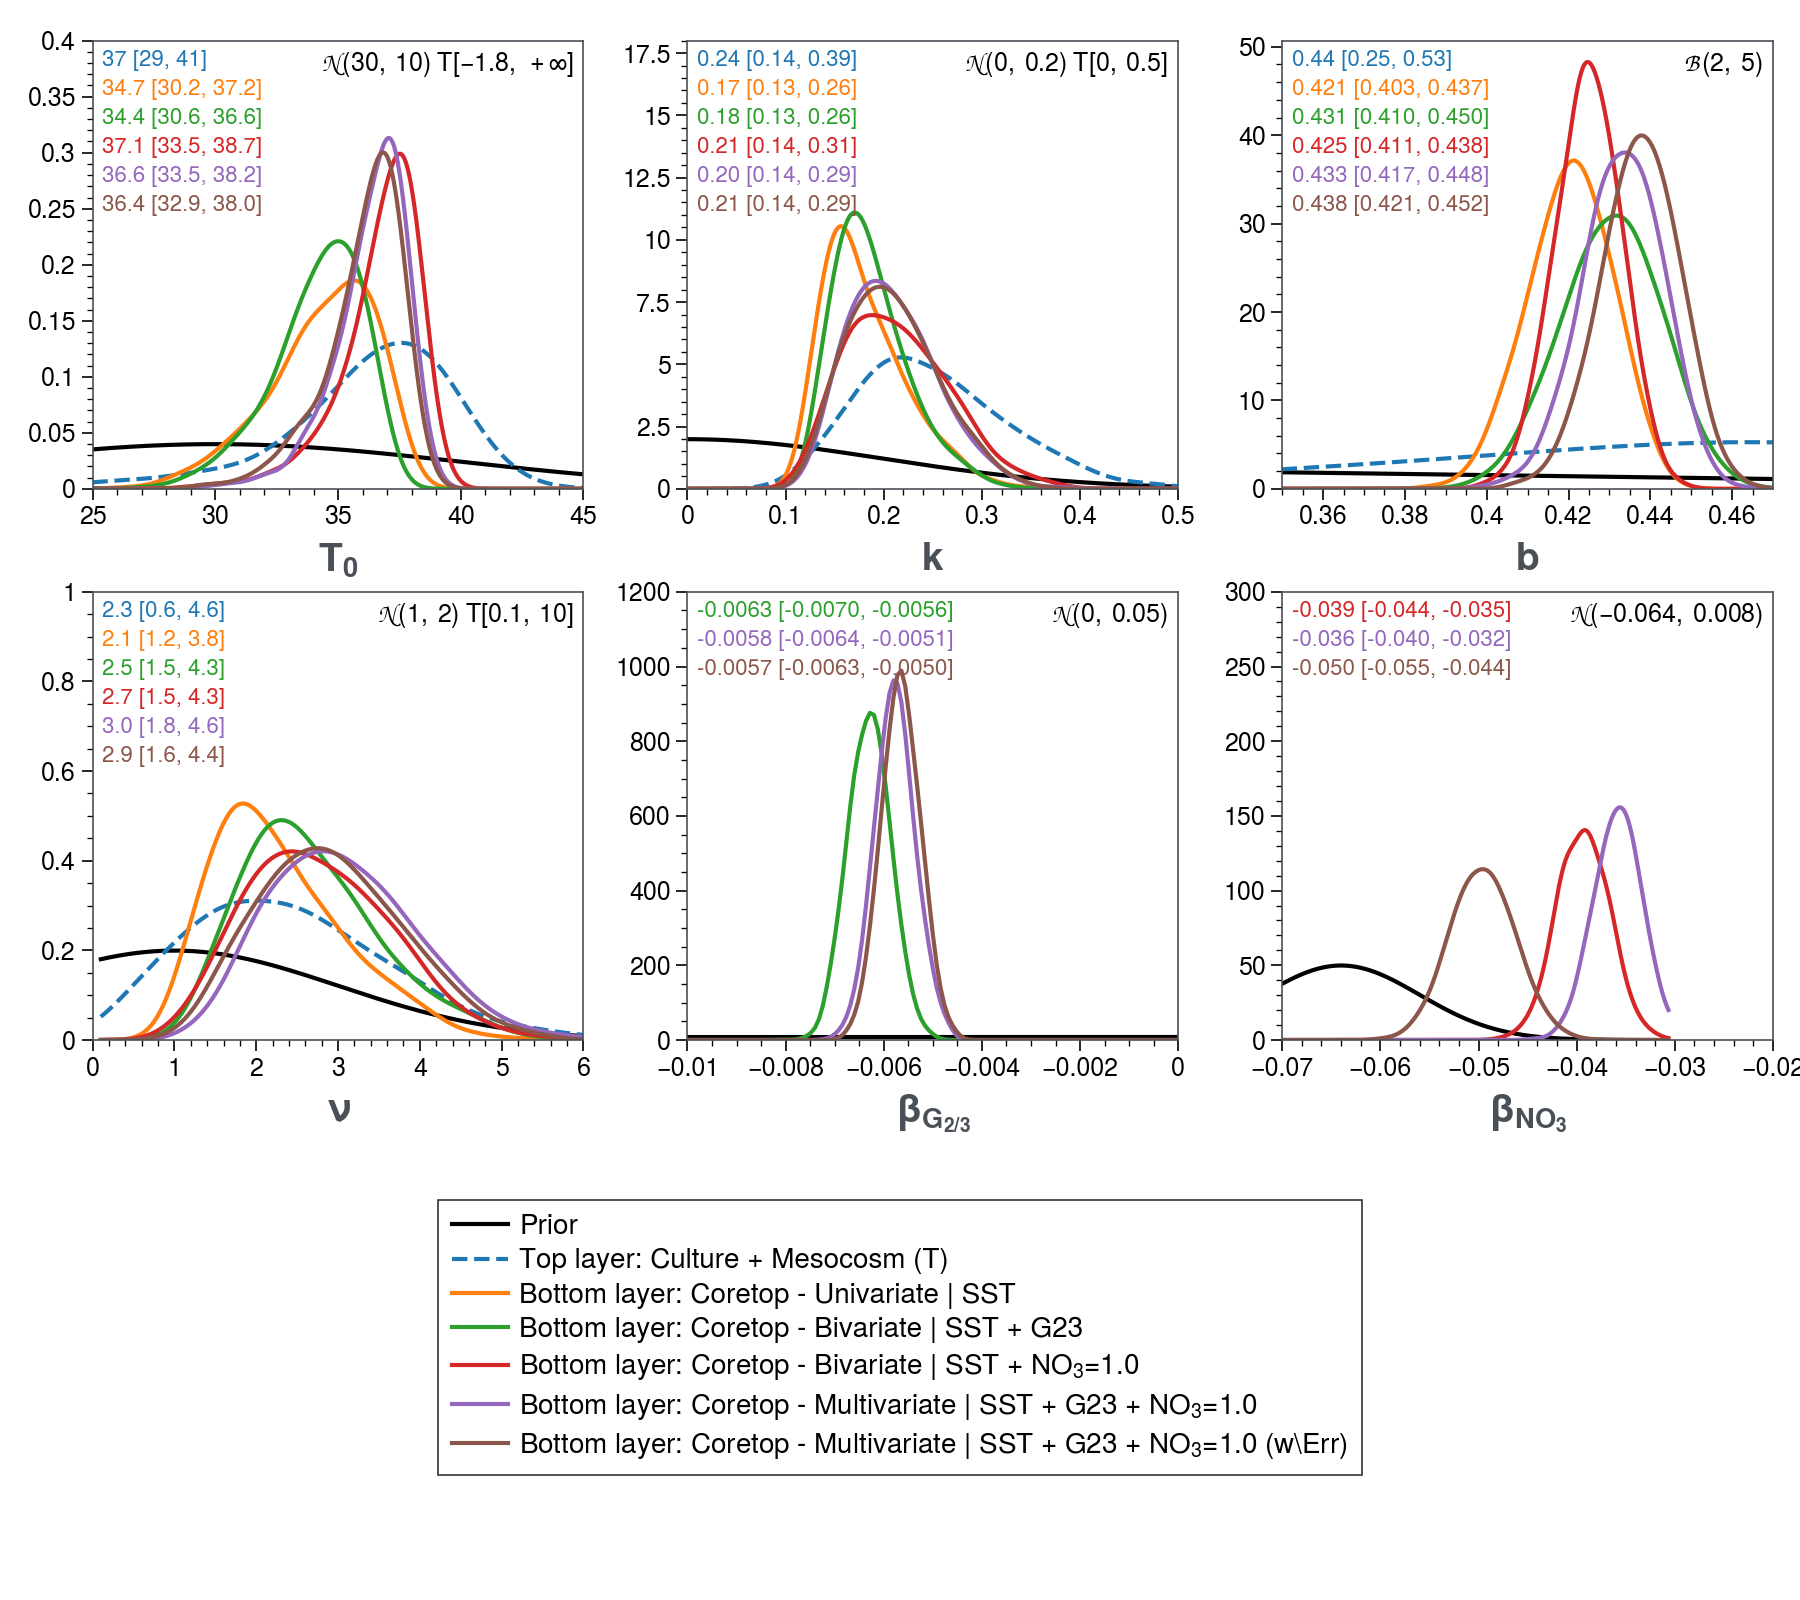

In [33]:
legend_labels = ['Top layer: Culture + Mesocosm (T)', 
                 'Bottom layer: Coretop - Univariate | SST', 
                 'Bottom layer: Coretop - Bivariate | SST + G23', 
                 r'Bottom layer: Coretop - Bivariate | SST + NO$_3$=1.0', 
                #  r'Bottom layer: Coretop - Bivariate | SST + NO$_3$=1.8',
                 r'Bottom layer: Coretop - Multivariate | SST + G23 + NO$_3$=1.0',
                 r'Bottom layer: Coretop - Multivariate | SST + G23 + NO$_3$=1.0 (w\Err)',
                 'Prior']
# ── Forward posteriors from 032326 run ────────────────────────────────────────                                                                                                                 
post_fwd_032326 = [                                      
    # Stage 1 — culmeso                                  
    "gen_logi_fixed_culmeso_cultureT_scaledRI_032326",                                           
    # Stage 2 — SST / scaledRI                           
    "gen_logi_fixed_hier_crtp_univ_priorApprox_SST_scaledRI_cren3_032326",                                                                                                                           
    "gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_gdgt23ratio_scaledRI_cren3_032326",
    "gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_no3_1.0_scaledRI_cren3_032326",
    # "gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_no3_1.8_scaledRI_cren3_032326",
    "gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_gdgt23ratio_no3_1.0_scaledRI_cren3_032326",
    "gen_logi_fixed_hier_crtp_multiv_priorApprox_werr_ver2_SST_gdgt23ratio_no3_1.0_scaledRI_cren3_041626_werr_ver2",                                                                                                          
]  

fig, axs = plot_prior_distributions(
    posterior_datasets=post_fwd_032326,
    posterior_labels_list=legend_labels,
    use_linestyle_by_param=True,
    show_histogram=False,
    set_leg_max_ncol=1,
    set_fig_height_factor=3,
    show_suptitle=False,
    show_annotation=True,
    show_subplot_legend=False,
    show_figure_legend=True,
    show_prior_expression=True,
)

axs[0,0].set_xlim(25,45)
axs[0,0].set_ylim(0,0.4)
axs[0,1].set_xlim(0,0.5)
axs[0,1].set_ylim(0,18)
axs[0,2].set_xlim(0.35,0.47)
axs[1,0].set_xlim(0,6)
axs[1,0].set_ylim(0,1)
axs[1,1].set_xlim(-0.01,0)
axs[1,1].set_ylim(0,1200)
axs[1,2].set_xlim(-0.07,-0.02)
axs[1,2].set_ylim(0,300)

for ax in axs.flatten():
    
    ax.set_xlabel(ax.get_xlabel(), fontsize=14, color='gray7', fontweight='bold')
    ax.set_ylabel(ax.get_ylabel(), fontsize=14, color='gray7', fontweight='bold')
    
    # ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, color='gray7')
    # ax.set_yticklabels(ax.get_yticklabels(), fontsize=12, color='gray7')
    
    ax.spines[:].set_color('gray7')
    
    
    ax.grid(False)
    ax.set_ylim(bottom=0)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)
fig.set_facecolor("white")  # or whatever you want
fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fig.savefig(os.path.join(fpath,'AppendixB_SST_prior_distributions.pdf'),dpi=300)

In [39]:
test_ds_full_EIV = load_posterior("gen_logi_fixed_hier_crtp_multiv_priorApprox_werr_ver2_SST_gdgt23ratio_no3_1.0_scaledRI_cren3_041626_werr_ver2")
test_ds_full_ODR = load_posterior("gen_logi_fixed_hier_crtp_multiv_odr_SST_gdgt23ratio_no3_1.0_scaledRI_cren3_041526_odr")
test_ds_full = load_posterior("gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_gdgt23ratio_no3_1.0_scaledRI_cren3_032326")
test_ds_full_RI04 = load_posterior("gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_gdgt23ratio_no3_1.0_scaledRI_032326")
test_ds_TG23 = load_posterior("gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_gdgt23ratio_scaledRI_cren3_032326")
test_ds_TNO3 = load_posterior("gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_no3_1.0_scaledRI_cren3_032326")
test_ds_univ_crtp = load_posterior("gen_logi_fixed_hier_crtp_univ_priorApprox_SST_scaledRI_cren3_032326")
test_ds_univ_crtp_RI04 = load_posterior("gen_logi_fixed_hier_crtp_univ_priorApprox_SST_scaledRI_032326")

In [40]:
test_ds_full.attrs

{'stan_version': '2.36.0',
 'model': 'gen_logi_fixed_hier_crtp_multiv_priorApprox_model',
 'num_draws_sampling': 1000,
 'stan_model_name': 'gen_logi_fixed_hier_crtp_multiv_priorApprox',
 'generated_by': 'culRI-Bayesian',
 'version': '1.0.0',
 'run_time': '2026-04-09T17:49:40.010645',
 'run_duration (sec)': 32.9,
 'temptype': 'SST',
 'N_crtp': 1513,
 'proxyObs_crtp_mean': 0.577556472994008,
 'proxyObs_crtp_std': 0.11435506724426533,
 'proxyObs_crtp_min': 0.3283082077051926,
 'proxyObs_crtp_max': 0.8695202853618693,
 'proxyObs_crtp_len': 1513,
 'gdgt23ratio_crtp_mean': 5.317488104164646,
 'gdgt23ratio_crtp_std': 3.414193571055558,
 'gdgt23ratio_crtp_min': 0.7556675062972293,
 'gdgt23ratio_crtp_max': 35.08333333333333,
 'gdgt23ratio_crtp_len': 1513,
 'use_gdgt23ratio': 1,
 'no3_crtp_mean': 6.029195604811651,
 'no3_crtp_std': 8.162666637230137,
 'no3_crtp_min': 0.0001824342325562,
 'no3_crtp_max': 36.42815399169922,
 'no3_crtp_len': 1513,
 'use_no3': 1,
 'no3_cutoff': 1.0,
 'proxy_name': '

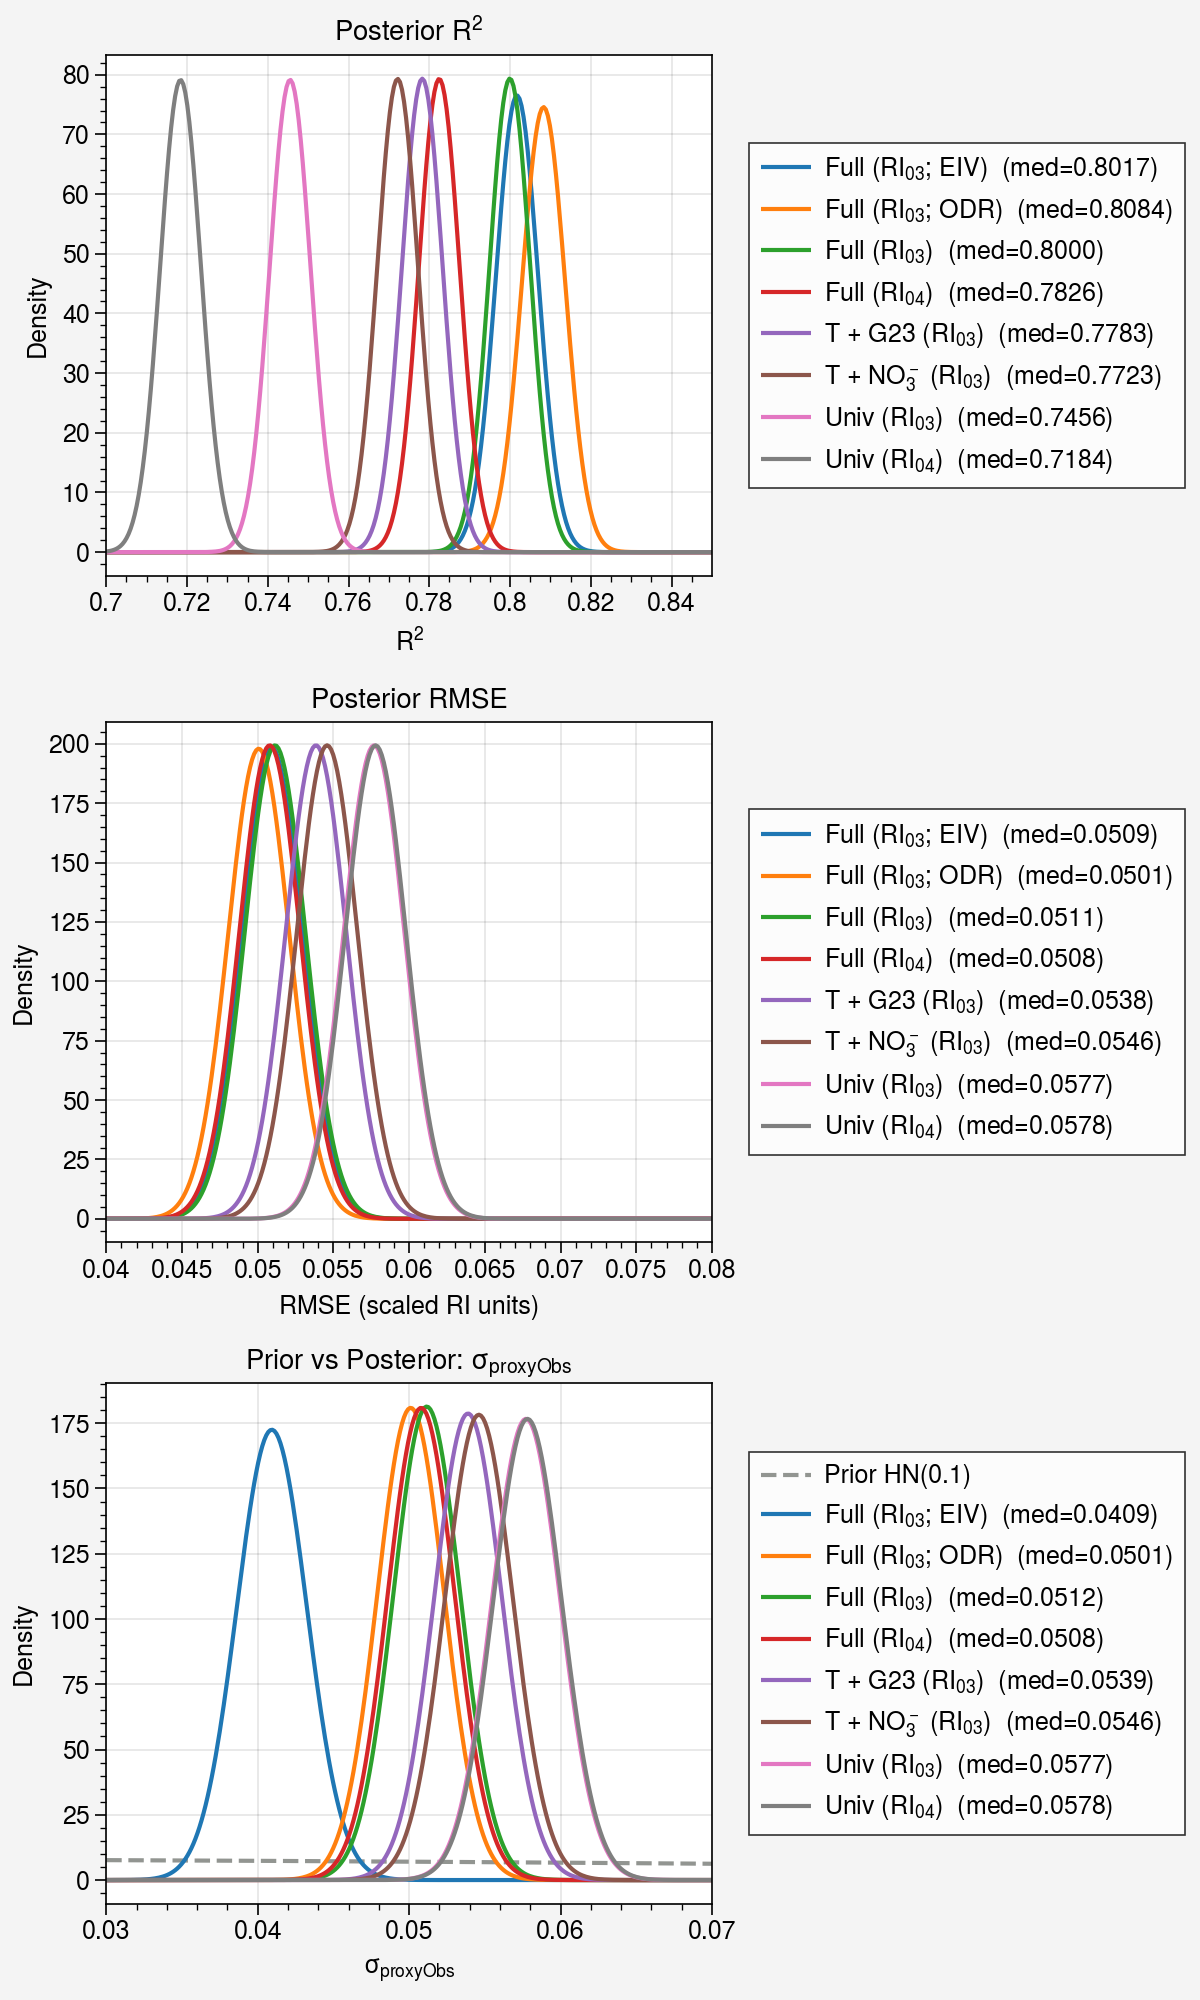

In [42]:
post_ds_list = [
    (test_ds_full_EIV,           r'Full (RI$_{03}$; EIV)'),
    (test_ds_full_ODR,           r'Full (RI$_{03}$; ODR)'),
    (test_ds_full,           r'Full (RI$_{03}$)'),
    (test_ds_full_RI04,      r'Full (RI$_{04}$)'),
    (test_ds_TG23,           r'T + G23 (RI$_{03}$)'),
    (test_ds_TNO3,           r'T + NO$_3^-$ (RI$_{03}$)'),
    (test_ds_univ_crtp,      r'Univ (RI$_{03}$)'),
    (test_ds_univ_crtp_RI04, r'Univ (RI$_{04}$)'),
]

colors = plot.get_colors('tab10', N=len(post_ds_list))

fig, axs = plot.subplots(nrows=3, figsize=(6, 10),share=0)

# ── panel config ──────────────────────────────────────────────────────────────
panels = [
    dict(
        var      = 'R2_full',
        xlim     = (0.70, 0.85),
        bw       = 0.005,
        xlabel   = r'$R^2$',
        title    = r'Posterior $R^2$',
        prior    = None,                          # no obvious prior for R²
    ),
    dict(
        var      = 'RMSE_full',
        xlim     = (0.04, 0.08),
        bw       = 0.002,
        xlabel   = r'RMSE (scaled RI units)',
        title    = r'Posterior RMSE',
        prior    = None,
    ),
    dict(
        var      = 'sigma_proxyObs_crtp',
        xlim     = (0.03, 0.07),
        bw       = 0.002,
        xlabel   = r'$\sigma_{\mathrm{proxyObs}}$',
        title    = r'Prior vs Posterior: $\sigma_{\mathrm{proxyObs}}$',
        prior    = dict(sigma=0.1, label='Prior HN(0.1)'),
    ),
]

for ax, cfg in zip(axs, panels):
    x_eval = np.linspace(cfg['xlim'][0], cfg['xlim'][1], 300)

    # Prior (only for sigma panel)
    if cfg['prior'] is not None:
        prior_pdf = stats.halfnorm.pdf(x_eval, loc=0, scale=cfg['prior']['sigma'])
        ax.plot(x_eval, prior_pdf, color='gray', linestyle='--',
                lw=1.5, label=cfg['prior']['label'])

    for (idata, label), color in zip(post_ds_list, colors):
        x = idata[cfg['var']].values.flatten()
        bw_abs = cfg['bw']
        kde = stats.gaussian_kde(x, bw_method=bw_abs / x.std(ddof=1))
        med = np.median(x)
        ax.plot(x_eval, kde(x_eval), color=color,
                label=rf'{label}  (med={med:.4f})')

    ax.format(
        xlim   = cfg['xlim'],
        xlabel = cfg['xlabel'],
        ylabel = 'Density',
        title  = cfg['title'],
    )
    ax.legend(loc='r', ncol=1)

In [43]:
def variance_partitioning(ds_T, ds_TG23, ds_TNO3, ds_full, proxyObs,
                        var="sigma_proxyObs_crtp"):                                                                                                                        
    """
    Two-predictor (G23, NO3) variance partitioning of proxy observations.                                                                                                    
                                            
    Columns                          
    -------     
    σ²          : posterior mean of σ²                                                                                                                                       
    % σ²_T      : fraction of non-thermal residual variance
    % total     : fraction of total proxy variance (Var(proxyObs))                                                                                                           
    """                                     
    def sigma2(ds):                  
        return float(np.mean(ds[var].values.ravel() ** 2))
                                    
    s2 = {                                  
        "T":         sigma2(ds_T),   
        "T+G23":     sigma2(ds_TG23),
        "T+NO3":     sigma2(ds_TNO3),                                                                                                                                        
        "T+G23+NO3": sigma2(ds_full),
    }                                
                                        
    obs       = proxyObs.values if hasattr(proxyObs, "values") else np.asarray(proxyObs)
    var_total = float(np.var(obs))   
                                            
    thermal = var_total - s2["T"]            # variance explained by T                                                                                                       
    a       = s2["T+NO3"]  - s2["T+G23+NO3"]                         # G23 unique
    b       = s2["T"] - s2["T+G23"] - s2["T+NO3"] + s2["T+G23+NO3"] # shared                                                                                                 
    c       = s2["T+G23"]  - s2["T+G23+NO3"]                         # NO3 unique                                                                                            
    d       = s2["T+G23+NO3"]                                         # residual                                                                                             
                                    
    base = s2["T"]                   
                                    
    rows = [                         
        ("Total proxy variance",    var_total, None,        var_total / var_total * 100),                                                                                    
        (None,),                            
        ("Thermal (T)",             thermal,   thermal / base * 100, thermal / var_total * 100),
        ("G23 unique  [a]",         a,         a / base * 100,       a / var_total * 100),
        ("Shared G23∩NO3  [b]",     b,         b / base * 100,       b / var_total * 100),                                                                                   
        ("NO3 unique  [c]",         c,         c / base * 100,       c / var_total * 100),                                                                                   
        ("Residual  [d]",           d,         d / base * 100,       d / var_total * 100),                                                                                   
        (None,),                     
        ("Sum",                     var_total, None,        100.0),                                                                                                          
    ]                                       
                                    
    hdr = f"{'Component':>20}  {'σ²':>8}  {'% σ²_T':>8}  {'% total':>8}"
    print(f"\n{hdr}")                
    print("─" * len(hdr))
    for row in rows:                 
        if row[0] is None:
            print()                  
            continue
        label, val, pct_T, pct_tot = row
        p_T   = f"{pct_T:7.1f}%" if pct_T  is not None else " " * 8
        p_tot = f"{pct_tot:7.1f}%"          
        print(f"{label:>20}  {val:8.5f}  {p_T}  {p_tot}")
        
    return base, var_total, thermal, a, b, c, d
                                
# Usage                              
base, var_total, thermal, a, b, c, d = variance_partitioning(               
test_ds_univ_crtp, test_ds_TG23, test_ds_TNO3, test_ds_full,                                                                                                             
proxyObs=coretop_df["scaledRI_cren3"],                                                                                                                                      
)        


           Component        σ²    % σ²_T   % total
──────────────────────────────────────────────────
Total proxy variance   0.01308              100.0%

         Thermal (T)   0.00974    292.1%     74.5%
     G23 unique  [a]   0.00036     10.9%      2.8%
 Shared G23∩NO3  [b]   0.00006      1.9%      0.5%
     NO3 unique  [c]   0.00029      8.6%      2.2%
       Residual  [d]   0.00262     78.5%     20.0%

                 Sum   0.01308              100.0%


In [44]:
# from matplotlib_venn import venn2, venn2_circles                                                                                                                             
# import matplotlib.pyplot as plt      
                                    
# fig, ax = plt.subplots(figsize=(5, 4))                                                                                                                                       
                                    
# # % of σ²_T (non-thermal residual)   
# a_pct = a / base * 100   # G23 unique                                                                                                                                        
# b_pct = b / base * 100   # shared    
# c_pct = c / base * 100   # NO3 unique                                                                                                                                        
# d_pct = d / base * 100   # residual  
                                    
# # venn2 subsets = (G23-only, NO3-only, shared)                                                                                                                               
# v = venn2(subsets=(a_pct, c_pct, b_pct), set_labels=("", ""), ax=ax)                                                                                                         
                                    
# # Colours
# v.get_patch_by_id("10").set(facecolor="#4C72B0", alpha=0.7)  # G23                                                                                                           
# v.get_patch_by_id("01").set(facecolor="#DD8452", alpha=0.7)  # NO3                                                                                                           
# v.get_patch_by_id("11").set(facecolor="#8C8C8C", alpha=0.7)  # shared                                                                                                        
                                    
# # Region labels                      
# v.get_label_by_id("10").set_text(f"G23\n{a_pct:.1f}%")                                                                                                                       
# v.get_label_by_id("01").set_text(f"NO₃\n{c_pct:.1f}%")
# v.get_label_by_id("11").set_text(f"{b_pct:.1f}%")                                                                                                                            

# # Residual outside the circles       
# ax.text(0.5, 0.04, f"Residual [d] = {d_pct:.1f}%",
#         ha="center", transform=ax.transAxes, fontsize=9, color="gray")                                                                                                       
                
# ax.set_title(                        
#     "Non-thermal proxy variance partitioning\n"
#     f"(% of σ²_T;  thermal = {thermal/var_total*100:.1f}% of total proxy variance)",                                                                                         
#     fontsize=10,                     
# )                                    
                                    
# plt.tight_layout()
# plt.savefig("variance_partition_venn.png", dpi=150, bbox_inches="tight")
# plt.show()    

In [45]:
for label, ds, var in [              
    ("G23", test_ds_full, "beta_G23_crtp"),                                                                                                                                  
    ("NO3", test_ds_full, "beta_NO3_crtp"),                                                                                                                                  
]:
    draws = ds[var].values.ravel()   
    print(f"β_{label}: {np.mean(draws):.4f} ± {np.std(draws):.4f}  "
        f"68% CI [{np.percentile(draws, 16):.4f}, {np.percentile(draws, 84):.4f}]")    

β_G23: -0.0058 ± 0.0004  68% CI [-0.0062, -0.0054]
β_NO3: -0.0358 ± 0.0025  68% CI [-0.0383, -0.0334]


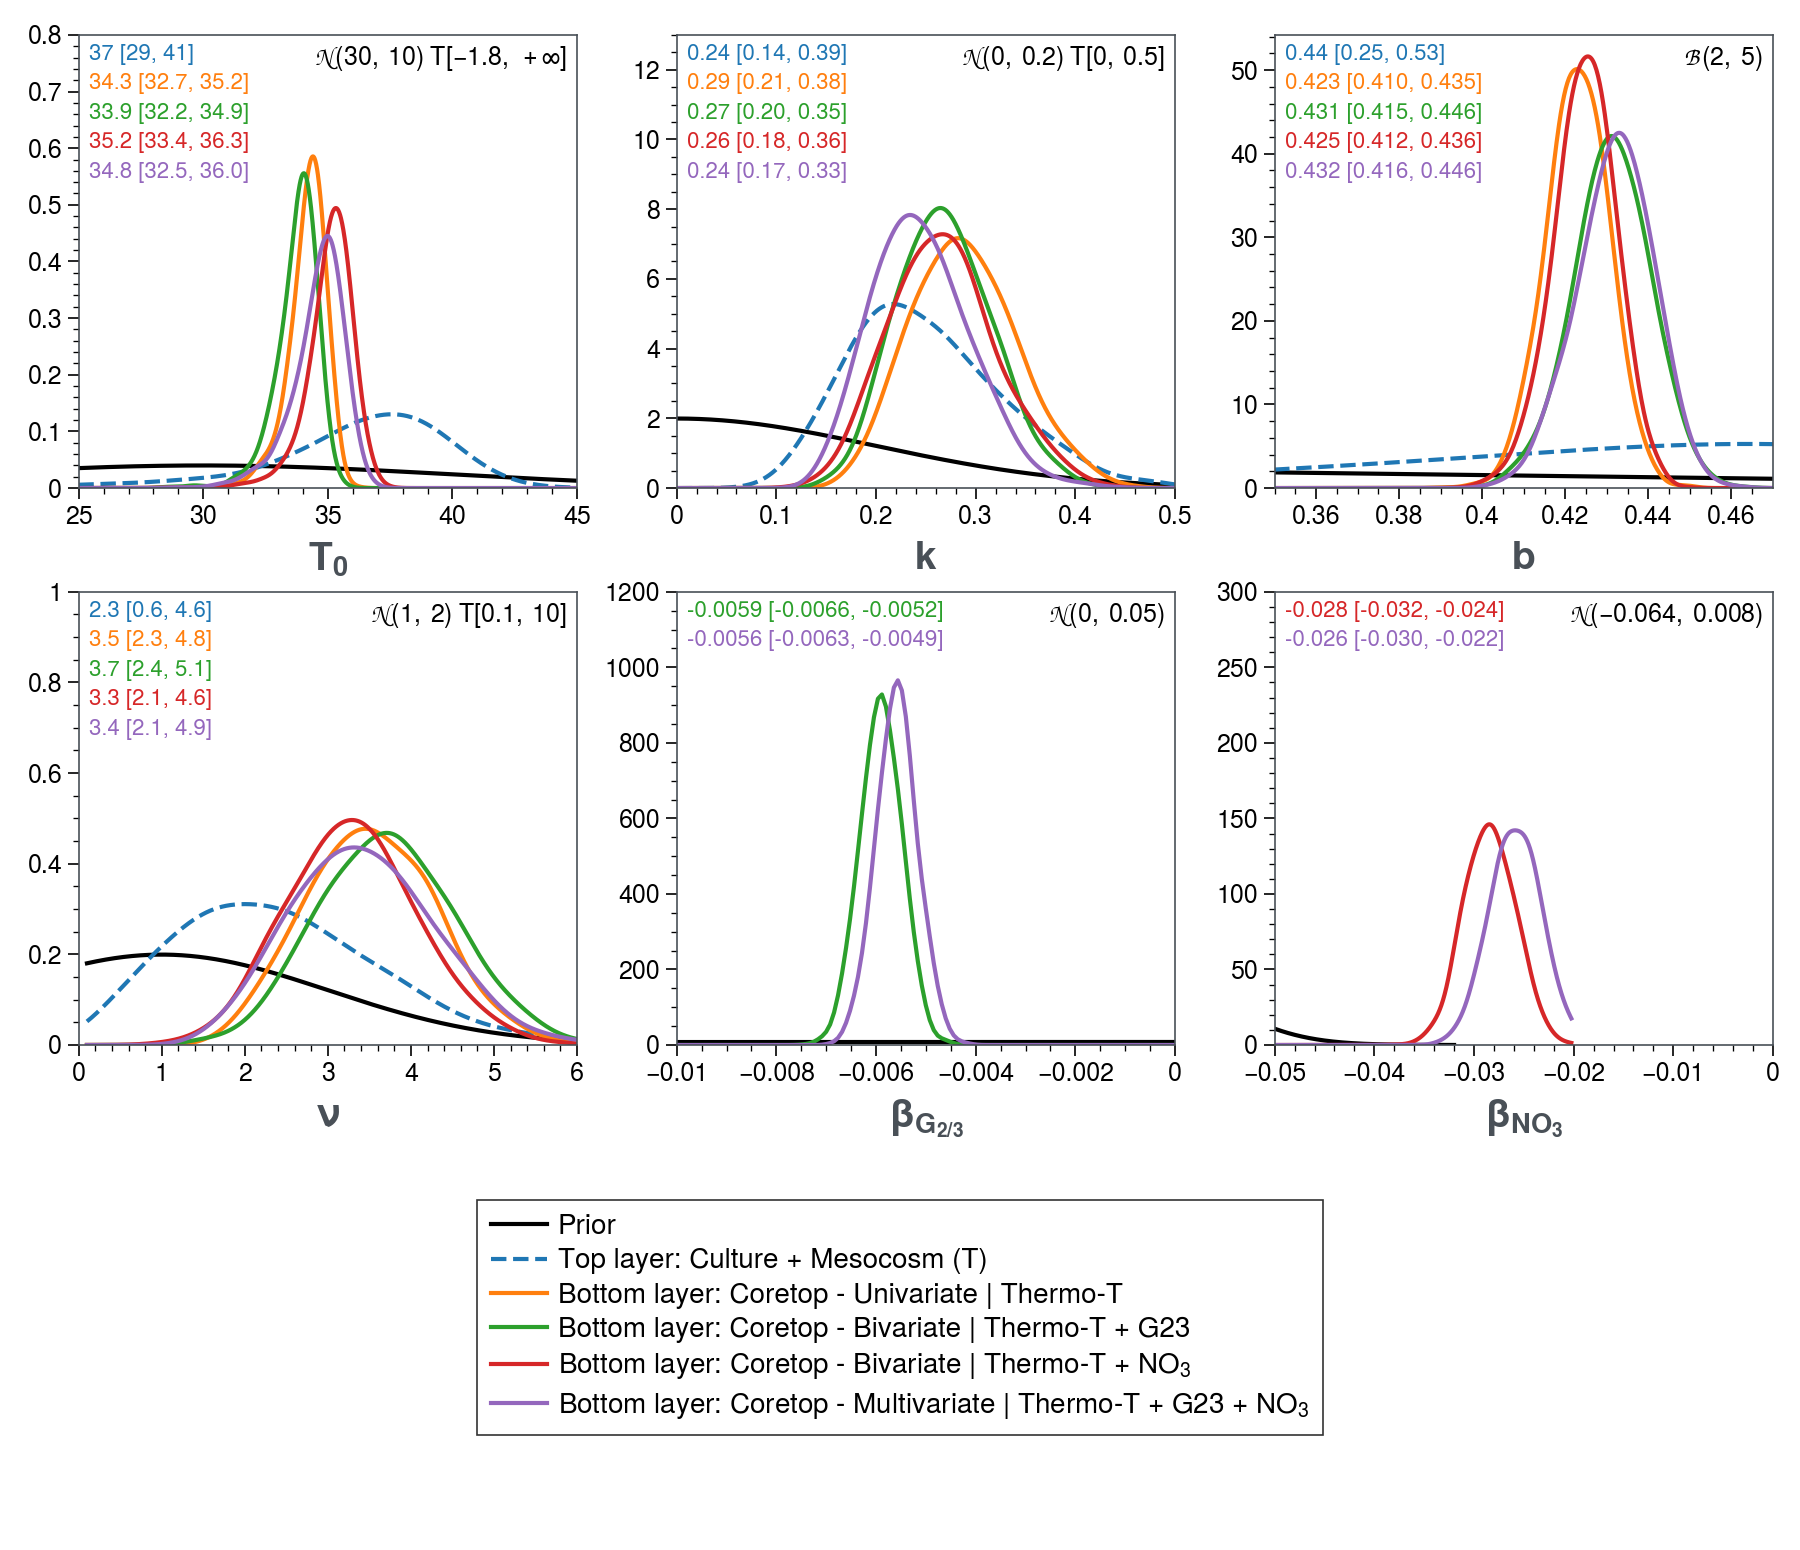

In [46]:
legend_labels = ['Top layer: Culture + Mesocosm (T)', 
                 'Bottom layer: Coretop - Univariate | Thermo-T', 
                 'Bottom layer: Coretop - Bivariate | Thermo-T + G23', 
                 r'Bottom layer: Coretop - Bivariate | Thermo-T + NO$_3$',
                 r'Bottom layer: Coretop - Multivariate | Thermo-T + G23 + NO$_3$',
                 'Prior']
# ── Forward posteriors from 032326 run ────────────────────────────────────────                                                                                                                 
post_fwd_032326 = [                                      
    # Stage 1 — culmeso                                  
    "gen_logi_fixed_culmeso_cultureT_scaledRI_032326",                                           
    # Stage 2 — SST / scaledRI                           
    "gen_logi_fixed_hier_crtp_univ_priorApprox_thermoT_scaledRI_cren3_032326",                                                                                                                           
    "gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_scaledRI_cren3_032326",                                                                                                                 
    "gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_no3_1.9_scaledRI_cren3_032326",                                                                                                                     
    "gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_no3_1.9_scaledRI_cren3_032326",                                                                                                          
]  

fig, axs = plot_prior_distributions(
    posterior_datasets=post_fwd_032326,
    posterior_labels_list=legend_labels,
    use_linestyle_by_param=True,
    show_histogram=False,
    set_leg_max_ncol=1,
    set_fig_height_factor=3,
    show_suptitle=False,
    show_annotation=True,
    show_subplot_legend=False,
    show_figure_legend=True,
    show_prior_expression=True,
)

axs[0,0].set_xlim(25,45)
axs[0,0].set_ylim(0,0.8)
axs[0,1].set_xlim(0,0.5)
axs[0,1].set_ylim(0,13)
axs[0,2].set_xlim(0.35,0.47)
axs[1,0].set_xlim(0,6)
axs[1,0].set_ylim(0,1)
axs[1,1].set_xlim(-0.01,0)
axs[1,1].set_ylim(0,1200)
axs[1,2].set_xlim(-0.05,0)
axs[1,2].set_ylim(0,300)

for ax in axs.flatten():
    
    ax.set_xlabel(ax.get_xlabel(), fontsize=14, color='gray7', fontweight='bold')
    ax.set_ylabel(ax.get_ylabel(), fontsize=14, color='gray7', fontweight='bold')
    
    # ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, color='gray7')
    # ax.set_yticklabels(ax.get_yticklabels(), fontsize=12, color='gray7')
    
    ax.spines[:].set_color('gray7')
    
    
    ax.grid(False)
    ax.set_ylim(bottom=0)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)
fig.set_facecolor("white")  # or whatever you want
fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fig.savefig(os.path.join(fpath,'AppendixC_thermoT_prior_distributions.pdf'),dpi=300)

In [47]:
plot_culmeso_df = gridded_combined_df[gridded_combined_df['datatype'].isin(['culture','mesocosm'])].dropna(subset=['scaledRI','SST']).reset_index(drop=True)

y_params = ['scaledRI','scaledRI_cren3']
for y_param in y_params:
    pred_scaledRI_culmeso_results = generate_ensemble_auto(
        post_ds = load_posterior(f"gen_logi_fixed_culmeso_cultureT_{y_param}_032326"),
        x_vals = plot_culmeso_df['SST'].values,
        percentiles=[2.5,50,97.5],
    )
    plot_culmeso_df[f'pred_{y_param}'] = pred_scaledRI_culmeso_results['p50']

In [55]:
y_params = ['scaledRI','scaledRI_cren3']
plot_coretop_df = coretop_df
for y_param in y_params:
    pred_scaledRI_crtp_results = generate_ensemble_auto(
        post_ds = load_posterior(f"gen_logi_fixed_hier_crtp_multiv_priorApprox_werr_ver2_SST_gdgt23ratio_no3_1.0_{y_param}_041626_werr_ver2"),
        x_vals = plot_coretop_df['SST'].values,
        gdgt23ratio = plot_coretop_df['gdgt23ratio'].values,
        no3 = plot_coretop_df['no3_sf2tc_avg'].values,
        no3_cutoff = 1.8,
        percentiles=[2.5,50,97.5],
    )
    plot_coretop_df[f'pred_{y_param}'] = pred_scaledRI_crtp_results['p50']
    plot_coretop_df[f'residual_{y_param}'] = plot_coretop_df['scaledRI'] - plot_coretop_df[f'pred_{y_param}']


0.72
t0_culmeso: mean=35.8830, sd=3.3267
35.9 ± 3.3
k_culmeso: mean=0.2399, sd=0.0766
0.24 ± 0.08
v_culmeso: mean=2.7249, sd=1.2940
2.7 ± 1.3
b_culmeso: mean=0.4158, sd=0.0946
0.42 ± 0.09


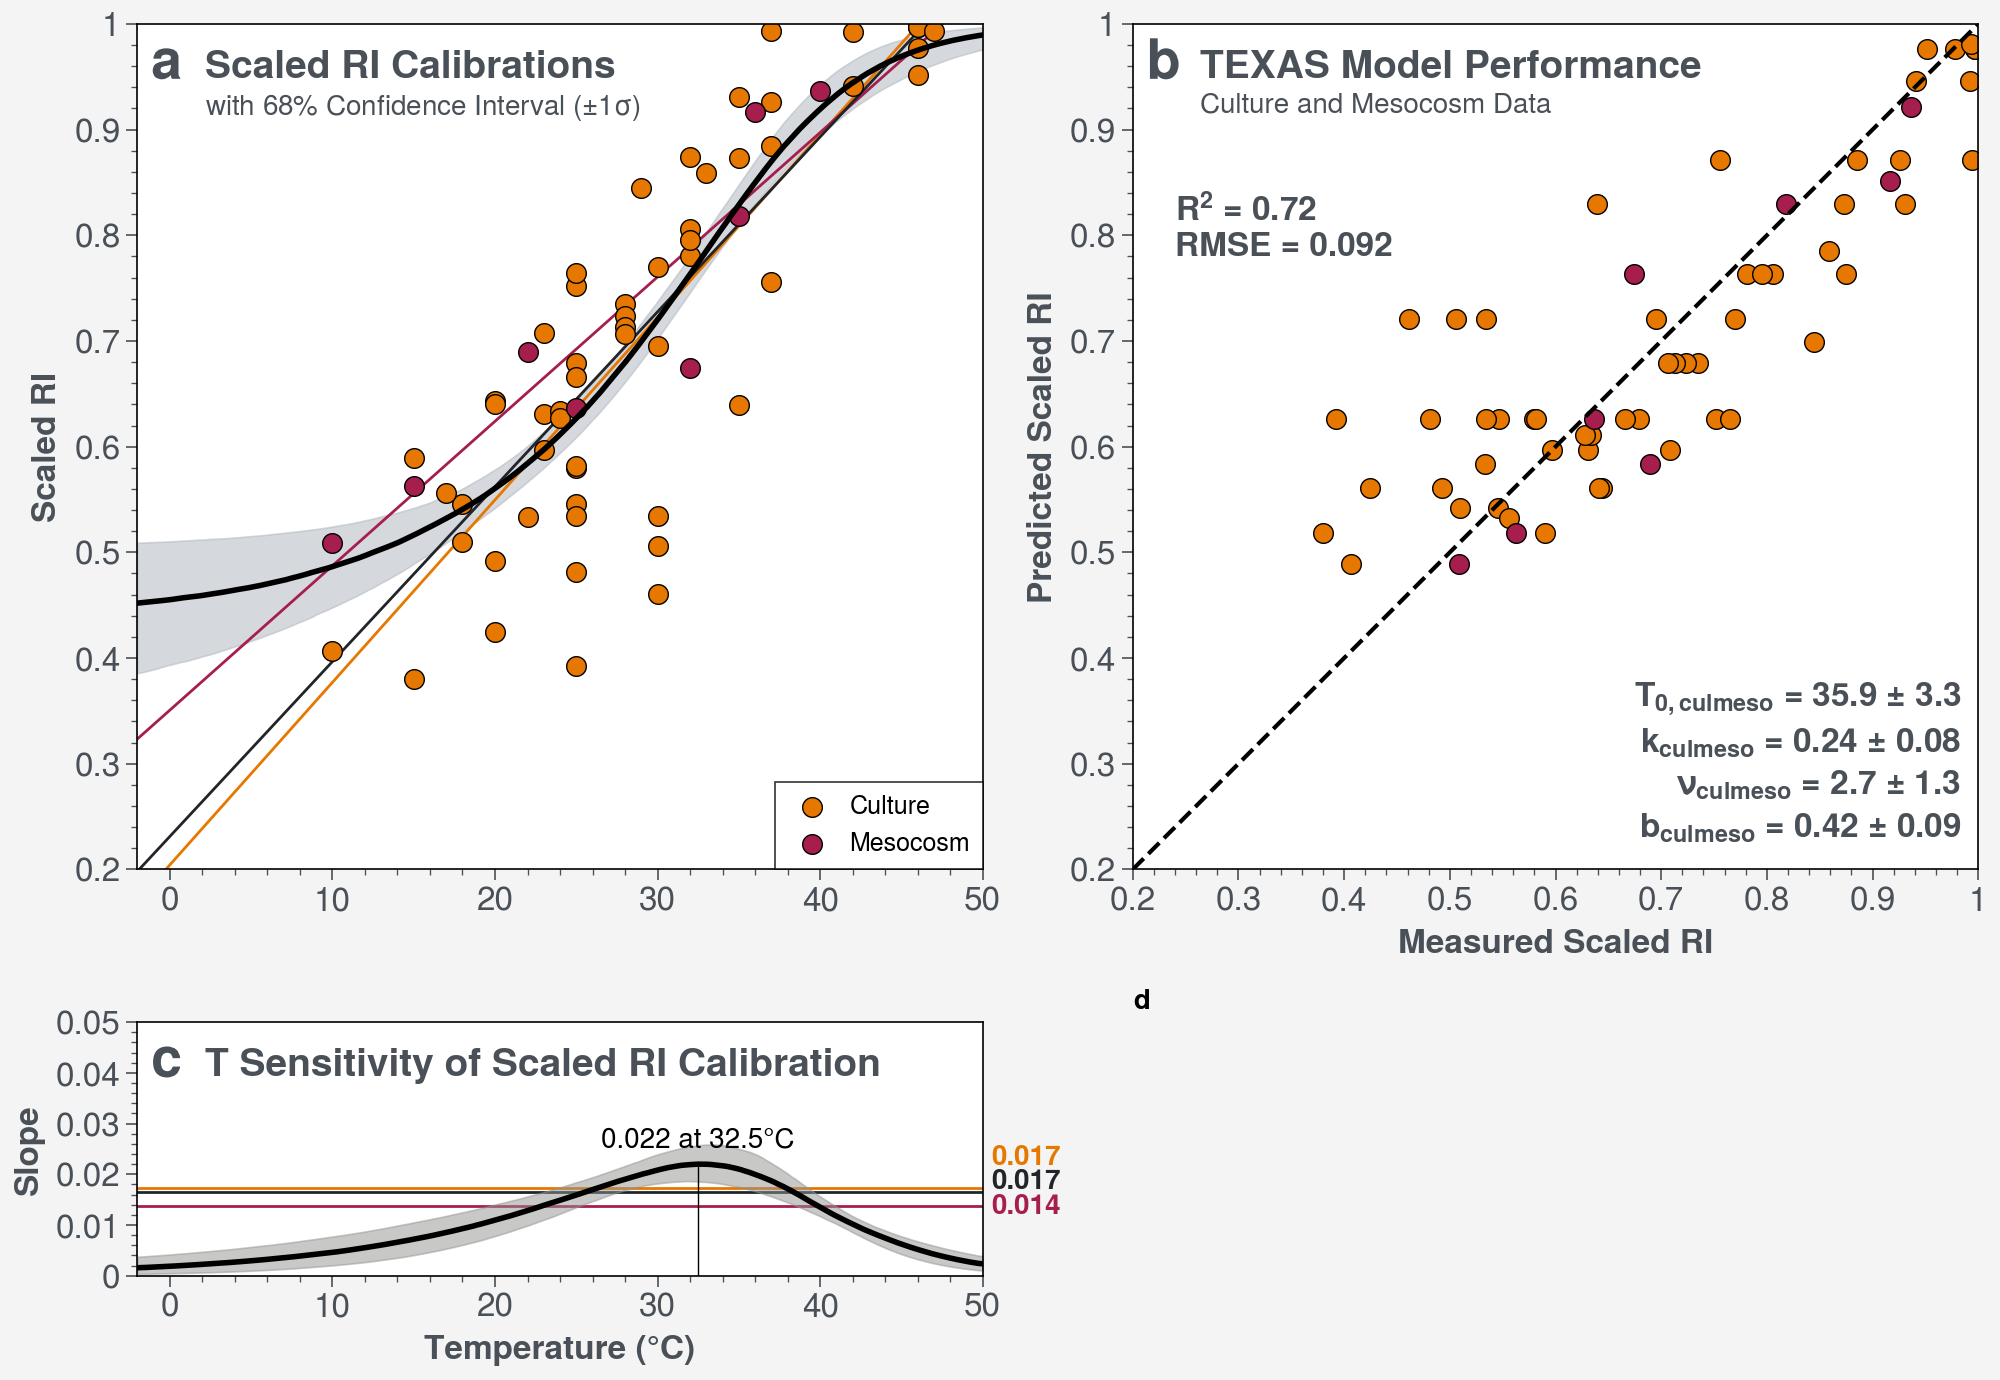

In [56]:
fig, axs = plot.subplots(width=10,ncols=2,nrows=2,
                         share=0,wspace=6,
                         hratios=[1,0.3])
plot_data = plot_culmeso_df
XX = np.linspace(-2,50,200)
x_param = 'SST'
y_param = 'scaledRI_cren3'
grouped = plot_data.groupby('datatype')
for name, group in grouped:
    plot_x = group[x_param]
    plot_y = group[y_param]
    axs[0,0].scatter(plot_x, plot_y, s=50,
               c=datatype_color_dict.get(name),
               m='o',mec='k',mew=0.5)
    
    plot_x = group[y_param]
    plot_y = group[f'pred_{y_param}']
    axs[0,1].scatter(plot_x, plot_y, s=50,
               c=datatype_color_dict.get(name),
               m='o',mec='k',mew=0.5)
    
    ### linear regression line for each datatype with 95% CI shading
    from sklearn.linear_model import LinearRegression
    from sklearn.utils import resample
    
    model = LinearRegression()
    X = group[x_param].values.reshape(-1, 1)
    y = group[y_param].values
    model.fit(X, y)
    x_range = XX.reshape(-1, 1)
    y_pred = model.predict(x_range)
    axs[0,0].plot(x_range, y_pred, color=datatype_color_dict.get(name), lw=1, zorder=0)
    
    slope = model.coef_[0]
    axs[1,0].axhline(slope, color=datatype_color_dict.get(name), lw=1, zorder=0)
    
    text = f"{slope:.3f}"
    
    y_adjust = 0.006 if name=='culture' else 0
    axs[1,0].text(1.01, slope + y_adjust, 
                  text,
                  transform=axs[1,0].get_yaxis_transform(),
                  ha = 'left', verticalalignment='center',
                  fontsize=10,fontweight='bold',
                  color=datatype_color_dict.get(name))
    
    
model = LinearRegression()
X = plot_data[x_param].values.reshape(-1, 1)
y = plot_data[y_param].values
model.fit(X, y)
x_range = XX.reshape(-1, 1)
y_pred = model.predict(x_range)
axs[0,0].plot(x_range, y_pred, color='gray9', lw=1, zorder=0)

slope = model.coef_[0]
text = f"{slope:.3f}"
axs[1,0].axhline(slope, color='gray9', lw=1, zorder=0)
axs[1,0].text(1.01, slope + 0.002, text,
            transform=axs[1,0].get_yaxis_transform(),
            ha = 'left', verticalalignment='center',
            fontsize=10,fontweight='bold',
            color='gray9')

# Get all samples
gen_logi_fixed_cul_meso_post_ds = load_posterior(f"gen_logi_fixed_culmeso_cultureT_{y_param}_032326")
t0_samples = gen_logi_fixed_cul_meso_post_ds["t0_culmeso"].values.flatten()
b_samples = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].values.flatten()
k_samples = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].values.flatten()
v_samples = gen_logi_fixed_cul_meso_post_ds["v_culmeso"].values.flatten()

# Calculate curves for ALL posterior samples
all_curves = []
all_slopes = []
for i in range(len(t0_samples)):
    curve = generalized_logistic_model_fixed_upper(
        XX,
        x0=t0_samples[i],
        b=b_samples[i],
        k=k_samples[i],
        v=v_samples[i],
    )
    all_curves.append(curve)
    
    # Calculate numerical derivative (slope)
    slope = np.gradient(curve, XX)
    all_slopes.append(slope)
    
all_curves = np.array(all_curves)  # Shape: (n_samples, len(XX))
all_slopes = np.array(all_slopes)  # Shape: (n_lines, len(XX))
# Plot credible intervals
median_curve = np.median(all_curves, axis=0)
ci_low = np.percentile(all_curves, 16, axis=0)
ci_high = np.percentile(all_curves, 84, axis=0)

# Plot
axs[0,0].fill_between(XX, ci_low, ci_high, alpha=0.5, color='gray5',zorder=0)
axs[0,0].plot(XX, median_curve, 'k-', lw=2, label='Median', zorder=1)


# Calculate median and CI
median_slope = np.median(all_slopes, axis=0)
ci_low = np.percentile(all_slopes, 16, axis=0)
ci_high = np.percentile(all_slopes, 84, axis=0)

max_slope_idx = np.argmax(median_slope)
max_slope_value = median_slope[max_slope_idx]
max_slope_temp = XX[max_slope_idx]

# Plot slope vs temperature
ax = axs[1,0]
ax.fill_between(XX, ci_low, ci_high, alpha=0.5, color='gray')
ax.plot(XX, median_slope, c='k', lw=2, label='Median slope')

ax.plot([max_slope_temp,max_slope_temp], [0, max_slope_value], c='k',lw=0.5)
ax.text(max_slope_temp, max_slope_value*1.1, f'{max_slope_value:.3f} at {max_slope_temp:.1f}°C',
        va='bottom', ha='center', fontsize=10)


################################################################
ax = axs[0,1]
### calculated R-squared and RMSE
from sklearn.metrics import r2_score, mean_squared_error

r_squared_culmeso = r2_score(
    plot_data[y_param],
    plot_data[f'pred_{y_param}']
)

rmse_culmeso = mean_squared_error(
    plot_data[y_param],
    plot_data[f'pred_{y_param}']
)

print(_fmt_r2(r_squared_culmeso))
text = f'$R^2$ = {_fmt_r2(r_squared_culmeso)}\nRMSE = {_fmt_rmse(np.sqrt(rmse_culmeso))}'
ax.text(0.05, 0.8, text, transform=ax.transAxes,
        fontsize=12, verticalalignment='top',
        fontweight='bold', color='gray7')

param_label_dict = {
    't0_culmeso': r'$T_{0,culmeso}$',
    'k_culmeso': r'$k_{culmeso}$',
    'b_culmeso': r'$b_{culmeso}$',
    'v_culmeso': r'$\nu_{culmeso}$',
}
### Posterior sec
var_list = [var_name for var_name in gen_logi_fixed_cul_meso_post_ds.data_vars if (('culmeso' in var_name) & ~('sigma_' in var_name))]
for var in var_list:
    var_samples = gen_logi_fixed_cul_meso_post_ds[var].values.flatten()
    var_mean = np.mean(var_samples)
    var_sd = np.std(var_samples)
    print(f"{var}: mean={var_mean:.4f}, sd={var_sd:.4f}")
    print(_format_stat(var_mean,var_sd))
    text = f"{param_label_dict.get(var,var)} = {_format_stat(var_mean,var_sd)}"
    ax.text(0.98, 0.18 - 0.05*var_list.index(var), text, transform=ax.transAxes,
            fontsize=12, verticalalignment='bottom',
            horizontalalignment='right',
            fontweight='bold', color='gray7')

ax.plot([0.2,1],[0.2,1],c='k',ls='--')
ax.format(
    xlim=(0.2,1),ylim=(0.2,1),
           xlabel='Measured Scaled RI',
           ylabel='Predicted Scaled RI',
)

for i, ax in enumerate(axs[:,0]):
    ax.format(
        ylim=(0,0.05) if i==1 else (0,1),
        xlim=(-2,50),
        xlabel='Temperature (°C)' if i==1 else '',
        ylabel='Scaled RI' if i==0 else 'Slope',
    )

text = 'Scaled RI Calibrations'
axs[0,0].text(0.08, 0.97, text, transform=axs[0,0].transAxes,
        fontsize=14, verticalalignment='top',
        fontweight='bold', color='gray7')
text = r'with 68% Confidence Interval (±1$\sigma$)'
axs[0,0].text(0.08, 0.92, text, transform=axs[0,0].transAxes,
        fontsize=10, verticalalignment='top', color='gray7')

text = 'TEXAS Model Performance'
axs[0,1].text(0.08, 0.97, text, transform=axs[0,1].transAxes,
        fontsize=14, fontweight='bold',
        verticalalignment='top',
        color='gray7')

text = 'Culture and Mesocosm Data'
axs[0,1].text(0.08, 0.92, text, transform=axs[0,1].transAxes,
        fontsize=10, verticalalignment='top',
        color='gray7')

text = 'T Sensitivity of Scaled RI Calibration'
axs[1,0].text(0.08, 0.9, text, transform=axs[1,0].transAxes,
        fontsize=14, verticalalignment='top',
        fontweight='bold', color='gray7')

h, l = axs[0,0].get_legend_handles_labels()
axs[0,0].legend([h[ii] for ii in [1,2]], ['Culture','Mesocosm'], 
                ncol=1,
                fontsize=10, loc='lower right')


###########
plot.rc['abc']=True
axs[:3].format(grid=False,
           abc=True,abcstyle='a',abcloc='ul',abcsize=20,abcweight='bold',abccolor='gray7',
           fontsize=12,labelsize=12,
           labelcolor='gray7',xtickcolor='gray7',ytickcolor='gray7',
           xticklabelcolor='gray7',yticklabelcolor='gray7',
           xlabelweight='bold', ylabelweight='bold', )

axs[0,0].format(ylim=(0.2,1))
axs[1,1].axis('off')
plot.rc['abc']=False

fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fname = 'fig6_scaledRI_culmeso_coretop_calibrations.pdf'
fig.savefig(os.path.join(fpath, fname),dpi=300)

t0_crtp: mean=36.0 ± 1.6
k_crtp: mean=0.21 ± 0.05
b_crtp: mean=0.437 ± 0.010
v_crtp: mean=2.9 ± 0.9
beta_G23_crtp: mean=-0.00565 ± 0.00039
beta_NO3_crtp: mean=-0.0496 ± 0.0033


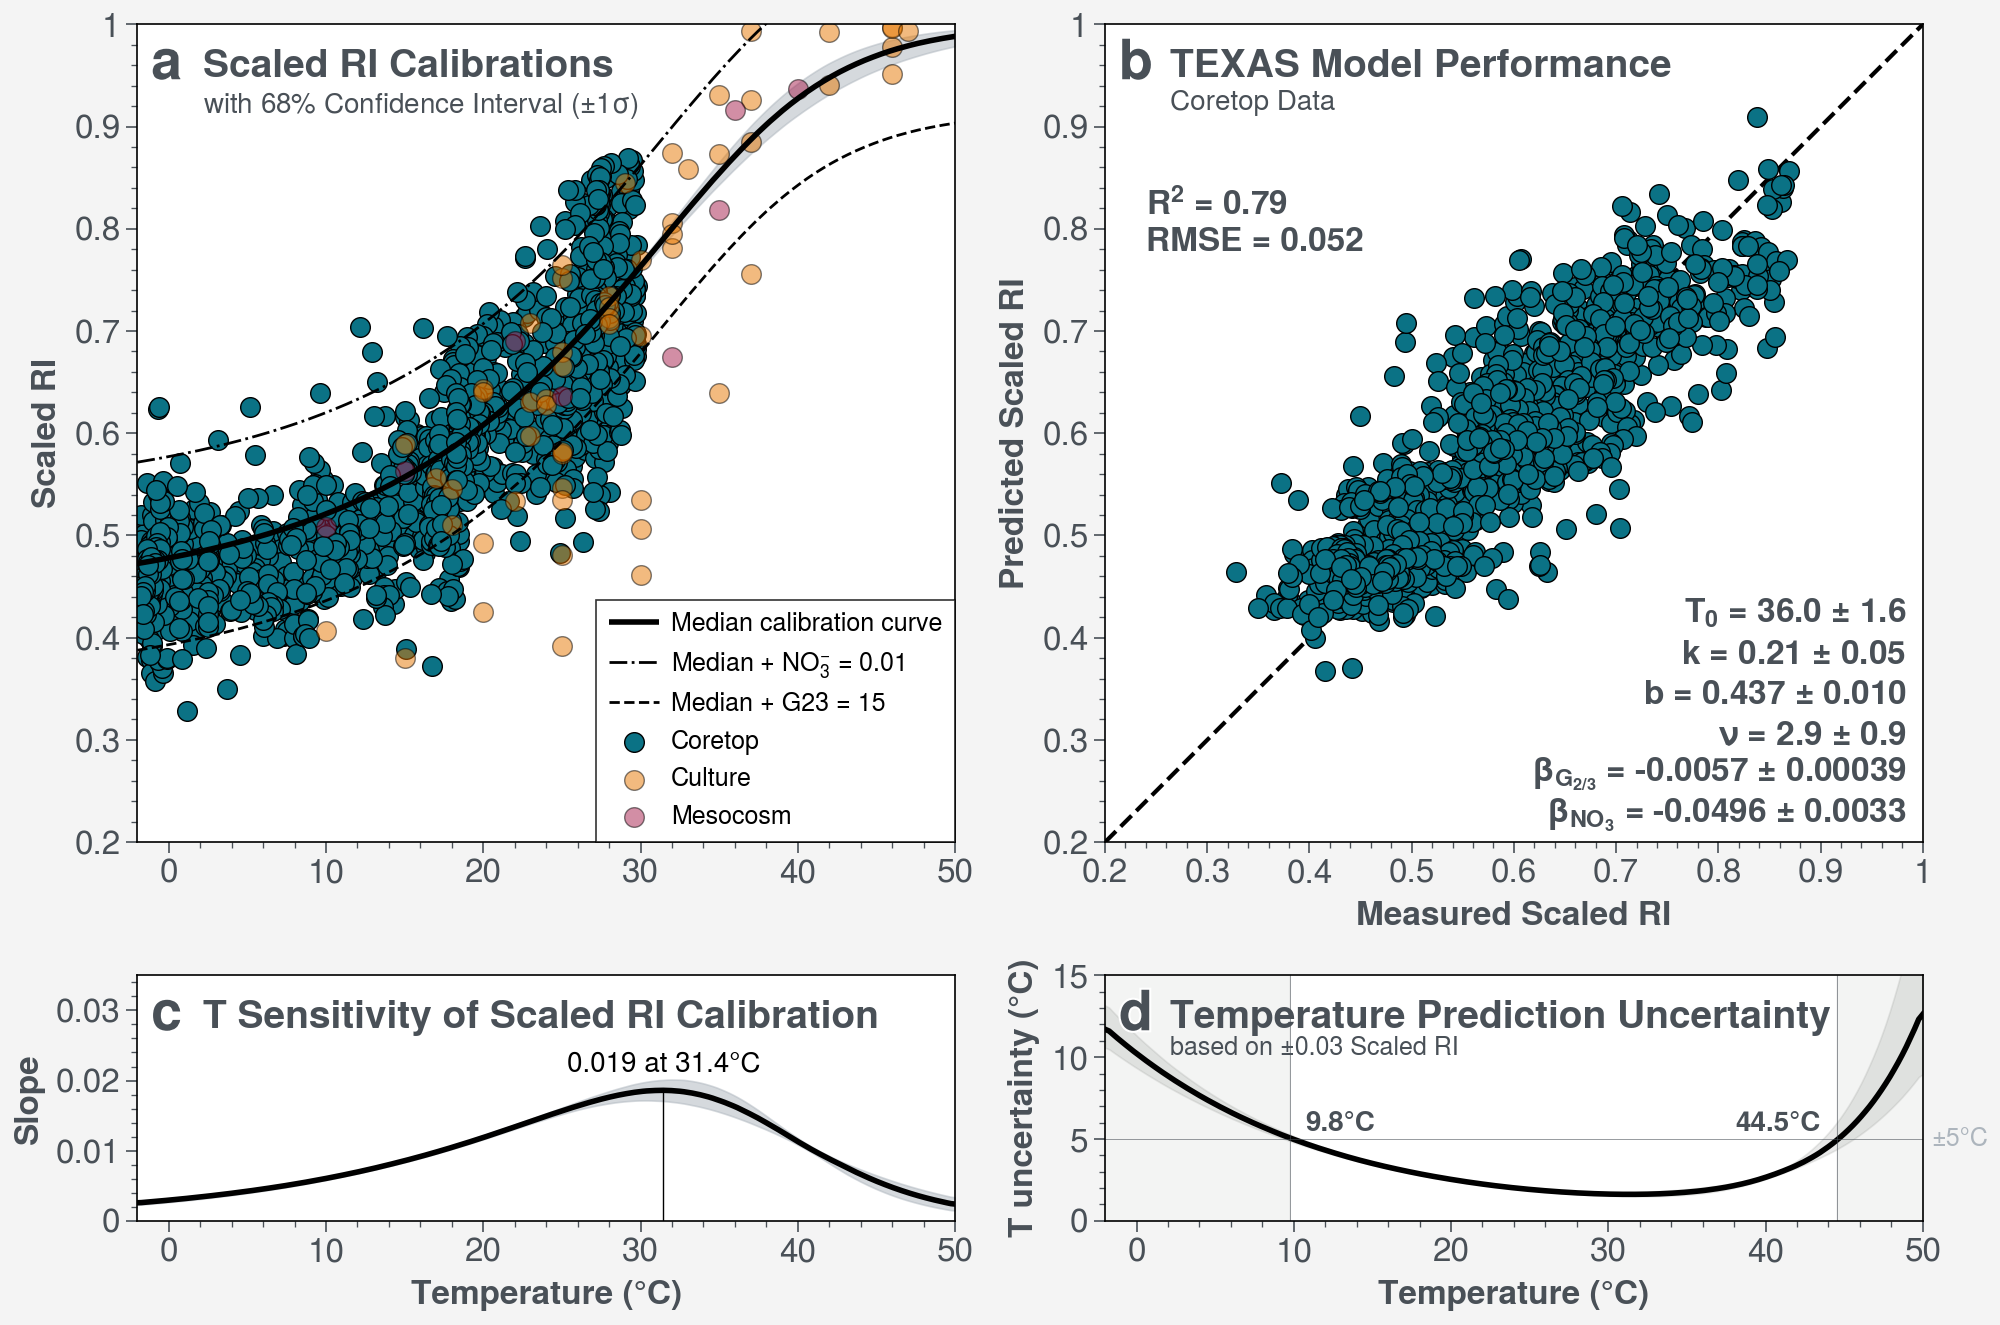

In [57]:
fig, axs = plot.subplots(width=10,ncols=2,nrows=2,
                         share=0,wspace=6,
                         hratios=[1,0.3])
plot_data = plot_coretop_df
XX = np.linspace(-2,50,200)
grouped_all = gridded_combined_df.groupby('datatype')
x_param = 'SST'
x_param_fwd = 'thermoT' if x_param == 't_sf2tc_avg' else x_param
y_param = 'scaledRI_cren3'
no3_threshold = 1.0
for name, group in grouped_all:
    plot_x = group[x_param]
    plot_y = group[y_param]
    axs[0,0].scatter(plot_x, plot_y, s=50,m='o',mec='k',mew=0.5,
            c=datatype_color_dict.get(name),
            alpha=0.5 if name!='coretop' else 1,
            label=name.capitalize())
    
grouped = plot_data.groupby('datatype')
for name, group in grouped: 
    plot_x = group[y_param]
    plot_y = group[f'pred_{y_param}']
    axs[0,1].scatter(plot_x, plot_y, s=50,m='o',mec='k',mew=0.5,
            c=datatype_color_dict.get(name))
   

sel_post_ds = load_posterior(
        f'gen_logi_fixed_hier_crtp_multiv_priorApprox_werr_ver2_{x_param_fwd}_gdgt23ratio_no3_{no3_threshold}_{y_param}_041626_werr_ver2' 
)
# Get all samples
t0_samples = sel_post_ds["t0_crtp"].values.flatten()
b_samples = sel_post_ds["b_crtp"].values.flatten()
k_samples = sel_post_ds["k_crtp"].values.flatten()
v_samples = sel_post_ds["v_crtp"].values.flatten()
beta_gdgt23ratio_samples = sel_post_ds["beta_G23_crtp"].values.flatten()
beta_no3_samples = sel_post_ds["beta_NO3_crtp"].values.flatten()
# Calculate curves for ALL posterior samples
all_curves = []
all_slopes = []
for i in range(len(t0_samples)):
    curve = generalized_logistic_model_fixed_upper(
        XX,
        x0=t0_samples[i],
        b=b_samples[i],
        k=k_samples[i],
        v=v_samples[i],
    )
    all_curves.append(curve)
    
    # Calculate numerical derivative (slope)
    slope = np.gradient(curve, XX)
    all_slopes.append(slope)
    
all_curves = np.array(all_curves)  # Shape: (n_samples, len(XX))
all_slopes = np.array(all_slopes)  # Shape: (n_lines, len(XX))
# Plot credible intervals
median_curve = np.median(all_curves, axis=0)
ci_low = np.percentile(all_curves, 16, axis=0)
ci_high = np.percentile(all_curves, 84, axis=0)

### median curve corrected for median beta_gdgt23ratio and beta_no3 values
median_beta_gdgt23ratio = np.median(beta_gdgt23ratio_samples)
median_beta_no3 = np.median(beta_no3_samples)

median_curve_23_corrected = median_curve + median_beta_gdgt23ratio * 15
median_curve_no3_corrected = median_curve + median_beta_no3 * np.log10(0.01)

axs[0,0].plot(XX, median_curve_23_corrected, 'k--', lw=1, label='Median + G23 = 15', zorder=1)
axs[0,0].plot(XX, median_curve_no3_corrected, 'k-.', lw=1, label=r'Median + NO$_{3}^{-}$ = 0.01', zorder=1)

# Plot
axs[0,0].fill_between(XX, ci_low, ci_high, alpha=0.5, color='gray5', zorder=0)
axs[0,0].plot(XX, median_curve, 'k-', lw=2, label='Median', zorder=1)


# Calculate median and CI
median_slope = np.median(all_slopes, axis=0)
ci_low = np.percentile(all_slopes, 16, axis=0)
ci_high = np.percentile(all_slopes, 84, axis=0)

max_slope_idx = np.argmax(median_slope)
max_slope_value = median_slope[max_slope_idx]
max_slope_temp = XX[max_slope_idx]

# Plot slope vs temperature
ax = axs[1,0]
ax.fill_between(XX, ci_low, ci_high, alpha=0.5, color='gray5')
ax.plot(XX, median_slope, c='k', lw=2, label='Median slope')

ax.plot([max_slope_temp,max_slope_temp], [0, max_slope_value], c='k',lw=0.5)
ax.text(max_slope_temp, max_slope_value*1.1, f'{max_slope_value:.3f} at {max_slope_temp:.1f}°C',
        va='bottom', ha='center', fontsize=10)

################################################################
ax = axs[0,1]
### calculated R-squared and RMSE
from sklearn.metrics import r2_score, mean_squared_error

nonnan_idx = ~plot_data[y_param].isna() & ~plot_data[f'pred_{y_param}'].isna()
r_squared_crtp = r2_score(
    plot_data.loc[nonnan_idx, y_param],
    plot_data.loc[nonnan_idx, f'pred_{y_param}']
)

rmse_crtp = mean_squared_error(
    plot_data.loc[nonnan_idx, y_param],
    plot_data.loc[nonnan_idx, f'pred_{y_param}']
)
text = f'$R^2$ = {_fmt_r2(r_squared_crtp)}\nRMSE = {_fmt_rmse(np.sqrt(rmse_crtp))}'
ax.text(0.05, 0.8, text, transform=ax.transAxes,
        fontsize=12, verticalalignment='top',
        fontweight='bold', color='gray7')

param_label_dict = {
    't0_crtp': r'$T_{0}$',
    'k_crtp': r'$k$',
    'b_crtp': r'$b$',
    'v_crtp': r'$\nu$',
    'beta_G23_crtp': r'$\beta_{G_{2/3}}$',
    'beta_NO3_crtp': r'$\beta_{NO_{3}}$',
    
}
### Posterior sec
var_list = [var_name for var_name in sel_post_ds.data_vars if (('crtp' in var_name) & ~('sigma_' in var_name))][:-2]
for var in var_list:
    var_samples = sel_post_ds[var].values.flatten()
    var_mean = np.mean(var_samples)
    var_sd = np.std(var_samples)
    print(f"{var}: mean={_format_stat(var_mean,var_sd)}")
    fmtted_text = _format_stat(var_mean,var_sd,fmt='.2g') if var == 'beta_G23_crtp' else _format_stat(var_mean,var_sd)
    text = f"{param_label_dict.get(var,var)} = {fmtted_text}"
    ax.text(0.98, 0.26 - 0.05*var_list.index(var), text, transform=ax.transAxes,
            fontsize=12, verticalalignment='bottom',
            horizontalalignment='right',
            fontweight='bold', color='gray7')

ax.plot([0.2,1],[0.2,1],c='k',ls='--',zorder=0)
ax.format(
    xlim=(0.2,1),ylim=(0.2,1),
           xlabel='Measured Scaled RI',
           ylabel='Predicted Scaled RI',
)

for i, ax in enumerate(axs[:,0]):
    ax.format(
        ylim=(0,0.05) if i==1 else (0,1),
        xlim=(-2,50),
        xlabel='Temperature (°C)' if i==1 else '',
        ylabel='Scaled RI' if i==0 else 'Slope',
    )

text = 'Scaled RI Calibrations'
axs[0,0].text(0.08, 0.97, text, transform=axs[0,0].transAxes,
        fontsize=14, verticalalignment='top',
        fontweight='bold', color='gray7')
text = r'with 68% Confidence Interval (±1$\sigma$)'
axs[0,0].text(0.08, 0.92, text, transform=axs[0,0].transAxes,
        fontsize=10, verticalalignment='top', color='gray7')

text = 'TEXAS Model Performance'
axs[0,1].text(0.08, 0.97, text, transform=axs[0,1].transAxes,
        fontsize=14, fontweight='bold',
        verticalalignment='top',
        color='gray7')

text = 'Coretop Data'
axs[0,1].text(0.08, 0.92, text, transform=axs[0,1].transAxes,
        fontsize=10, verticalalignment='top',
        color='gray7')

text = 'T Sensitivity of Scaled RI Calibration'
axs[1,0].text(0.08, 0.9, text, transform=axs[1,0].transAxes,
        fontsize=14, verticalalignment='top',
        fontweight='bold', color='gray7')


h, l = axs[0,0].get_legend_handles_labels()

axs[0,0].legend(h[0:3][::-1]+h[3:],
                ['Median calibration curve','Median + NO$_{3}^{-}$ = 0.01','Median + G23 = 15',]+l[3:], 
                ncol=1,
                fontsize=10, loc='lower right')

################################################################
# Panel (d): Inverse uncertainty
################################################################
ax = axs[1,1]
ax.axis('on')  # Turn axis back on

# Calculate inverse derivatives for all posterior samples
all_inv_slopes = 1 / all_slopes  # dT/dRI = 1/(dRI/dT)

# Propagate RI measurement uncertainty to temperature uncertainty
sigma_RI = 0.03  # Assumed RI analytical uncertainty to be similar to TEX86
all_T_uncertainty = sigma_RI * np.abs(all_inv_slopes)

# Calculate median and CI
median_T_uncertainty = np.median(all_T_uncertainty, axis=0)
ci_low = np.percentile(all_T_uncertainty, 16, axis=0)
ci_high = np.percentile(all_T_uncertainty, 84, axis=0)

# Plot uncertainty vs temperature
ax.fill_between(XX, ci_low, ci_high, alpha=0.2, color='gray')
ax.plot(XX, median_T_uncertainty, c='k', lw=2, label='Median uncertainty')

# Add reference lines
# ax.axhline(3, ls='-', color='gray7', lw=0.2)
ax.axhline(5, ls='-', color='gray7', lw=0.2)

# Add text labels for reference lines
ax.text(1.01, 5, '±5°C', transform=ax.get_yaxis_transform(),
        ha='left', va='center', fontsize=9, color='gray5')

# Find where uncertainty crosses 5°C threshold
threshold = 5.0
# Find crossings (where curve goes above/below threshold)
above_threshold = median_T_uncertainty > threshold
# Find indices where it transitions
crossings = np.where(np.diff(above_threshold.astype(int)))[0]

if len(crossings) >= 2:
    # Low temperature crossing (left side)
    low_T_idx = crossings[0]
    low_T_cross = XX[low_T_idx]
    low_T_unc = median_T_uncertainty[low_T_idx]
    
    # High temperature crossing (right side)  
    high_T_idx = crossings[-1]
    high_T_cross = XX[high_T_idx]
    high_T_unc = median_T_uncertainty[high_T_idx]
    
    # Draw vertical lines at crossings
    
    ax.axvline(low_T_cross, color='gray7', ls='-', lw=0.2)
    ax.axvline(high_T_cross, color='gray7', ls='-', lw=0.2)

    
    # Optional: shade regions with >5°C uncertainty
    ax.axvspan(XX[0], low_T_cross, alpha=0.1, color='gray', zorder=0)
    ax.axvspan(high_T_cross, XX[-1], alpha=0.1, color='gray', zorder=0)

# Format
ax.format(
    xlim=(-2, 50),
    ylim=(0, 15),  # Adjust based on your data
    xlabel='Temperature (°C)',
    ylabel='T uncertainty (°C)',
)

# Add title
text = 'Temperature Prediction Uncertainty'
ax.text(0.08, 0.9, text, transform=ax.transAxes,
        fontsize=14, va='top', ha = 'left',
        fontweight='bold', color='gray7')

# Add note about sigma_RI assumption and precision window
text = f'based on ±{sigma_RI:.2f} Scaled RI'
ax.text(0.08, 0.65, text, transform=ax.transAxes,
        fontsize=9, ha='left', va='bottom', color='gray7')

# text = f'{low_T_cross:.1f}–{high_T_cross:.1f}°C'

if len(crossings) >= 2:
    text = f'{low_T_cross:.1f}°C'
    ax.text(low_T_cross+1, 5.1, text, 
            ha='left', va='bottom', fontsize=10, 
            fontweight='bold', color='gray7')
    text = f'{high_T_cross:.1f}°C'
    ax.text(high_T_cross-1, 5.1, text, 
            ha='right', va='bottom', fontsize=10,
            fontweight='bold', color='gray7')


###########
# Update this line (around line where you currently format axs[:3])
axs.format(grid=False,
           abc=True, abcstyle='a', abcloc='ul', abcsize=20, abcweight='bold', abccolor='gray7',
           fontsize=12, labelsize=12,
           labelcolor='gray7', xtickcolor='gray7', ytickcolor='gray7',
           xticklabelcolor='gray7', yticklabelcolor='gray7',
           xlabelweight='bold', ylabelweight='bold')
axs[0,0].format(ylim=(0.2,1))
axs[1,0].format(ylim=(0,0.035))

fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fname = f'fig7_{x_param}_{y_param}_coretop_calibrations.pdf'
fig.savefig(os.path.join(fpath, fname),dpi=300)

t0_crtp: mean=34.5 ± 1.1
k_crtp: mean=0.25 ± 0.05
b_crtp: mean=0.436 ± 0.009
v_crtp: mean=3.3 ± 0.8
beta_G23_crtp: mean=-0.0054 ± 0.0004
beta_NO3_crtp: mean=-0.0399 ± 0.0035


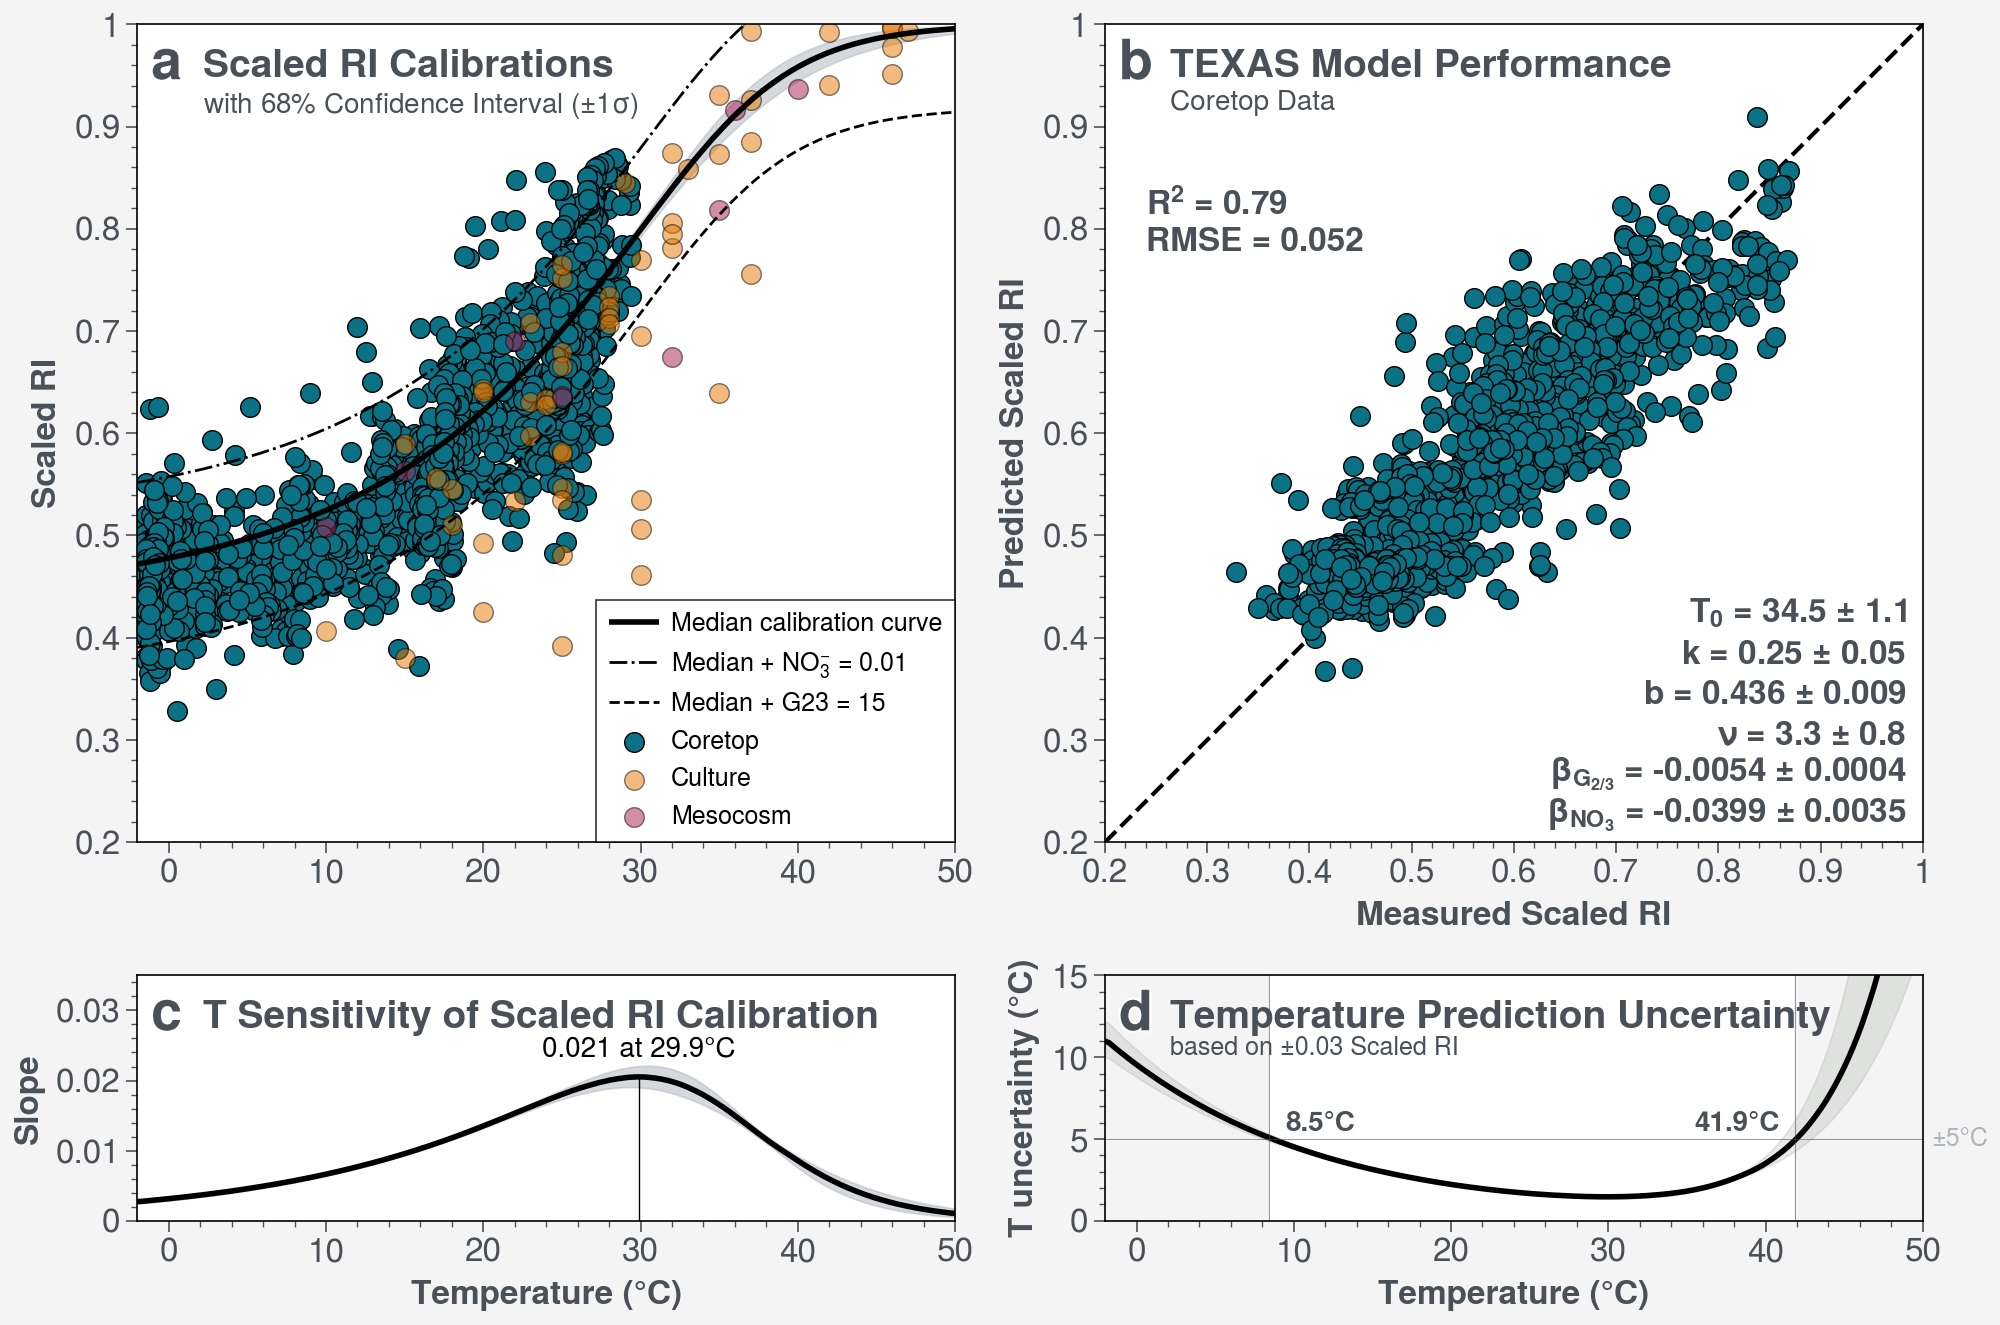

In [59]:
fig, axs = plot.subplots(width=10,ncols=2,nrows=2,
                         share=0,wspace=6,
                         hratios=[1,0.3])
plot_data = plot_coretop_df
XX = np.linspace(-2,50,200)
grouped_all = gridded_combined_df.groupby('datatype')
x_param = 't_sf2tc_avg'
x_param_fwd = 'thermoT' if x_param == 't_sf2tc_avg' else x_param
y_param = 'scaledRI_cren3'
no3_threshold = 1.0
for name, group in grouped_all:
    plot_x = group[x_param]
    plot_y = group[y_param]
    axs[0,0].scatter(plot_x, plot_y, s=50,m='o',mec='k',mew=0.5,
            c=datatype_color_dict.get(name),
            alpha=0.5 if name!='coretop' else 1,
            label=name.capitalize())
    
grouped = plot_data.groupby('datatype')
for name, group in grouped: 
    plot_x = group[y_param]
    plot_y = group[f'pred_{y_param}']
    axs[0,1].scatter(plot_x, plot_y, s=50,m='o',mec='k',mew=0.5,
            c=datatype_color_dict.get(name))
   

sel_post_ds = load_posterior(
        f'gen_logi_fixed_hier_crtp_multiv_priorApprox_werr_ver2_{x_param_fwd}_gdgt23ratio_no3_{no3_threshold}_{y_param}_041626_werr_ver2' 
)
# Get all samples
t0_samples = sel_post_ds["t0_crtp"].values.flatten()
b_samples = sel_post_ds["b_crtp"].values.flatten()
k_samples = sel_post_ds["k_crtp"].values.flatten()
v_samples = sel_post_ds["v_crtp"].values.flatten()
beta_gdgt23ratio_samples = sel_post_ds["beta_G23_crtp"].values.flatten()
beta_no3_samples = sel_post_ds["beta_NO3_crtp"].values.flatten()
# Calculate curves for ALL posterior samples
all_curves = []
all_slopes = []
for i in range(len(t0_samples)):
    curve = generalized_logistic_model_fixed_upper(
        XX,
        x0=t0_samples[i],
        b=b_samples[i],
        k=k_samples[i],
        v=v_samples[i],
    )
    all_curves.append(curve)
    
    # Calculate numerical derivative (slope)
    slope = np.gradient(curve, XX)
    all_slopes.append(slope)
    
all_curves = np.array(all_curves)  # Shape: (n_samples, len(XX))
all_slopes = np.array(all_slopes)  # Shape: (n_lines, len(XX))
# Plot credible intervals
median_curve = np.median(all_curves, axis=0)
ci_low = np.percentile(all_curves, 16, axis=0)
ci_high = np.percentile(all_curves, 84, axis=0)

### median curve corrected for median beta_gdgt23ratio and beta_no3 values
median_beta_gdgt23ratio = np.median(beta_gdgt23ratio_samples)
median_beta_no3 = np.median(beta_no3_samples)

median_curve_23_corrected = median_curve + median_beta_gdgt23ratio * 15
median_curve_no3_corrected = median_curve + median_beta_no3 * np.log10(0.01)

axs[0,0].plot(XX, median_curve_23_corrected, 'k--', lw=1, label='Median + G23 = 15', zorder=1)
axs[0,0].plot(XX, median_curve_no3_corrected, 'k-.', lw=1, label=r'Median + NO$_{3}^{-}$ = 0.01', zorder=1)

# Plot
axs[0,0].fill_between(XX, ci_low, ci_high, alpha=0.5, color='gray5', zorder=0)
axs[0,0].plot(XX, median_curve, 'k-', lw=2, label='Median', zorder=1)


# Calculate median and CI
median_slope = np.median(all_slopes, axis=0)
ci_low = np.percentile(all_slopes, 16, axis=0)
ci_high = np.percentile(all_slopes, 84, axis=0)

max_slope_idx = np.argmax(median_slope)
max_slope_value = median_slope[max_slope_idx]
max_slope_temp = XX[max_slope_idx]

# Plot slope vs temperature
ax = axs[1,0]
ax.fill_between(XX, ci_low, ci_high, alpha=0.5, color='gray5')
ax.plot(XX, median_slope, c='k', lw=2, label='Median slope')

ax.plot([max_slope_temp,max_slope_temp], [0, max_slope_value], c='k',lw=0.5)
ax.text(max_slope_temp, max_slope_value*1.1, f'{max_slope_value:.3f} at {max_slope_temp:.1f}°C',
        va='bottom', ha='center', fontsize=10)

################################################################
ax = axs[0,1]
### calculated R-squared and RMSE
from sklearn.metrics import r2_score, mean_squared_error

nonnan_idx = ~plot_data[y_param].isna() & ~plot_data[f'pred_{y_param}'].isna()
r_squared_crtp = r2_score(
    plot_data.loc[nonnan_idx, y_param],
    plot_data.loc[nonnan_idx, f'pred_{y_param}']
)

rmse_crtp = mean_squared_error(
    plot_data.loc[nonnan_idx, y_param],
    plot_data.loc[nonnan_idx, f'pred_{y_param}']
)
text = f'$R^2$ = {_fmt_r2(r_squared_crtp)}\nRMSE = {_fmt_rmse(np.sqrt(rmse_crtp))}'
ax.text(0.05, 0.8, text, transform=ax.transAxes,
        fontsize=12, verticalalignment='top',
        fontweight='bold', color='gray7')

param_label_dict = {
    't0_crtp': r'$T_{0}$',
    'k_crtp': r'$k$',
    'b_crtp': r'$b$',
    'v_crtp': r'$\nu$',
    'beta_G23_crtp': r'$\beta_{G_{2/3}}$',
    'beta_NO3_crtp': r'$\beta_{NO_{3}}$',
    
}
### Posterior sec
var_list = [var_name for var_name in sel_post_ds.data_vars if (('crtp' in var_name) & ~('sigma_' in var_name))][:-2]
for var in var_list:
    var_samples = sel_post_ds[var].values.flatten()
    var_mean = np.mean(var_samples)
    var_sd = np.std(var_samples)
    print(f"{var}: mean={_format_stat(var_mean,var_sd)}")
    fmtted_text = _format_stat(var_mean,var_sd,fmt='.2g') if var == 'beta_G23_crtp' else _format_stat(var_mean,var_sd)
    text = f"{param_label_dict.get(var,var)} = {fmtted_text}"
    ax.text(0.98, 0.26 - 0.05*var_list.index(var), text, transform=ax.transAxes,
            fontsize=12, verticalalignment='bottom',
            horizontalalignment='right',
            fontweight='bold', color='gray7')

ax.plot([0.2,1],[0.2,1],c='k',ls='--',zorder=0)
ax.format(
    xlim=(0.2,1),ylim=(0.2,1),
           xlabel='Measured Scaled RI',
           ylabel='Predicted Scaled RI',
)

for i, ax in enumerate(axs[:,0]):
    ax.format(
        ylim=(0,0.05) if i==1 else (0,1),
        xlim=(-2,50),
        xlabel='Temperature (°C)' if i==1 else '',
        ylabel='Scaled RI' if i==0 else 'Slope',
    )

text = 'Scaled RI Calibrations'
axs[0,0].text(0.08, 0.97, text, transform=axs[0,0].transAxes,
        fontsize=14, verticalalignment='top',
        fontweight='bold', color='gray7')
text = r'with 68% Confidence Interval (±1$\sigma$)'
axs[0,0].text(0.08, 0.92, text, transform=axs[0,0].transAxes,
        fontsize=10, verticalalignment='top', color='gray7')

text = 'TEXAS Model Performance'
axs[0,1].text(0.08, 0.97, text, transform=axs[0,1].transAxes,
        fontsize=14, fontweight='bold',
        verticalalignment='top',
        color='gray7')

text = 'Coretop Data'
axs[0,1].text(0.08, 0.92, text, transform=axs[0,1].transAxes,
        fontsize=10, verticalalignment='top',
        color='gray7')

text = 'T Sensitivity of Scaled RI Calibration'
axs[1,0].text(0.08, 0.9, text, transform=axs[1,0].transAxes,
        fontsize=14, verticalalignment='top',
        fontweight='bold', color='gray7')


h, l = axs[0,0].get_legend_handles_labels()

axs[0,0].legend(h[0:3][::-1]+h[3:],
                ['Median calibration curve','Median + NO$_{3}^{-}$ = 0.01','Median + G23 = 15',]+l[3:], 
                ncol=1,
                fontsize=10, loc='lower right')

################################################################
# Panel (d): Inverse uncertainty
################################################################
ax = axs[1,1]
ax.axis('on')  # Turn axis back on

# Calculate inverse derivatives for all posterior samples
all_inv_slopes = 1 / all_slopes  # dT/dRI = 1/(dRI/dT)

# Propagate RI measurement uncertainty to temperature uncertainty
sigma_RI = 0.03  # Assumed RI analytical uncertainty to be similar to TEX86
all_T_uncertainty = sigma_RI * np.abs(all_inv_slopes)

# Calculate median and CI
median_T_uncertainty = np.median(all_T_uncertainty, axis=0)
ci_low = np.percentile(all_T_uncertainty, 16, axis=0)
ci_high = np.percentile(all_T_uncertainty, 84, axis=0)

# Plot uncertainty vs temperature
ax.fill_between(XX, ci_low, ci_high, alpha=0.2, color='gray')
ax.plot(XX, median_T_uncertainty, c='k', lw=2, label='Median uncertainty')

# Add reference lines
# ax.axhline(3, ls='-', color='gray7', lw=0.2)
ax.axhline(5, ls='-', color='gray7', lw=0.2)

# Add text labels for reference lines
ax.text(1.01, 5, '±5°C', transform=ax.get_yaxis_transform(),
        ha='left', va='center', fontsize=9, color='gray5')

# Find where uncertainty crosses 5°C threshold
threshold = 5.0
# Find crossings (where curve goes above/below threshold)
above_threshold = median_T_uncertainty > threshold
# Find indices where it transitions
crossings = np.where(np.diff(above_threshold.astype(int)))[0]

if len(crossings) >= 2:
    # Low temperature crossing (left side)
    low_T_idx = crossings[0]
    low_T_cross = XX[low_T_idx]
    low_T_unc = median_T_uncertainty[low_T_idx]
    
    # High temperature crossing (right side)  
    high_T_idx = crossings[-1]
    high_T_cross = XX[high_T_idx]
    high_T_unc = median_T_uncertainty[high_T_idx]
    
    # Draw vertical lines at crossings
    
    ax.axvline(low_T_cross, color='gray7', ls='-', lw=0.2)
    ax.axvline(high_T_cross, color='gray7', ls='-', lw=0.2)

    
    # Optional: shade regions with >5°C uncertainty
    ax.axvspan(XX[0], low_T_cross, alpha=0.1, color='gray', zorder=0)
    ax.axvspan(high_T_cross, XX[-1], alpha=0.1, color='gray', zorder=0)

# Format
ax.format(
    xlim=(-2, 50),
    ylim=(0, 15),  # Adjust based on your data
    xlabel='Temperature (°C)',
    ylabel='T uncertainty (°C)',
)

# Add title
text = 'Temperature Prediction Uncertainty'
ax.text(0.08, 0.9, text, transform=ax.transAxes,
        fontsize=14, va='top', ha = 'left',
        fontweight='bold', color='gray7')

# Add note about sigma_RI assumption and precision window
text = f'based on ±{sigma_RI:.2f} Scaled RI'
ax.text(0.08, 0.65, text, transform=ax.transAxes,
        fontsize=9, ha='left', va='bottom', color='gray7')

# text = f'{low_T_cross:.1f}–{high_T_cross:.1f}°C'

if len(crossings) >= 2:
    text = f'{low_T_cross:.1f}°C'
    ax.text(low_T_cross+1, 5.1, text, 
            ha='left', va='bottom', fontsize=10, 
            fontweight='bold', color='gray7')
    text = f'{high_T_cross:.1f}°C'
    ax.text(high_T_cross-1, 5.1, text, 
            ha='right', va='bottom', fontsize=10,
            fontweight='bold', color='gray7')


###########
# Update this line (around line where you currently format axs[:3])
axs.format(grid=False,
           abc=True, abcstyle='a', abcloc='ul', abcsize=20, abcweight='bold', abccolor='gray7',
           fontsize=12, labelsize=12,
           labelcolor='gray7', xtickcolor='gray7', ytickcolor='gray7',
           xticklabelcolor='gray7', yticklabelcolor='gray7',
           xlabelweight='bold', ylabelweight='bold')
axs[0,0].format(ylim=(0.2,1))
axs[1,0].format(ylim=(0,0.035))

fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fname = f'fig7b_{x_param}_{y_param}_coretop_calibrations.pdf'
fig.savefig(os.path.join(fpath, fname),dpi=300)

In [60]:
# url = 'https://www.ncei.noaa.gov/pub/data/paleo/contributions_by_author/tierney2015/tierney2015tex86.txt'
# TT15_coretop_df = pd.read_csv(
#     url,
#     sep='\t',
#     comment='#',
#     na_values='-999'
# )
# TT15_coretop_df = TT15_coretop_df.dropna(subset=['tex86','WOA09_SST']).reset_index(drop=True)
# TT15_coretop_df['binned_tex86'] = pd.cut(TT15_coretop_df['tex86'], bins=np.arange(0,1.05,0.05), right=False)


# methods = ['schouten02','kim2010_tex86H','OBrien17']
# for method in methods:
#     TT15_coretop_df[f'predSST_{method}'] = predictSSTfromTEX(
#         input_tex=TT15_coretop_df['tex86'],
#         method_name=method
#     )
    
#     TT15_coretop_df[f'Tres_{method}'] = TT15_coretop_df['WOA09_SST'] - TT15_coretop_df[f'predSST_{method}']
    
# ### predict T from TEX86 with BAYSPAR
# TT15_coretop_df['predSST_bayspar_mean'] = np.nan
# for i in tqdm(range(len(TT15_coretop_df))):
#     try:
#         TT15_coretop_df.loc[i,'predSST_bayspar_mean'] = bsr.predict_seatemp(TT15_coretop_df['tex86'].iloc[i].reshape(1),
#                                                                              lon=TT15_coretop_df['longitude'].iloc[i].reshape(1),
#                                                                              lat=TT15_coretop_df['latitude'].iloc[i].reshape(1),
#                                                                              prior_std=6,temptype='sst').percentile(50)[0]
        
#         TT15_coretop_df.loc[i,'Tres_bayspar'] = TT15_coretop_df['WOA09_SST'].iloc[i] - TT15_coretop_df.loc[i,'predSST_bayspar_mean']
#     except:
#         continue
    
# ### save for reuse
# fpath = f'{local_github_path}/data/spreadsheets'
# fname = 'TT15_coretop_data.pkl'
# TT15_coretop_df.to_pickle(os.path.join(fpath,fname))

### reload
fpath = f'{local_github_path}/data/spreadsheets'
fname = 'TT15_coretop_data.pkl'
TT15_coretop_df = pd.read_pickle(os.path.join(fpath,fname))
TT15_coretop_df

,core_name,core_type,sample_depth_start,sample_depth_end,longitude,latitude,depth,tex86,WOA09_SST,OISST_SST,...,Unnamed: 19,binned_tex86,predSST_schouten02,Tres_schouten02,predSST_kim2010_tex86H,Tres_kim2010_tex86H,predSST_OBrien17,Tres_OBrien17,predSST_bayspar_mean,Tres_bayspar
0,GeoB7702-3,GC,5.0,6.0,34.073300,31.651700,562.0,0.662,22.0,22.5,...,NaN,"[0.65, 0.7)",25.466655,-3.466655,26.346686,-4.346686,27.764657,-5.764657,24.455290,-2.455290
1,KNR195-5-17 MC42,MC,0.0,1.0,-89.685500,-1.253000,615.0,0.563,23.1,23.8,...,NaN,"[0.55, 0.6)",18.866652,4.233348,21.534774,1.565226,21.941130,1.158870,22.420139,0.679861
2,KNR195-5-9 MC22,MC,0.0,1.0,-81.250000,-3.850300,689.0,0.567,22.2,22.3,...,NaN,"[0.55, 0.6)",19.133319,3.066681,21.745081,0.454919,22.176424,0.023575,22.256721,-0.056721
3,KNR195-5-15 MC38,MC,0.0,1.0,-89.699300,-1.265700,597.0,0.567,23.1,23.8,...,NaN,"[0.55, 0.6)",19.133319,3.966681,21.745081,1.354919,22.176424,0.923576,22.727981,0.372019
4,KNR195-5-8 MC18,MC,0.0,1.0,-81.310000,-3.986700,1020.0,0.568,22.2,22.3,...,NaN,"[0.55, 0.6)",19.199986,3.000014,21.797426,0.402574,22.235248,-0.035248,22.425540,-0.225540
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,64PE301 P1500,MC,0.0,0.5,63.075000,22.078333,1495.0,0.730,26.6,26.7,...,NaN,"[0.7, 0.75)",29.999991,-3.399991,29.251284,-2.651284,31.764655,-5.164655,26.297506,0.302494
1091,64PE301 P1800,MC,0.0,0.5,63.408333,22.308333,1786.0,0.730,26.6,26.8,...,NaN,"[0.7, 0.75)",29.999991,-3.399991,29.251284,-2.651284,31.764655,-5.164655,26.294891,0.305109
1092,64PE301 P2000,MC,0.0,0.5,63.018611,22.144722,1970.0,0.720,26.6,26.7,...,NaN,"[0.7, 0.75)",29.333324,-2.733324,28.841543,-2.241543,31.176420,-4.576420,25.822069,0.777931
1093,64PE301 P2500,MC,0.0,0.5,62.895000,22.104722,2470.0,0.720,26.6,26.7,...,NaN,"[0.7, 0.75)",29.333324,-2.733324,28.841543,-2.241543,31.176420,-4.576420,25.880041,0.719959


In [61]:
methods = ['schouten02','kim2010_tex86H']
features = ['tex86','WOA09_SST']
temp_features = ['predSST_bayspar_mean'] + [f'predSST_{method}' for method in methods] 
predicted_SST_df = TT15_coretop_df[TT15_coretop_df['latitude']<70].copy()
predicted_SST_df['t_est_range'] = predicted_SST_df[temp_features].max(axis=1) - predicted_SST_df[temp_features].min(axis=1)
predicted_SST_df = predicted_SST_df.sort_values(by='tex86').reset_index(drop=True)
predicted_SST_df['binned_tex86'] = pd.cut(predicted_SST_df['tex86'], bins=np.arange(0,1.05,0.1), right=False)
predicted_SST_df

,core_name,core_type,sample_depth_start,sample_depth_end,longitude,latitude,depth,tex86,WOA09_SST,OISST_SST,...,binned_tex86,predSST_schouten02,Tres_schouten02,predSST_kim2010_tex86H,Tres_kim2010_tex86H,predSST_OBrien17,Tres_OBrien17,predSST_bayspar_mean,Tres_bayspar,t_est_range
0,PS69/853-2,MC,0.0,1.0,69.2178,-65.9980,2365.0,0.204,0.2,-1.3,...,"[0.2, 0.3)",-5.066693,5.266693,-8.621297,8.821297,0.823494,-0.623494,-6.181873,6.381873,3.554603
1,PS69/878-4,GBC,0.0,1.0,82.6562,-65.3425,3093.0,0.268,-1.0,-1.5,...,"[0.2, 0.3)",-0.800024,-0.199976,-0.515580,-0.484420,4.588198,-5.588198,-2.733309,1.733309,2.217729
2,B49,grab,0.0,1.0,-166.2500,63.3000,NaN,0.271,3.4,2.6,...,"[0.2, 0.3)",-0.600024,4.000024,-0.184901,3.584901,4.764669,-1.364669,-1.954891,5.354891,1.769990
3,B42,grab,0.0,1.0,-166.7500,62.9500,NaN,0.286,8.2,2.7,...,"[0.2, 0.3)",0.399976,7.800024,1.415437,6.784563,5.647021,2.552979,-0.902260,9.102260,2.317696
4,B50,grab,0.0,1.0,-165.6050,63.6533,NaN,0.289,4.1,2.9,...,"[0.2, 0.3)",0.599976,3.500024,1.725412,2.374588,5.823491,-1.723491,-0.803573,4.903573,2.528986
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
901,RS42-MC113,MC,5.0,6.0,38.6080,19.6400,1991.0,0.866,28.8,28.6,...,"[0.8, 0.9)",39.066662,-10.266662,34.326224,-5.526224,39.764651,-10.964651,28.710536,0.089464,10.356126
902,RS41-MC101,MC,5.0,6.0,38.4230,20.1050,2309.0,0.866,28.6,28.5,...,"[0.8, 0.9)",39.066662,-10.466662,34.326224,-5.726224,39.764651,-11.164651,28.686059,-0.086059,10.380603
903,RS26-MC73,MC,5.0,6.0,37.3770,22.9150,1324.0,0.867,27.4,27.5,...,"[0.8, 0.9)",39.133329,-11.733329,34.360506,-6.960506,39.823475,-12.423475,28.645780,-1.245780,10.487549
904,RS31-MC85,MC,5.0,6.0,37.9800,21.4280,1538.0,0.876,28.0,28.1,...,"[0.8, 0.9)",39.733329,-11.733329,34.667281,-6.667281,40.352886,-12.352886,29.149003,-1.149003,10.584326


In [62]:
methods = ['schouten02', 'kim2010_tex86H', 'OBrien17']                                                                                             
value_cols = [f'Tres_{m}' for m in methods] + ['Tres_bayspar']                                                                                     
            
binned_t_res_df = (                                                                                                                                
    predicted_SST_df.groupby('binned_tex86', observed=True)[value_cols]                                                                                            
    .agg(['min', 'mean', 'max'])
    .reset_index()                                                                                                                                 
)          
binned_t_res_df.columns = ['_'.join(col).strip('_') for col in binned_t_res_df.columns]
binned_t_res_df

,binned_tex86,Tres_schouten02_min,Tres_schouten02_mean,Tres_schouten02_max,Tres_kim2010_tex86H_min,Tres_kim2010_tex86H_mean,Tres_kim2010_tex86H_max,Tres_OBrien17_min,Tres_OBrien17_mean,Tres_OBrien17_max,Tres_bayspar_min,Tres_bayspar_mean,Tres_bayspar_max
0,"[0.2, 0.3)",-1.466643,2.157600,7.800024,-2.935909,1.526158,8.821297,-6.611727,-3.137930,2.552979,1.733309,4.553428,9.102260
1,"[0.3, 0.4)",-9.099980,-1.099593,10.766687,-12.457271,-4.019594,7.471181,-13.476430,-5.733554,6.335335,-4.065099,0.713652,8.133694
2,"[0.4, 0.5)",-12.366649,0.794679,8.633353,-15.889830,-2.690357,5.223515,-16.217604,-3.208183,4.311806,-6.846317,0.254808,7.418603
3,"[0.5, 0.6)",-8.333317,1.832279,9.966683,-11.572028,-0.967368,6.677456,-11.799956,-1.348901,6.452986,-8.635578,-0.071526,5.586894
4,"[0.6, 0.7)",-9.899990,-0.093623,5.733346,-10.261235,-1.131270,3.780995,-12.017598,-2.461347,3.011812,-10.042791,-0.884844,3.098210
5,"[0.7, 0.8)",-7.633326,-1.845626,1.233343,-5.747650,-1.258014,1.252888,-9.052889,-3.663045,-0.758773,-5.435000,-0.914663,2.023330
6,"[0.8, 0.9)",-12.999996,-9.958725,-6.299994,-7.604467,-5.896081,-3.186709,-13.541121,-10.826276,-7.405829,-4.803178,-1.001112,1.711523


In [63]:
binned_tex_t_est_df = (
    predicted_SST_df
    .groupby('binned_tex86', observed=True)['t_est_range']                                                                                         
    .agg(['min', 'max', 'mean'])
    .rename(columns={'min': 't_est_range_min', 'max': 't_est_range_max', 'mean': 't_est_range_mean'})                                              
    .reset_index()                                                                                                                                 
)          
binned_tex_t_est_df['mid_tex_bin'] = binned_tex_t_est_df['binned_tex86'].apply(lambda iv: iv.mid)
binned_tex_t_est_df

,binned_tex86,t_est_range_min,t_est_range_max,t_est_range_mean,mid_tex_bin
0,"[0.2, 0.3)",1.769990,6.445782,3.572181,0.25
1,"[0.3, 0.4)",2.032704,10.600902,5.457420,0.35
2,"[0.4, 0.5)",3.364127,10.763772,4.466691,0.45
3,"[0.5, 0.6)",2.092226,6.881008,3.283259,0.55
4,"[0.6, 0.7)",0.237824,5.462649,1.973433,0.65
5,"[0.7, 0.8)",0.239794,8.725564,1.666549,0.75
6,"[0.8, 0.9)",3.447877,10.873801,8.967981,0.85


Data <70N len:  906
Data >70N len:  189
Lat/Lon Red Sea:  21.875 37.875
Lat/Lon Mediterranean:  41.875 12.875
Lat/Lon Southern Ocean:  -61.875 -158.0


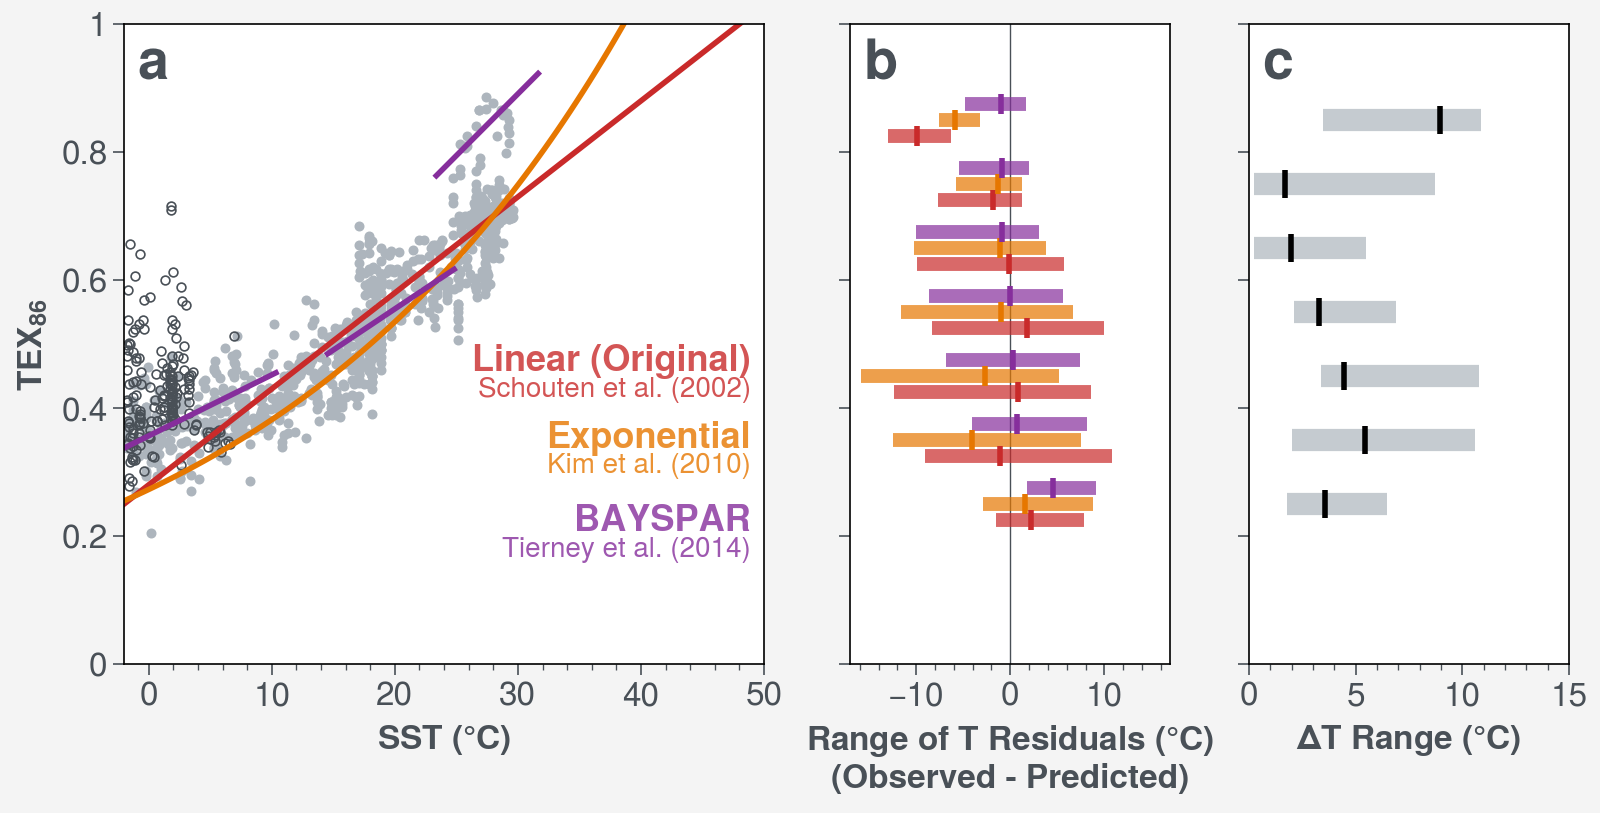

In [64]:
fig, axs = plot.subplots(width=8,ncols=3,wratios=[1,0.5,0.5],sharex=0)

ax = axs[0] 
# grouped = gridded_combined_df.groupby('datatype')
# for name, group in grouped:
#     if name!='coretop':
#         continue
#     else:
#         ax.scatter(group['SST'], group['TEX86'], 
#                 m=datatype_marker_dict.get(name,'o'), 
#                 mec='none' if name=='coretop' else 'black',
#                 label=name,
#                 color=datatype_color_dict.get(name,'gray5'),)

below70N_idx = TT15_coretop_df['latitude']<70
ax.scatter(TT15_coretop_df['WOA09_SST'][below70N_idx], TT15_coretop_df['tex86'][below70N_idx],
           m='.',
           c='gray5')
print("Data <70N len: ",len(TT15_coretop_df['WOA09_SST'][below70N_idx]))
ax.scatter(TT15_coretop_df['WOA09_SST'][~below70N_idx], TT15_coretop_df['tex86'][~below70N_idx],
           m='o',mec='gray7',s=10,
           facecolor='none',
           label='>70°N')
print("Data >70N len: ",len(TT15_coretop_df['WOA09_SST'][~below70N_idx]))
ax.format(
    xlabel=r'SST ($\degree$C)',
    ylabel=r'TEX$_{86}$',
)

#### existing calibration models

temperature_range = np.linspace(-2, 50, 100)
methods = ['schouten02','kim2010_tex86H']
colors = ['red9','yellow9','lime9']
for i, method_name in enumerate(methods):
    predicted_tex = predictTEXfromSST(temperature_range,method_name=method_name)
    ax.plot(temperature_range, predicted_tex,
            c=colors[i],lw=2,
            ls='-',
            label=f'{method_name}',)
    
#### bayspar forward model

mid_redsea_lat = coretop_df[coretop_df['regionName']=='Red Sea']['match_lat_04deg'].median()
mid_redsea_lon = coretop_df[coretop_df['regionName']=='Red Sea']['match_lon_04deg'].median()
min_redsea_sst = coretop_df[coretop_df['regionName']=='Red Sea']['SST'].min()-2
max_redsea_sst = coretop_df[coretop_df['regionName']=='Red Sea']['SST'].max()+2
print("Lat/Lon Red Sea: ", mid_redsea_lat, mid_redsea_lon)
xx = np.linspace(min_redsea_sst, max_redsea_sst, 50)
pred_tex_redsea = bsr.predict_tex(
    xx,
    lat=mid_redsea_lat,
    lon=mid_redsea_lon,
    temptype='sst'
).percentile(50)

ax.plot([xx.min(),xx.max()], [pred_tex_redsea.min(),pred_tex_redsea.max()],
        c='grape9',lw=2,
        ls='-',
        label=f'Bayspar Red Sea',)


min_mediterranean_sst = coretop_df[coretop_df['regionName']=='Mediterranean']['SST'].min()-2
max_mediterranean_sst = coretop_df[coretop_df['regionName']=='Mediterranean']['SST'].max()+2
xx = np.linspace(min_mediterranean_sst, max_mediterranean_sst, 50)

mid_mediterranean_lat = coretop_df[coretop_df['regionName']=='Mediterranean']['match_lat_04deg'].median()
mid_mediterranean_lon = coretop_df[coretop_df['regionName']=='Mediterranean']['match_lon_04deg'].median()
print("Lat/Lon Mediterranean: ", mid_mediterranean_lat, mid_mediterranean_lon)
pred_tex_mediterranean = bsr.predict_tex(
    xx,
    lat=mid_mediterranean_lat,
    lon=mid_mediterranean_lon,
    temptype='sst'
).percentile([10,50,90])

ax.plot([xx.min(),xx.max()], [pred_tex_mediterranean[:,1].min(),pred_tex_mediterranean[:,1].max()],
        c='grape9',lw=2,
        ls='-',
        label=f'Bayspar Mediterranean Sea',)

# ax.fill_between([xx.min(),xx.max()], 
#                 [pred_tex_mediterranean[:,0].min(),pred_tex_mediterranean[:,0].max()],
#                 [pred_tex_mediterranean[:,2].min(),pred_tex_mediterranean[:,2].max()],
#                 color='grape9',alpha=0.2)

min_southernocean_sst = coretop_df[coretop_df['regionName']=='Pacific-Southern Ocean']['SST'].min()-2
max_southernocean_sst = coretop_df[coretop_df['regionName']=='Pacific-Southern Ocean']['SST'].max()+2
xx = np.linspace(min_southernocean_sst, max_southernocean_sst, 50)
mid_southernocean_lat = coretop_df[coretop_df['regionName']=='Pacific-Southern Ocean']['match_lat_04deg'].median()
mid_southernocean_lon = coretop_df[coretop_df['regionName']=='Pacific-Southern Ocean']['match_lon_04deg'].median()
print("Lat/Lon Southern Ocean: ", mid_southernocean_lat, mid_southernocean_lon)
pred_tex_southernocean = bsr.predict_tex(
    xx,
    lat=mid_southernocean_lat,
    lon=mid_southernocean_lon,
    temptype='sst'
).percentile([10,50,90])

ax.plot([xx.min(),xx.max()], [pred_tex_southernocean[:,1].min(),pred_tex_southernocean[:,1].max()],
        c='grape9',lw=2,
        ls='-',
        label=f'Bayspar Southern Ocean',)

ax.format(
    ylim=(0,1),
    xlim=(-2,50),
    tickminor=False
)

method_list = ['schouten02','kim2010_tex86H']
annonation_dict = {
    "schouten02":{"text": "Linear (Original)","y_top": 0.5,"color": 'red9',
              "source":"Schouten et al. (2002)"},
    "kim2010_tex86H":{"text": "Exponential","y_top": 0.38,"color": 'yellow9',
                "source":"Kim et al. (2010)"},
    "BAYSPAR":{"text": "BAYSPAR","y_top": 0.25,"color": 'grape9',
                "source":"Tierney et al. (2014)"},
}
### Calibration models annotation
for i, method_name in enumerate(methods):
    if method_name in annonation_dict:
        text_str = annonation_dict[method_name]["text"]
        y_top = annonation_dict[method_name]["y_top"]
        color = annonation_dict[method_name]["color"]
        ax.text(0.98,y_top,
                text_str,
                transform=ax.transAxes,
                color=color,
                fontsize=13, fontweight='bold',
                ha='right',
                va='top',
                alpha=0.8
               )
        ax.text(0.98,y_top-0.05,
                annonation_dict[method_name]["source"],
                transform=ax.transAxes,
                color=color,
                fontsize=10,
                ha='right',
                va='top',
                alpha=0.8
               )
### annotation for BAYSPAR
text_str = annonation_dict["BAYSPAR"]["text"]
y_top = annonation_dict["BAYSPAR"]["y_top"]
color = annonation_dict["BAYSPAR"]["color"]
ax.text(0.98,y_top,
        text_str,
        transform=ax.transAxes,
        color=color,
        fontsize=13, fontweight='bold',
        ha='right',
        va='top',
        alpha=0.8
       )
ax.text(0.98,y_top-0.05,
        annonation_dict["BAYSPAR"]["source"],
        transform=ax.transAxes,
        color=color,
        fontsize=10,
        ha='right',
        va='top',
        alpha=0.8
       )
#### boxplot of T residuals
ax = axs[1]
method_list = ['schouten02','kim2010_tex86H','bayspar']
colors = ['red9','yellow9','grape9']
ypos_offset = [-0.025,0,0.025]
for i in range(len(binned_t_res_df)):
    ypos = binned_t_res_df['binned_tex86'].iloc[i].mid
    for j, method_name in enumerate(method_list):
        res_min = binned_t_res_df[f'Tres_{method_name}_min'].iloc[i]
        res_max = binned_t_res_df[f'Tres_{method_name}_max'].iloc[i]
        res_mean = binned_t_res_df[f'Tres_{method_name}_mean'].iloc[i]
        ax.plot([res_min, res_max],
                [ypos+ypos_offset[j], ypos+ypos_offset[j]],
                c=colors[j], lw=5, solid_capstyle='butt', alpha=0.7)
        ax.plot(res_mean,
                ypos+ypos_offset[j],
                marker='|', c=colors[j], markersize=7,markeredgewidth=2,zorder=5)

ax.format(
    xlabel=r'Range of T Residuals ($\degree$C)'+'\n(Observed - Predicted)',
    xlim=(-17,17),
)

### boxplot of prediction ranges
ax = axs[2] 
for i in range(len(binned_tex_t_est_df)):
    ypos = binned_tex_t_est_df['mid_tex_bin'].iloc[i]
    ax.plot([binned_tex_t_est_df['t_est_range_min'].iloc[i], binned_tex_t_est_df['t_est_range_max'].iloc[i]],
            [ypos, ypos],
            c='gray5', lw=8, solid_capstyle='butt', alpha=0.7)
    ax.plot(binned_tex_t_est_df['t_est_range_mean'].iloc[i],
            ypos,
            marker='|', c='black', markersize=10,markeredgewidth=2)
    
ax.format(
    xlabel=r'$\Delta$T Range ($\degree$C)',
    ylabel=r'',
    xlim=(0,15),
    ylim=(0,1),
    tickminor=False
)
# h, l = ax.get_legend_handles_labels()
# ax.legend(h[5:], l[5:], loc='ul', ncols=1,frameon=False)
# ax.legend(h[:5], l[:5], loc='lr', ncols=1,frameon=False)

axs[1].axvline(0,zorder=0,lw=0.5,c='gray7')


axs.format(
    abc=True, abcstyle='a', abcloc='ul', abcsize=20, abcweight='bold', abccolor='gray7',
    fontsize=12, labelsize=12,
    labelcolor='gray7', xtickcolor='gray7', ytickcolor='gray7',
    xticklabelcolor='gray7', yticklabelcolor='gray7',
    xlabelweight='bold', ylabelweight='bold',
    xtickminor=True, grid=False,
)

fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fig.savefig(os.path.join(fpath,'fig1_existing_calibrations_with_DeltaT_Tres_ranges.pdf'),dpi=300)

# Residuals plot

In [65]:
import numpy as np
from scipy.stats import gamma
import xarray as xr

def calculate_subT_gamma(T_da, depth_dim='depth', alpha=6.5, beta=25):
    """
    Calculate gamma-weighted subsurface temperature (0-200m).
    
    Parameters:
    -----------
    T_da : xarray.DataArray
        Temperature data with depth dimension
    depth_dim : str
        Name of depth dimension (default: 'depth')
    alpha : float
        Gamma distribution shape parameter (default: 6.5)
    beta : float
        Gamma distribution scale parameter (default: 25 meters)
    
    Returns:
    --------
    subT : xarray.DataArray
        Gamma-weighted subsurface temperature
    """
    
    # Select top 200m
    T_200m = T_da.sel({depth_dim: slice(0, 200)})
    depths = T_200m[depth_dim].values
    
    # Calculate gamma weights
    # Gamma PDF: f(z; α, β) = (z^(α-1) * exp(-z/β)) / (β^α * Γ(α))
    weights = gamma.pdf(depths, a=alpha, scale=beta)
    
    # Normalize weights to sum to 1
    weights_norm = weights / np.sum(weights)
    
    # Create xarray DataArray for weights
    weights_da = xr.DataArray(
        weights_norm,
        coords={depth_dim: depths},
        dims=[depth_dim]
    )
    
    # Calculate weighted average
    subT = (T_200m * weights_da).sum(dim=depth_dim)
    
    return subT

# Usage example:
subT = calculate_subT_gamma(T_da, depth_dim='depth', alpha=6.5, beta=25)

In [66]:
coretop_df['subT_gamma'] = np.array([
    subT.sel(lon=coretop_df.loc[i,'match_lon_04deg'], lat=coretop_df.loc[i,'match_lat_04deg'], method='nearest').values
    for i in range(len(coretop_df))
])

# Predict proxy values from temperature

In [67]:
# pred_TEX_BAYSPAR_SST = np.full(len(coretop_df), np.nan)
# for i, row in tqdm(coretop_df.iterrows()):
#     sst = row['SST']
#     if not np.isnan(sst):
#         pred_TEX_BAYSPAR_SST[i] = bsr.predict_tex(
#             np.atleast_1d(sst),
#             lat=row['match_lat_04deg'],
#             lon=row['match_lon_04deg'],
#             temptype='sst'
#         ).percentile(50)[0]
        
# display(pred_TEX_BAYSPAR_SST)

# pred_TEX_BAYSPAR_subT = np.full(len(coretop_df), np.nan)
# for i, row in tqdm(coretop_df.iterrows()):
#     sst = row['subT_gamma']
#     if not np.isnan(sst):
#         pred_TEX_BAYSPAR_subT[i] = bsr.predict_tex(
#             np.atleast_1d(sst),
#             lat=row['match_lat_04deg'],
#             lon=row['match_lon_04deg'],
#             temptype='subt'
#         ).percentile(50)[0]
        
# pred_TEX_BAYSPAR_subT

# ## Save for reuse
# a = coretop_df[['match_lat_04deg', 'match_lon_04deg']]
# b = pd.DataFrame(pred_TEX_BAYSPAR_SST,columns=['predTEX_bsr_sst'])
# c = pd.DataFrame(pred_TEX_BAYSPAR_subT,columns=['predTEX_bsr_subt'])

# pred_TEX_BAYSPAR_p50_df = pd.concat([a,b,c],axis=1)
# fpath = f'{local_github_path}/data/spreadsheets'
# fname = 'predTEX_bayspar_p50.csv'
# pred_TEX_BAYSPAR_p50_df.to_csv(os.path.join(fpath,fname),index=False)

## load result
fpath = f'{local_github_path}/data/spreadsheets'
fname = 'predTEX_bayspar_p50.csv'
pred_TEX_BAYSPAR_p50_df = pd.read_csv(os.path.join(fpath,fname))
pred_TEX_BAYSPAR_SST = pred_TEX_BAYSPAR_p50_df['predTEX_bsr_sst']
pred_TEX_BAYSPAR_subT= pred_TEX_BAYSPAR_p50_df['predTEX_bsr_subt']

In [68]:
def run_bayesian_variance_partitioning(posterior_names: dict) -> dict:
    """
    Compute sequential R² variance partitioning by loading each separately-fit
    posterior and extracting R2_full / bayesR2_full per draw.

    Each posterior uses its OWN estimated parameters, avoiding the parameter
    confounding that arises from zeroing betas in a single full-model posterior.
    Delta quantities are derived by differencing R2_full across posteriors.

    Parameters
    ----------
    posterior_names : dict
        Keys are model labels, values are posterior name strings for load_posterior().
        Expected keys (in sequential order):
            'Tonly' : univariate posterior (T only)
            'TG23'  : bivariate posterior (T + G23)
            'full'  : full posterior (T + G23 + NO3)
        Optional:
            'TNO3'  : bivariate posterior (T + NO3 only), if available

    Returns
    -------
    dict with keys:
        'R2_full', 'R2_TG23', 'R2_TNO3', 'R2_Tonly'  (if TNO3 provided)
        'bayesR2_full', 'bayesR2_TG23', 'bayesR2_Tonly'
        'RMSE_full', 'RMSE_TG23', 'RMSE_TNO3', 'RMSE_Tonly'
        'deltaR2_G23', 'deltaR2_NO3', 'deltaR2_both'
        'delta_bayesR2_G23', 'delta_bayesR2_NO3', 'delta_bayesR2_both'
        Each value: {median, lo68, hi68, lo90, hi90, formatted, formatted_68ci}
    """
    import numpy as np
    from TEXAS.stan.io import load_posterior

    draws = {}
    for key, name in posterior_names.items():
        post = load_posterior(name)
        draws[key] = {
            'R2_full':      post['R2_full'].values.ravel(),
            'bayesR2_full': post['bayesR2_full'].values.ravel(),
            'RMSE_full':    post['RMSE_full'].values.ravel(),
        }

    def _summarize(arr):
        med = float(np.median(arr))
        return {
            'median':         med,
            'lo68':           float(np.percentile(arr, 16)),
            'hi68':           float(np.percentile(arr, 84)),
            'lo90':           float(np.percentile(arr, 5)),
            'hi90':           float(np.percentile(arr, 95)),
            'formatted':      _fmt_r2(med),
            'formatted_68ci': f"{_fmt_r2(med)} [{_fmt_r2(float(np.percentile(arr, 16)))}, {_fmt_r2(float(np.percentile(arr, 84)))}]",
        }

    results = {}

    # ── Per-model R2 ──────────────────────────────────────────────────────────
    for key in ['Tonly', 'TG23', 'TNO3', 'full']:
        if key in draws:
            results[f'R2_{key}']      = _summarize(draws[key]['R2_full'])
            results[f'bayesR2_{key}'] = _summarize(draws[key]['bayesR2_full'])
            results[f'RMSE_{key}']    = _summarize(draws[key]['RMSE_full'])

    # ── Delta R2 (frequentist) ────────────────────────────────────────────────
    if 'TG23' in draws and 'Tonly' in draws:
        results['deltaR2_G23']  = _summarize(draws['TG23']['R2_full']  - draws['Tonly']['R2_full'])
    if 'TNO3' in draws and 'Tonly' in draws:
        results['deltaR2_NO3']  = _summarize(draws['TNO3']['R2_full']  - draws['Tonly']['R2_full'])
    if 'full' in draws and 'Tonly' in draws:
        results['deltaR2_both'] = _summarize(draws['full']['R2_full']  - draws['Tonly']['R2_full'])

    # ── Delta R2 (Bayesian) ───────────────────────────────────────────────────
    if 'TG23' in draws and 'Tonly' in draws:
        results['delta_bayesR2_G23']  = _summarize(draws['TG23']['bayesR2_full'] - draws['Tonly']['bayesR2_full'])
    if 'TNO3' in draws and 'Tonly' in draws:
        results['delta_bayesR2_NO3']  = _summarize(draws['TNO3']['bayesR2_full'] - draws['Tonly']['bayesR2_full'])
    if 'full' in draws and 'Tonly' in draws:
        results['delta_bayesR2_both'] = _summarize(draws['full']['bayesR2_full'] - draws['Tonly']['bayesR2_full'])

    return results


def print_bayesian_vp_table(res: dict, label: str = "") -> None:
    """Print sequential R² table with 68% CI for both freq and Bayesian R²."""
    title = "Variance Partitioning" + (" — " + label if label else "")
    hdr = (f"  {'Model':<28} "
           f"{'Freq R2':>8} {'68% CI':>16}  "
           f"{'Bayes R2':>9} {'68% CI':>16}  "
           f"{'RMSE':>7} {'68% CI':>16}")
    sep = "-" * len(hdr)
    print(f"\n{title}")
    print(sep)
    print(hdr)
    print(sep)

    def _ci(v):
        return f"[{_fmt_r2(v['lo68'])}, {_fmt_r2(v['hi68'])}]"

    def _row(label, r2_key, br2_key, rmse_key=None, indent=0):
        pad = "  " * indent
        fv = res.get(r2_key)
        bv = res.get(br2_key)
        rv = res.get(rmse_key) if rmse_key else None
        fstr = f"{fv['formatted']:>8} {_ci(fv):>16}" if fv else f"{'--':>8} {'':>16}"
        bstr = f"{bv['formatted']:>9} {_ci(bv):>16}" if bv else f"{'--':>9} {'':>16}"
        rstr = f"{_fmt_rmse(rv['median']):>7} {_ci(rv):>16}" if rv else f"{'--':>7} {'':>16}"
        print(f"  {pad}{label:<{28 - len(pad)}}  {fstr}  {bstr}  {rstr}")

    _row("T only (baseline)", "R2_Tonly",  "bayesR2_Tonly", "RMSE_Tonly")
    _row("+ G23",             "R2_TG23",   "bayesR2_TG23",  "RMSE_TG23")
    _row("+ NO3",             "R2_TNO3",   "bayesR2_TNO3",  "RMSE_TNO3")
    _row("+ G23 + NO3 (full)","R2_full",   "bayesR2_full",  "RMSE_full")
    print(sep)
    print(f"  {'delta-R2':<28}  {'Freq':>8} {'68% CI':>16}  {'Bayes':>9} {'68% CI':>16}  {'RMSE':>7} {'68% CI':>16}")
    print(sep)
    _row("G23",  "deltaR2_G23",  "delta_bayesR2_G23",  indent=1)
    _row("NO3",  "deltaR2_NO3",  "delta_bayesR2_NO3",  indent=1)
    _row("Both", "deltaR2_both", "delta_bayesR2_both", indent=1)
    print(sep)


In [69]:
def multivariate_frequentist_model(X, x0, b, k, v, betaG23=0, betaNO3=0, threshold=1.8):
    """
    Frequentist implementation of the multivariate RI model.
    X: 2D array with columns [Temp, GDGT23, NO3]
    """
    t = X[:, 0]
    gdgt23 = X[:, 1]
    no3 = X[:, 2]
    
    # 1. Base Logistic Temperature Model
    # Note: Assumes generalized_logistic_model_fixed_upper is defined elsewhere
    pred_ri = generalized_logistic_model_fixed_upper(t, x0, b, k, v)
    
    # 2. GDGT-2/3 Correction
    pred_ri += betaG23 * gdgt23
    
    # 3. NO3 Correction (Zero-anchored with hard cutoff)
    no3_term = np.zeros_like(no3)
    # Mask to match: if (no3 > 0 && no3 < cutoff)
    mask = (no3 > 0) & (no3 < threshold)
    no3_term[mask] = betaNO3 * np.log10(no3[mask] + 1e-9)
    
    pred_ri += no3_term
    
    return pred_ri

In [70]:

# XX = np.linspace(-2,50,200)
# predRI_thermoT_Tonly_frequentist = generalized_logistic_model_fixed_upper(
#     coretop_df['t_sf2tc_avg'],*res_hier_glob_fixed_thermoT['popt_global']
# )
# RIres_thermoT_Tonly_frequentist = coretop_df['scaledRI'] - predRI_thermoT_Tonly_frequentist

# predRI_thermoT_T_g23r_frequentist = multivariate_frequentist_model(
#     coretop_df[['t_sf2tc_avg','gdgt23ratio','no3_sf2tc_avg']].values,
#     *res_hier_glob_fixed_thermoT['popt_global'],
#     betaG23=res_hier_thermoT['beta_g23']['biv'][0],
#     betaNO3=0
# )
# RIres_thermoT_T_g23r_frequentist = coretop_df['scaledRI'] - predRI_thermoT_T_g23r_frequentist

# predRI_thermoT_T_no3_frequentist = multivariate_frequentist_model(
#     coretop_df[['t_sf2tc_avg','gdgt23ratio','no3_sf2tc_avg']].values,
#     *res_hier_glob_fixed_thermoT['popt_global'],
#     betaG23=0,
#     betaNO3=res_hier_thermoT['beta_no3']['biv'][0]
# )
# RIres_thermoT_T_no3_frequentist = coretop_df['scaledRI'] - predRI_thermoT_T_no3_frequentist

# predRI_thermoT_T_g23r_no3_frequentist = multivariate_frequentist_model(
#     coretop_df[['t_sf2tc_avg','gdgt23ratio','no3_sf2tc_avg']].values,
#     *res_hier_glob_fixed_thermoT['popt_global'],
#     betaG23=res_hier_thermoT['beta_g23']['mul'][0],
#     betaNO3=res_hier_thermoT['beta_no3']['mul'][0]
# )
# RIres_thermoT_T_g23r_no3_frequentist = coretop_df['scaledRI'] - predRI_thermoT_T_g23r_no3_frequentist



In [71]:

# XX = np.linspace(-2,50,200)
# predRI_SST_Tonly_frequentist = generalized_logistic_model_fixed_upper(
#     coretop_df['SST'],*res_hier_glob_fixed_SST['popt_global']
# )
# RIres_SST_Tonly_frequentist = coretop_df['scaledRI'] - predRI_SST_Tonly_frequentist

# predRI_SST_T_g23r_frequentist = multivariate_frequentist_model(
#     coretop_df[['SST','gdgt23ratio','no3_sf2tc_avg']].values,
#     *res_hier_glob_fixed_SST['popt_global'],
#     betaG23=res_hier_SST['beta_g23']['biv'][0],
#     betaNO3=0
# )
# RIres_SST_T_g23r_frequentist = coretop_df['scaledRI'] - predRI_SST_T_g23r_frequentist

# predRI_SST_T_no3_frequentist = multivariate_frequentist_model(
#     coretop_df[['SST','gdgt23ratio','no3_sf2tc_avg']].values,
#     *res_hier_glob_fixed_SST['popt_global'],
#     betaG23=0,
#     betaNO3=res_hier_SST['beta_no3']['biv'][0]
# )
# RIres_SST_T_no3_frequentist = coretop_df['scaledRI'] - predRI_SST_T_no3_frequentist

# predRI_SST_T_g23r_no3_frequentist = multivariate_frequentist_model(
#     coretop_df[['SST','gdgt23ratio','no3_sf2tc_avg']].values,
#     *res_hier_glob_fixed_SST['popt_global'],
#     betaG23=res_hier_SST['beta_g23']['mul'][0],
#     betaNO3=res_hier_SST['beta_no3']['mul'][0]
# )
# RIres_SST_T_g23r_no3_frequentist = coretop_df['scaledRI'] - predRI_SST_T_g23r_no3_frequentist



In [72]:
coretop_df

,match_lat_04deg,match_lon_04deg,regionName,reference_name,datatype,Strains,organism_commonName,organism_broadClass,organism_broadClass2,organism_broadClass3,...,weighted_tex_cren5,ocean_region_id,ocean_region,ocean_region_abbrev,pred_scaledRI_cren3,scaledRI_cren3_res,pred_scaledRI,residual_scaledRI,residual_scaledRI_cren3,subT_gamma
0,-77.875,-40.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,1.874926,24.0,Weddell Sea,Weddell Sea,0.464976,0.053892,0.461076,0.048906,0.045006,-1.853857
1,-77.375,-158.375,Ross Sea,Kim2010,coretop,coretop,coretop,coretop,coretop,coretop,...,1.652819,27.0,Ross Sea,Ross Sea,0.457835,-0.016332,0.453397,-0.015278,-0.019716,-1.799108
2,-77.125,-45.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,1.741155,24.0,Weddell Sea,Weddell Sea,0.462965,-0.044579,0.458964,-0.048029,-0.052030,-1.890376
3,-76.625,-35.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,1.607744,24.0,Weddell Sea,Weddell Sea,0.462347,-0.022778,0.458134,-0.024792,-0.029005,-1.784612
4,-76.375,-33.875,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,1.693855,24.0,Weddell Sea,Weddell Sea,0.461671,-0.008493,0.457537,-0.010022,-0.014156,-1.861055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1508,84.125,46.625,Arctic Ocean,Kim2008,coretop,coretop,coretop,coretop,coretop,coretop,...,1.797333,0.0,Arctic Ocean,Arctic Ocean,0.459446,-0.007687,0.455072,-0.008522,-0.012896,0.299375
1509,84.875,40.625,Arctic Ocean,Kim2008,coretop,coretop,coretop,coretop,coretop,coretop,...,1.741537,0.0,Arctic Ocean,Arctic Ocean,0.452392,-0.013009,0.447702,-0.008313,-0.013003,-0.503482
1510,86.875,-146.125,Arctic Ocean,Ho2014,coretop,coretop,coretop,coretop,coretop,coretop,...,2.253623,0.0,Arctic Ocean,Arctic Ocean,0.419843,-0.049640,0.412431,-0.012581,-0.019993,-1.230342
1511,87.125,104.625,Arctic Ocean,Ho2014,coretop,coretop,coretop,coretop,coretop,coretop,...,2.353273,0.0,Arctic Ocean,Arctic Ocean,0.457009,-0.017178,0.452619,-0.019544,-0.023934,-0.903467


In [75]:
x_params = ['SST','t_sf2tc_avg']
temp_param_label = {'t_sf2tc_avg':'thermoT'}
y_params = ['scaledRI','scaledRI_cren3']

for x_param in x_params:
    for y_param in y_params:
        no3_threshold = 1.0
        coretop_df[f'pred_{y_param}_{x_param}only'] = generate_ensemble_auto(
            load_posterior(f"gen_logi_fixed_hier_crtp_univ_priorApprox_{temp_param_label.get(x_param,x_param)}_{y_param}_032326"),
            x_vals = coretop_df[x_param])['p50']

        coretop_df[f'{y_param}_res_{x_param}only'] = coretop_df[y_param] - coretop_df[f'pred_{y_param}_{x_param}only']

        coretop_df[f'pred_{y_param}_{x_param}_g23r'] = generate_ensemble_auto(
            load_posterior(f"gen_logi_fixed_hier_crtp_multiv_priorApprox_werr_ver2_{temp_param_label.get(x_param,x_param)}_gdgt23ratio_no3_{no3_threshold}_{y_param}_041626_werr_ver2"),
            x_vals = coretop_df[x_param],
            gdgt23ratio = coretop_df['gdgt23ratio'],
        )['p50']
        coretop_df[f'{y_param}_res_{x_param}_g23r'] = coretop_df[y_param] - coretop_df[f'pred_{y_param}_{x_param}_g23r']

        coretop_df[f'pred_{y_param}_{x_param}_no3'] = generate_ensemble_auto(
            load_posterior(f"gen_logi_fixed_hier_crtp_multiv_priorApprox_werr_ver2_{temp_param_label.get(x_param,x_param)}_gdgt23ratio_no3_{no3_threshold}_{y_param}_041626_werr_ver2"),
            x_vals = coretop_df[x_param],
            no3 = coretop_df['no3_sf2tc_avg'],
            no3_cutoff=1)['p50']
        coretop_df[f'{y_param}_res_{x_param}_no3'] = coretop_df[y_param] - coretop_df[f'pred_{y_param}_{x_param}_no3']

        coretop_df[f'pred_{y_param}_{x_param}_g23r_no3'] = generate_ensemble_auto(
            load_posterior(f"gen_logi_fixed_hier_crtp_multiv_priorApprox_werr_ver2_{temp_param_label.get(x_param,x_param)}_gdgt23ratio_no3_{no3_threshold}_{y_param}_041626_werr_ver2"),
            x_vals = coretop_df[x_param],
            gdgt23ratio = coretop_df['gdgt23ratio'],
            no3 = coretop_df['no3_sf2tc_avg'],
            no3_cutoff=1)['p50']
        coretop_df[f'{y_param}_res_{x_param}_g23r_no3'] = coretop_df[y_param] - coretop_df[f'pred_{y_param}_{x_param}_g23r_no3']

In [76]:
coretop_df.columns

Index(['match_lat_04deg', 'match_lon_04deg', 'regionName', 'reference_name',
       'datatype', 'Strains', 'organism_commonName', 'organism_broadClass',
       'organism_broadClass2', 'organism_broadClass3', 'organism_broadClass4',
       'publicationYear', 'BIT', 'Latitude', 'Longitude', 'OPTiMAL_Dnearest',
       'OPTiMAL_SST', 'SST', 'TEX86', 'ZeroOverZeroCren', 'gdgt23ratio',
       'gdgt23ratio_se', 'methaneIndex', 'modernWaterDepth', 'no3_sf2tc_avg',
       'ringIndex', 'ringIndex_cren2', 'ringIndex_cren3', 'ringIndex_cren5',
       'ringIndex_noCren', 'ringIndex_noCrens', 'scaledRI', 'scaledRI_cren2',
       'scaledRI_cren3', 'scaledRI_cren5', 'scaledRI_noCren',
       'scaledRI_noCren_cren2', 'scaledRI_noCren_cren3',
       'scaledRI_noCren_cren5', 'scaledRI_noCrens', 't_sf2tc_avg',
       'thermoNO3_se', 'weighted_tex', 'weighted_tex_cren2',
       'weighted_tex_cren3', 'weighted_tex_cren5', 'ocean_region_id',
       'ocean_region', 'ocean_region_abbrev', 'pred_scaledRI_cren3'

In [77]:
# Calculate TEX86 predictions and residuals
pred_TEX_schouten02 = predictTEXfromSST(coretop_df['SST'], method_name='schouten02')
pred_TEX_kim2010 = predictTEXfromSST(coretop_df['SST'], method_name='kim2010_tex86H')

TEX_residuals_schouten02 = coretop_df['TEX86'] - pred_TEX_schouten02
TEX_residuals_kim2010 = coretop_df['TEX86'] - pred_TEX_kim2010
TEX_residuals_BAYSPAR_SST = coretop_df['TEX86'] - pred_TEX_BAYSPAR_SST
TEX_residuals_BAYSPAR_subT = coretop_df['TEX86'] - pred_TEX_BAYSPAR_subT

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

class FlatCenterNormalize(Normalize):
    def __init__(self, vmin=None, vmax=None, center=0, plateau_width=0.025, clip=False):
        self.center = center
        self.plateau_width = plateau_width
        super().__init__(vmin, vmax, clip)

    def __call__(self, value, clip=None):
        # Process input value(s)
        result, is_scalar = self.process_value(value)
        vmin, vmax = self.vmin, self.vmax
        # Map values in a piecewise linear fashion:
        # vmin --> 0, (center - plateau) --> 0.5, (center + plateau) --> 0.5, vmax --> 1
        mapped = np.ma.masked_array(np.interp(result, 
                    [vmin, self.center - self.plateau_width, self.center + self.plateau_width, vmax],
                    [0, 0.5, 0.5, 1]))
        if is_scalar:
            mapped = mapped[0]
        return mapped


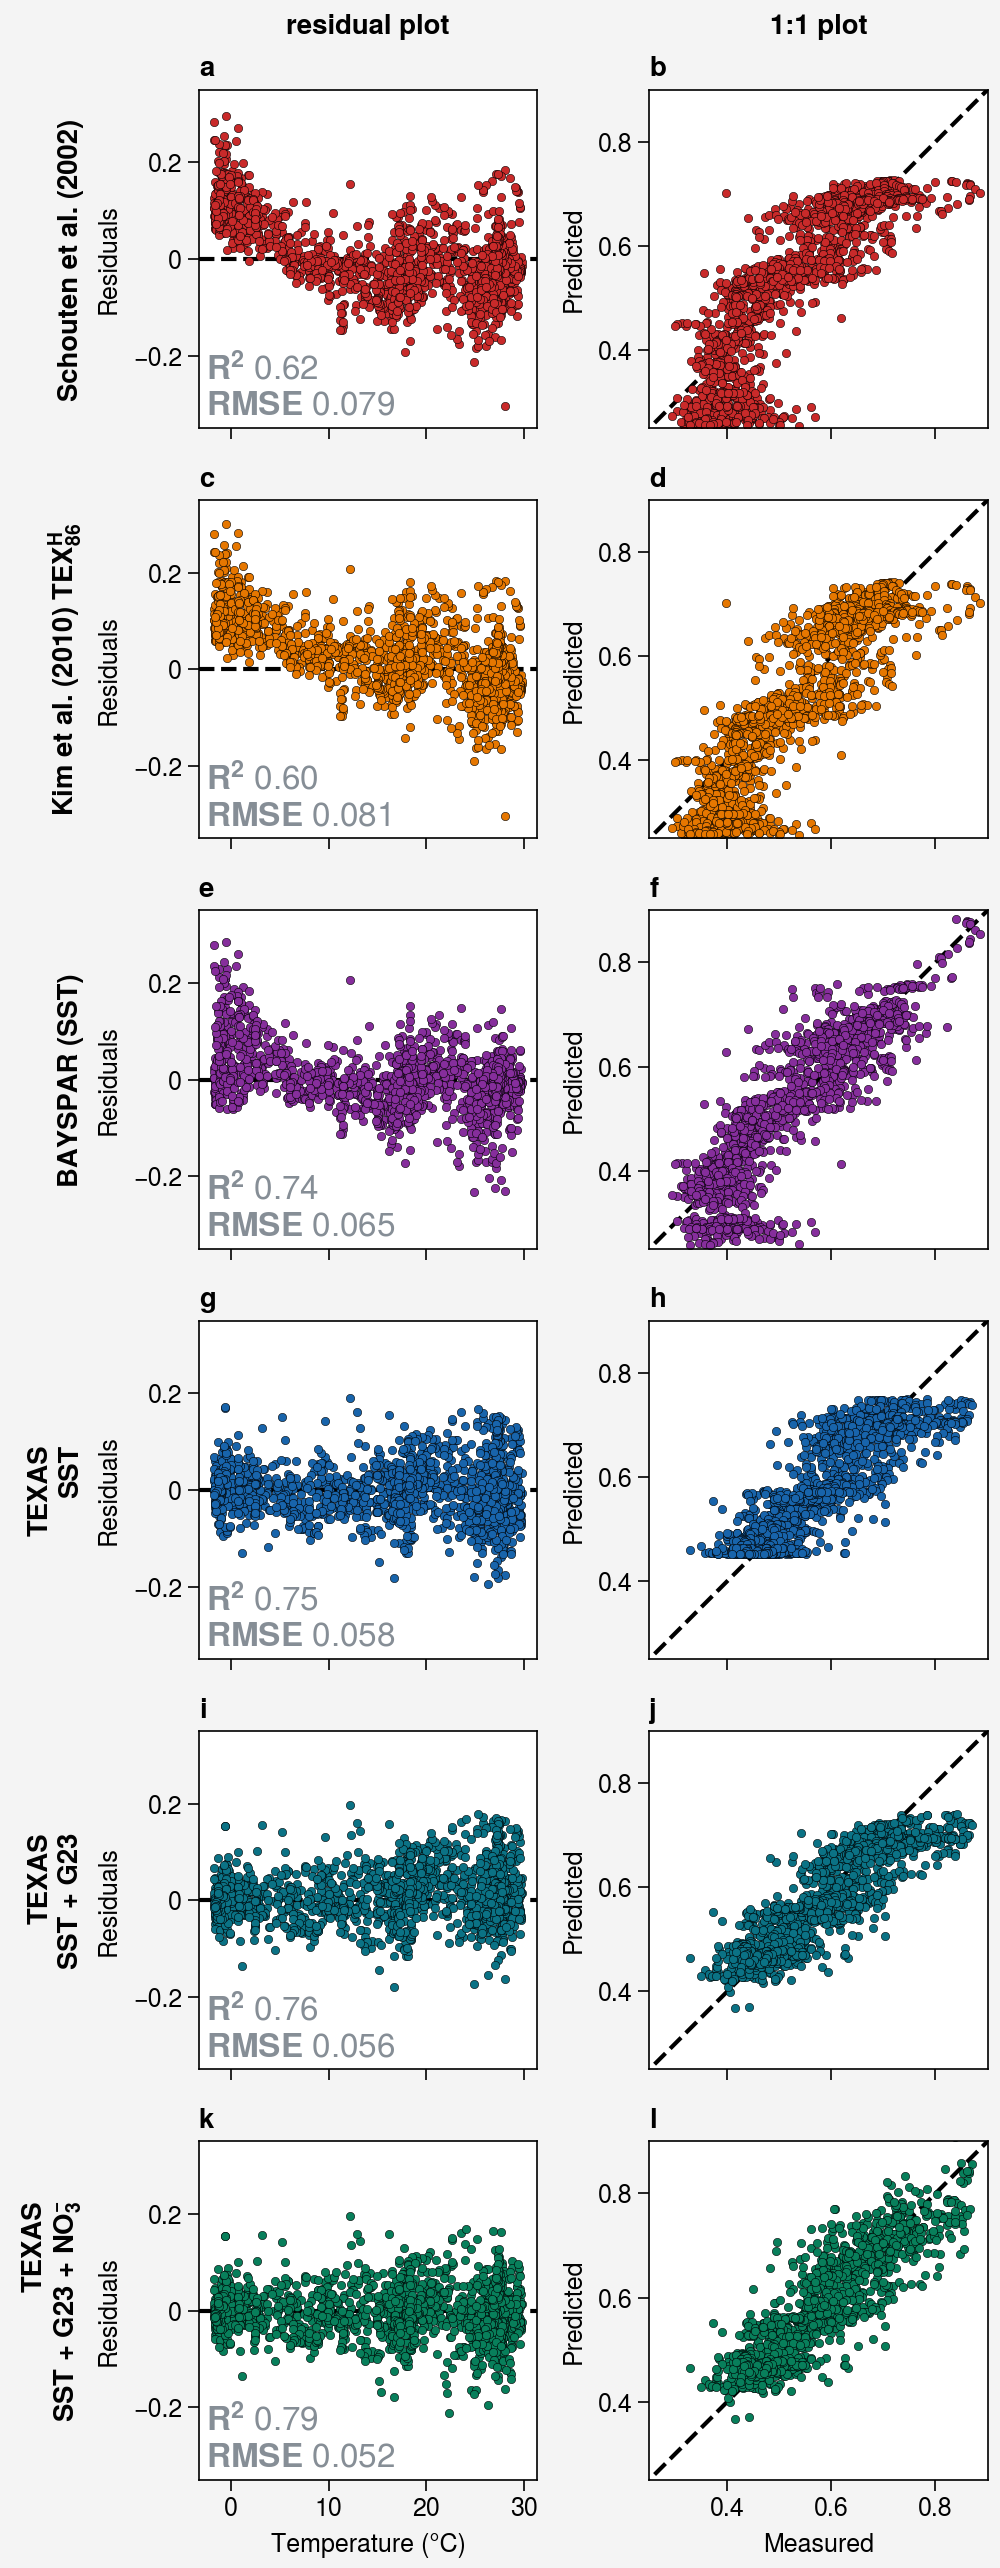

In [79]:
temp_param = 'SST'
y_param = 'scaledRI_cren3'
data = [
    (coretop_df[temp_param], coretop_df['TEX86'], pred_TEX_schouten02, TEX_residuals_schouten02, 'red9', 'Schouten et al. (2002)'),
    (coretop_df[temp_param], coretop_df['TEX86'], pred_TEX_kim2010, TEX_residuals_kim2010, 'yellow9', r'Kim et al. (2010) TEX$_{86}^H$'),
    (coretop_df[temp_param], coretop_df['TEX86'], pred_TEX_BAYSPAR_SST, TEX_residuals_BAYSPAR_SST, 'grape9', 'BAYSPAR (SST)'),
    
    (coretop_df[temp_param], coretop_df[y_param], 
     coretop_df[f"pred_{y_param}_{temp_param}only"], coretop_df[f"{y_param}_res_{temp_param}only"], 'blue9', f'TEXAS\n{temp_param}'),
    (coretop_df[temp_param], coretop_df[y_param], 
     coretop_df[f"pred_{y_param}_{temp_param}_g23r"], coretop_df[f"{y_param}_res_{temp_param}_g23r"], 'cyan9', f'TEXAS\n{temp_param} + G23'),
    (coretop_df[temp_param], coretop_df[y_param], 
     coretop_df[f"pred_{y_param}_{temp_param}_g23r_no3"], coretop_df[f"{y_param}_res_{temp_param}_g23r_no3"], 'teal9', f'TEXAS\n{temp_param} '+r'+ G23 + NO$_{3}^{-}$'),    
]

fig, axs = plot.subplots(width=5, ncols=2, nrows=len(data), share=0,)
axs.format(collabels=['residual plot', '1:1 plot'],)

metrics = []
row_labels = []
for _, measured, predicted, residuals, _, _ in data:
    nonnan_idx = ~np.isnan(residuals) & ~np.isnan(measured)
    r2 = r2_score(measured[nonnan_idx], predicted[nonnan_idx])
    rmse = np.sqrt(np.mean(residuals[nonnan_idx]**2))
    metrics.append((r2, rmse))
    

for i, ((predictor, measured, predicted, residuals, color, method_label),
        (r2, rmse)) in enumerate(zip(data, metrics)):
    row_labels.append(method_label)
    # Column 0: Map of residuals
    ax = axs[i, 0]
    text = f'$\\mathbf{{R^2}}$ {r2:.2f}\n$\\mathbf{{RMSE}}$ {rmse:.3f}'
    ax.text(0.02,0.02, text, transform=ax.transAxes,
            fontsize=12, ha='left', va='bottom', c='gray6')
    
    # Column 1: Residuals vs Temperature
    ax = axs[i, 0]
    ax.scatter(predictor, residuals, m='.', c=color, mec='k', mew=0.2, zorder=2)
    ax.axhline(0, c='k', ls='--', zorder=0)
    ax.format(
        xticks=np.arange(0, 40.1, 10)
    )
    
    # Column 2: Predicted vs Measured
    ax = axs[i, 1]
    ax.scatter(measured, predicted, m='.', c=color, mec='k', mew=0.2, zorder=2)
    ax.plot([0.2, 1], [0.2, 1], c='k', ls='--', zorder=0)
    ax.format(
        xticks=np.arange(0.2, 0.91, 0.2),
        yticks=np.arange(0.2, 0.91, 0.2),
    )
    

axs[:, 0].format(xlabel='Temperature (°C)', ylabel='Residuals', ylim=(-0.35, 0.35), tickminor=False)
axs[:, 1].format(xlim=(0.25,0.9), ylim=(0.25,0.9), tickminor=False, xlabel='Measured', ylabel='Predicted')
axs[:-1, :].format(xlabel='',xticklabels=[])
axs.format(grid=False,rowlabels=row_labels)

plot.rc['abc'] = False

fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fname = 'figSxx_comparison_all_calibrations_residuals_maps_and_scatterplots.pdf'
fig.savefig(os.path.join(fpath,fname), dpi=300)

In [80]:
fpath = f'{local_github_path}/data/spreadsheets/published_data'
fname = 'Kim2010_coretop.xlsx'
kim2010_coretop_df = pd.read_excel(os.path.join(fpath,fname)).rename(
    columns={
        'Satellite T (°C)':'SST',
        'TEX86 ':'TEX86'
    }
)

kim2010_coretop_df['predSST'] = predictSSTfromTEX(
    kim2010_coretop_df['TEX86'],method_name='kim2010_tex86H'
)
kim2010_coretop_df['predTEX'] = predictTEXfromSST(
    kim2010_coretop_df['SST'],method_name='kim2010_tex86H'
)



In [81]:
print(r"R^2:", r2_score(kim2010_coretop_df['TEX86'],kim2010_coretop_df['predTEX']))

residuals = kim2010_coretop_df['TEX86'] - kim2010_coretop_df['predTEX']
rmse = np.sqrt(np.mean(residuals**2))
print("RMSE:", rmse)

R^2: 0.6350387954004244
RMSE: 0.08616691232988934


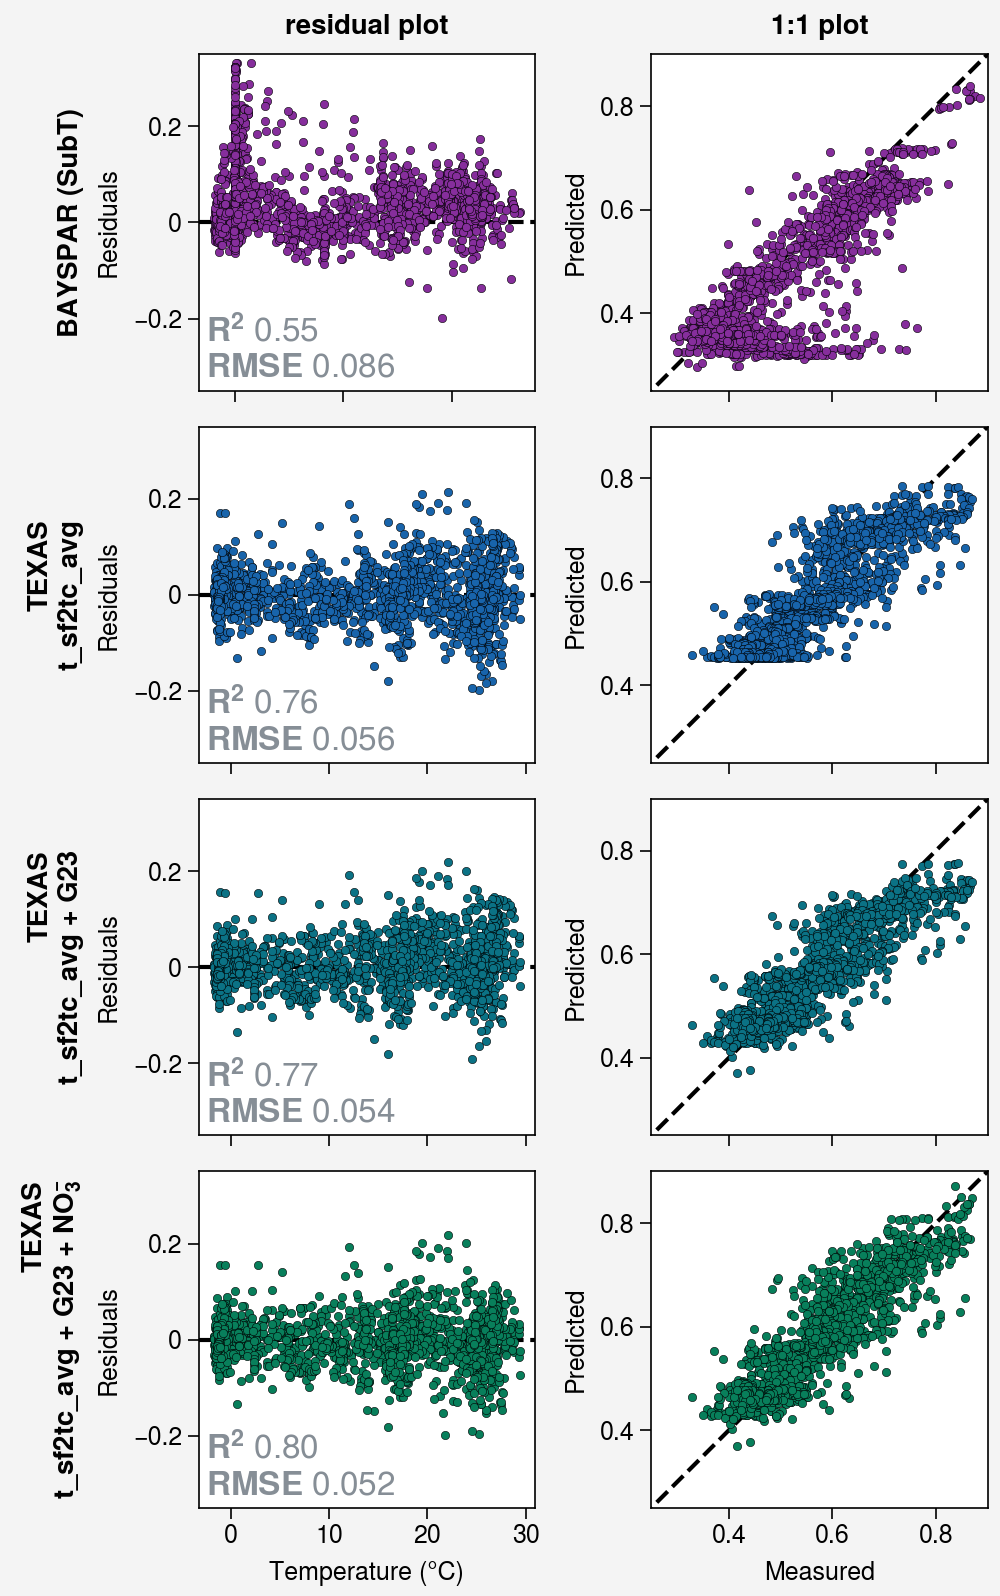

In [82]:
temp_param = 't_sf2tc_avg'
y_param = 'scaledRI_cren3'
data = [
    (coretop_df["subT_gamma"], coretop_df['TEX86'], pred_TEX_BAYSPAR_subT, TEX_residuals_BAYSPAR_subT, 'grape9', 'BAYSPAR (SubT)'),
    
    (coretop_df[temp_param], coretop_df[y_param], 
     coretop_df[f"pred_{y_param}_{temp_param}only"], coretop_df[f"{y_param}_res_{temp_param}only"], 'blue9', f'TEXAS\n{temp_param}'),
    (coretop_df[temp_param], coretop_df[y_param], 
     coretop_df[f"pred_{y_param}_{temp_param}_g23r"], coretop_df[f"{y_param}_res_{temp_param}_g23r"], 'cyan9', f'TEXAS\n{temp_param} + G23'),
    (coretop_df[temp_param], coretop_df[y_param], 
     coretop_df[f"pred_{y_param}_{temp_param}_g23r_no3"], coretop_df[f"{y_param}_res_{temp_param}_g23r_no3"], 'teal9', f'TEXAS\n{temp_param} '+r'+ G23 + NO$_{3}^{-}$'),    
]

fig, axs = plot.subplots(width=5, ncols=2, nrows=len(data), share=0,)
axs.format(collabels=['residual plot', '1:1 plot'],)
metrics = []
row_labels = []
for _, measured, predicted, residuals, _, _ in data:
    nonnan_idx = ~np.isnan(residuals) & ~np.isnan(measured)
    r2 = r2_score(measured[nonnan_idx], predicted[nonnan_idx])
    rmse = np.sqrt(np.mean(residuals[nonnan_idx]**2))
    metrics.append((r2, rmse))
    

for i, ((predictor, measured, predicted, residuals, color, method_label),
        (r2, rmse)) in enumerate(zip(data, metrics)):
    row_labels.append(method_label)
    # Column 0: Map of residuals
    ax = axs[i, 0]
    text = f'$\\mathbf{{R^2}}$ {r2:.2f}\n$\\mathbf{{RMSE}}$ {rmse:.3f}'
    ax.text(0.02,0.02, text, transform=ax.transAxes,
            fontsize=12, ha='left', va='bottom', c='gray6')
    
    # Column 1: Residuals vs Temperature
    ax = axs[i, 0]
    ax.scatter(predictor, residuals, m='.', c=color, mec='k', mew=0.2, zorder=2)
    ax.axhline(0, c='k', ls='--', zorder=0)
    ax.format(
        xticks=np.arange(0, 40.1, 10)
    )
    
    # Column 2: Predicted vs Measured
    ax = axs[i, 1]
    ax.scatter(measured, predicted, m='.', c=color, mec='k', mew=0.2, zorder=2)
    ax.plot([0.2, 1], [0.2, 1], c='k', ls='--', zorder=0)
    ax.format(
        xticks=np.arange(0.2, 0.91, 0.2),
        yticks=np.arange(0.2, 0.91, 0.2),
    )
    

axs[:, 0].format(xlabel='Temperature (°C)', ylabel='Residuals', ylim=(-0.35, 0.35), tickminor=False)
axs[:, 1].format(xlim=(0.25,0.9), ylim=(0.25,0.9), tickminor=False, xlabel='Measured', ylabel='Predicted')
axs[:-1, :].format(xlabel='',xticklabels=[])
axs.format(grid=False,rowlabels=row_labels)

plot.rc['abc'] = False

fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fname = 'figSxx_comparison_all_calibrations_residuals_maps_and_scatterplots.pdf'
fig.savefig(os.path.join(fpath,fname), dpi=300)

Auto cache path: /home/micromamba/app/data/cache/kriged_halo_1.0deg_10dmax_woa23_SST_scaledRI_cren3_proxy_residual.npz
Parallel kriging: 6 panels on 6 workers ...


  [1] Kriging halo: Schouten et al. (2002) ...
  [2] Kriging halo: Kim et al. (2010) TEX$_{86}^H$ ...
  [3] Kriging halo: BAYSPAR (SST) ...
  [4] Kriging halo: SST ...
  [6] Kriging halo: SST + G23 + NO$_3$ ...
  [5] Kriging halo: SST + G23 ...
  [1] nugget=0.0042  sill=71.7832  range=0.002
  [2] nugget=0.0036  sill=69.3363  range=0.002
  [3] nugget=0.0021  sill=75.2424  range=0.002
  [4] nugget=0.0020  sill=49.0372  range=0.001
  [6] nugget=0.0010  sill=55.0533  range=0.002
  [5] nugget=0.0015  sill=34.6423  range=0.002
  [1] done. unmasked=40754
  [4] done. unmasked=40754
  [6] done. unmasked=40754
  [3] done. unmasked=40754
  [2] done. unmasked=40754
  [5] done. unmasked=40754
Saved halo cache → /home/micromamba/app/data/cache/kriged_halo_1.0deg_10dmax_woa23_SST_scaledRI_cren3_proxy_residual.npz
True grids built (6 panels)
Saved → /home/micromamba/app/figures/manuscript/finalized/main-text/fig8_comparison_all_calibrations_proxy_residuals_maps_scaledRI_cren3_SST_and_scatterplots


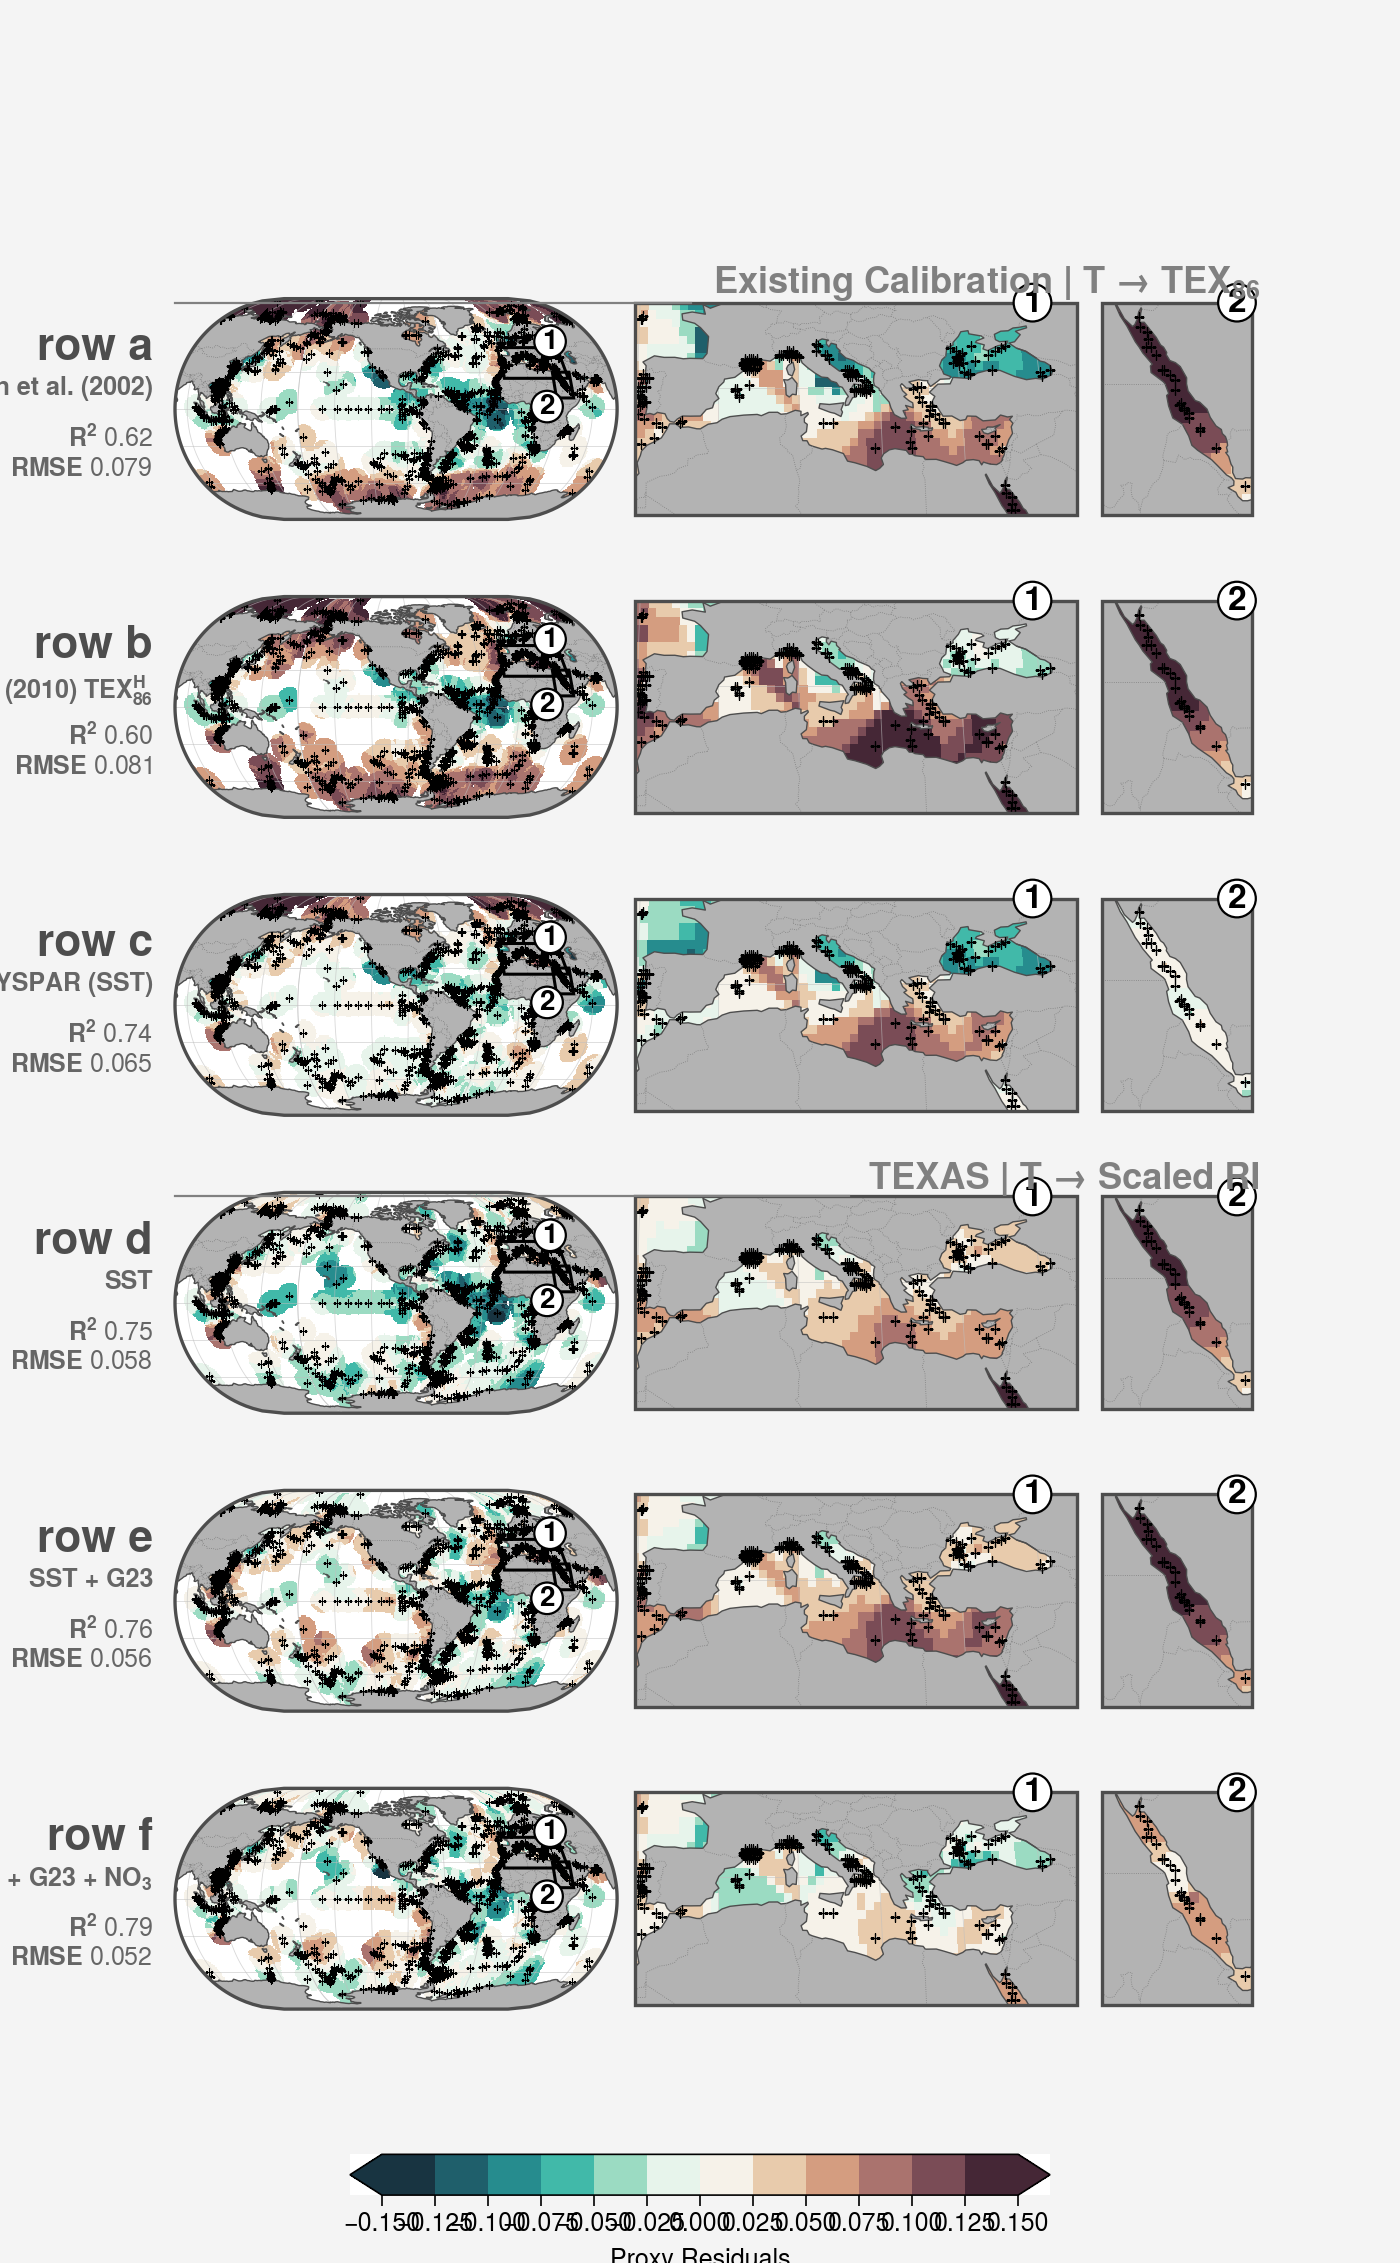

In [83]:
from TEXAS.plotting import plot_residual_maps

# ── Coordinates ───────────────────────────────────────────────────────────────                                                            
lons = coretop_df["match_lon_04deg"].values
lats = coretop_df["match_lat_04deg"].values                                                                                                 
                
# ── Config ────────────────────────────────────────────────────────────────────
y_param        = "scaledRI_cren3"   # or "scaledRI_cren3"
sel_temp_param = "SST"        # or "t_sf2tc_avg"                                                                                            
KRIGE_RES      = 1.0
MAX_DIST_DEG   = 10.0                                                                                                                       
    
# ── data: list of (measured, proxy, predicted, residuals, color, label) ───────
data = [                                                                                                                                    
    # ── Existing calibrations ─────────────────────────────────────────────
    (coretop_df[sel_temp_param], coretop_df["TEX86"],
    pred_TEX_schouten02,  TEX_residuals_schouten02,  "red9",    "Schouten et al. (2002)"),                                                 
    (coretop_df[sel_temp_param], coretop_df["TEX86"],                                                                                       
    pred_TEX_kim2010,     TEX_residuals_kim2010,     "yellow9", r"Kim et al. (2010) TEX$_{86}^H$"),                                        
    (coretop_df[sel_temp_param], coretop_df["TEX86"],                                                                                       
    pred_TEX_BAYSPAR_SST, TEX_residuals_BAYSPAR_SST, "grape9",  "BAYSPAR (SST)"),
    # ── TEXAS ─────────────────────────────────────────────────────────────                                                                
    (coretop_df[sel_temp_param], coretop_df[y_param],
    coretop_df[f"pred_{y_param}_{sel_temp_param}only"],      coretop_df[f"{y_param}_res_{sel_temp_param}only"],      "blue9", sel_temp_param),                           
    (coretop_df[sel_temp_param], coretop_df[y_param],
    coretop_df[f"pred_{y_param}_{sel_temp_param}_g23r"],     coretop_df[f"{y_param}_res_{sel_temp_param}_g23r"],     "cyan9", "SST + G23"),                              
    (coretop_df[sel_temp_param], coretop_df[y_param],                                                                                       
    coretop_df[f"pred_{y_param}_{sel_temp_param}_g23r_no3"], coretop_df[f"{y_param}_res_{sel_temp_param}_g23r_no3"], "teal9", r"SST + G23 + NO$_3$"),                    
]   
                
fig, axs = plot_residual_maps(                                                                                                        
    data, lons, lats,
    temp_param   = sel_temp_param,                                                                                                          
    y_param      = y_param,
    residual_tag = 'proxy_residual',
    recompute    = True,                                                                                                                   
    krige_res    = KRIGE_RES,
    max_dist_deg = MAX_DIST_DEG,
    cmap='DryWet_r',
    vlim = 0.15,   
    boundary_step = 0.025,
    annotations  = [(40, 55, "1"), (23, 2, "2")],                                                                                           
    section_headers = [
        (0, 0, r"Existing Calibration | T → TEX$_{86}$"),                                                                                   
        (3, 3, "TEXAS | T → Scaled RI"),                                                                                                    
    ],
    save_dir = os.path.join(local_github_path, "figures", "manuscript", "finalized", "main-text"),                                          
    fname    = f"fig8_comparison_all_calibrations_proxy_residuals_maps_{y_param}_{sel_temp_param}_and_scatterplots",
)


In [ ]:
# from TEXAS.plotting import plot_residual_maps                                                                                         
    
# # ── Coordinates ───────────────────────────────────────────────────────────────                                                            
# lons = coretop_df["match_lon_04deg"].values
# lats = coretop_df["match_lat_04deg"].values                                                                                                 
                
# # ── Config ────────────────────────────────────────────────────────────────────
# y_param        = "scaledRI_cren3"   # or "scaledRI_cren3"
# sel_temp_param = "t_sf2tc_avg"        # or "t_sf2tc_avg"  
# temp_label     = "Thermo-T"                                                                                           
# KRIGE_RES      = 1.0
# MAX_DIST_DEG   = 10.0                                                                                                 
    
# # ── data: list of (measured, proxy, predicted, residuals, color, label) ───────
# data = [                                                                                                                                    
#     # ── Existing calibrations ─────────────────────────────────────────────                                    
#     (coretop_df["subT_gamma"], coretop_df["TEX86"],                                                                                       
#     pred_TEX_BAYSPAR_subT, TEX_residuals_BAYSPAR_subT, "grape9",  "BAYSPAR (SubT)"),
#     # ── TEXAS ─────────────────────────────────────────────────────────────                                                                
#     (coretop_df[sel_temp_param], coretop_df[y_param],
#     coretop_df[f"pred_{y_param}_{sel_temp_param}only"], coretop_df[f"{y_param}_res_{sel_temp_param}only"],      "blue9", f"{temp_label}"),                           
#     (coretop_df[sel_temp_param], coretop_df[y_param],
#     coretop_df[f"pred_{y_param}_{sel_temp_param}_g23r"], coretop_df[f"{y_param}_res_{sel_temp_param}_g23r"],     "cyan9", f"{temp_label} + G23"),                              
#     (coretop_df[sel_temp_param], coretop_df[y_param],                                                                                       
#     coretop_df[f"pred_{y_param}_{sel_temp_param}_g23r_no3"], coretop_df[f"{y_param}_res_{sel_temp_param}_g23r_no3"], "teal9", f"{temp_label} "+r"+ G23 + NO$_3$"),                    
# ] 
                                                                                                                                  
# # ── Plot ──────────────────────────────────────────────────────────────────────                                                            
# fig, axs = plot_residual_maps(
#     data, lons, lats,             
#     temp_param      = sel_temp_param,
#     y_param         = y_param,
#     residual_tag    = 'proxy_residual',                                                                                                          
#     recompute       = False,
#     krige_res       = KRIGE_RES,                                                                                                            
#     max_dist_deg    = MAX_DIST_DEG,
#     cmap            = "DryWet",            
#     vlim            = 0.15,   
#     boundary_step   = 0.025,
#     annotations     = [(40, 55, "1"), (23, 2, "2")],   
#     hspace          = [4, 1, 1],    # big gap above row 1 (BAYSPAR → TEXAS)                                                                                        
#     section_headers = [
#         (0, 0, r"Existing Calibration | T → TEX$_{86}$"),                                                                                   
#         (1, 1, "TEXAS | T → Scaled RI"),                                                                                                    
#     ],
#     save_dir = os.path.join(local_github_path, "figures", "manuscript", "finalized", "main-text"),                                          
#     fname    = f"figSxx_comparison_all_calibrations_proxy_residuals_maps_{y_param}_{sel_temp_param}_and_scatterplots",
# )

# Predict temperatures from proxy values

In [140]:
# pred_SST_BAYSPAR_TEX86 = np.full(len(coretop_df), np.nan)
# for i, row in tqdm(coretop_df.iterrows()):
#     tex = row['TEX86']
#     if not np.isnan(tex):
#         pred_SST_BAYSPAR_TEX86[i] = bsr.predict_seatemp(
#             np.atleast_1d(tex),
#             lat=row['match_lat_04deg'],
#             lon=row['match_lon_04deg'],
#             prior_mean=row['SST'],
#             prior_std=10,
#             temptype='sst'
#         ).percentile(50)[0]
        
# display(pred_SST_BAYSPAR_TEX86)

# pred_subT_BAYSPAR_TEX86 = np.full(len(coretop_df), np.nan)
# for i, row in tqdm(coretop_df.iterrows()):
#     tex = row['TEX86']
#     if not np.isnan(tex):
#         pred_subT_BAYSPAR_TEX86[i] = bsr.predict_seatemp(
#             np.atleast_1d(tex),
#             lat=row['match_lat_04deg'],
#             lon=row['match_lon_04deg'],
#             prior_mean=row['subT_gamma'],
#             prior_std=10,
#             temptype='subt'
#         ).percentile(50)[0]
        
# pred_subT_BAYSPAR_TEX86
        
# ## Save for reuse
# a = coretop_df[['match_lat_04deg', 'match_lon_04deg']]
# b = pd.DataFrame(pred_SST_BAYSPAR_TEX86,columns=['predT_bsr_sst'])
# c = pd.DataFrame(pred_subT_BAYSPAR_TEX86,columns=['predT_bsr_subt'])

# pred_temp_BAYSPAR_p50_df = pd.concat([a,b,c],axis=1)
# fpath = f'{local_github_path}/data/spreadsheets'
# fname = 'predT_bayspar_p50.csv'
# pred_temp_BAYSPAR_p50_df.to_csv(os.path.join(fpath,fname),index=False)

## load result
fpath = f'{local_github_path}/data/spreadsheets'
fname = 'predT_bayspar_p50.csv'
pred_temp_BAYSPAR_p50_df = pd.read_csv(os.path.join(fpath,fname))
pred_SST_BAYSPAR_TEX86 = pred_temp_BAYSPAR_p50_df['predT_bsr_sst']
pred_subT_BAYSPAR_TEX86 = pred_temp_BAYSPAR_p50_df['predT_bsr_subt']

In [141]:
# #### ── BAYSPAR predictions — p16, p50, p84 ─────────────────────────────
# #### Uncomment the computation block to regenerate; loads from CSV by default.

# pred_SST_BAYSPAR_TEX86_p16 = np.full(len(coretop_df), np.nan)
# pred_SST_BAYSPAR_TEX86_p50 = np.full(len(coretop_df), np.nan)
# pred_SST_BAYSPAR_TEX86_p84 = np.full(len(coretop_df), np.nan)
# pred_subT_BAYSPAR_TEX86_p16 = np.full(len(coretop_df), np.nan)
# pred_subT_BAYSPAR_TEX86_p50 = np.full(len(coretop_df), np.nan)
# pred_subT_BAYSPAR_TEX86_p84 = np.full(len(coretop_df), np.nan)

# for i, row in tqdm(coretop_df.iterrows()):
#     tex = row['TEX86']
#     if not np.isnan(tex):
#         res_sst  = bsr.predict_seatemp(
#             np.atleast_1d(tex),
#             lat=row['match_lat_04deg'], lon=row['match_lon_04deg'],
#             prior_mean=row['SST'], prior_std=10, temptype='sst',
#         )
#         pred_SST_BAYSPAR_TEX86_p16[i] = res_sst.percentile(16)[0]
#         pred_SST_BAYSPAR_TEX86_p50[i] = res_sst.percentile(50)[0]
#         pred_SST_BAYSPAR_TEX86_p84[i] = res_sst.percentile(84)[0]

#         res_subt = bsr.predict_seatemp(
#             np.atleast_1d(tex),
#             lat=row['match_lat_04deg'], lon=row['match_lon_04deg'],
#             prior_mean=row['subT_gamma'], prior_std=10, temptype='subt',
#         )
#         pred_subT_BAYSPAR_TEX86_p16[i] = res_subt.percentile(16)[0]
#         pred_subT_BAYSPAR_TEX86_p50[i] = res_subt.percentile(50)[0]
#         pred_subT_BAYSPAR_TEX86_p84[i] = res_subt.percentile(84)[0]

# ## Save for reuse
# pred_temp_BAYSPAR_df = pd.concat([
#     coretop_df[['match_lat_04deg', 'match_lon_04deg']],
#     pd.DataFrame({
#         'predT_bsr_sst_p16':  pred_SST_BAYSPAR_TEX86_p16,
#         'predT_bsr_sst_p50':  pred_SST_BAYSPAR_TEX86_p50,
#         'predT_bsr_sst_p84':  pred_SST_BAYSPAR_TEX86_p84,
#         'predT_bsr_subt_p16': pred_subT_BAYSPAR_TEX86_p16,
#         'predT_bsr_subt_p50': pred_subT_BAYSPAR_TEX86_p50,
#         'predT_bsr_subt_p84': pred_subT_BAYSPAR_TEX86_p84,
#     }),
# ], axis=1)
# fpath = f'{local_github_path}/data/spreadsheets'
# pred_temp_BAYSPAR_df.to_csv(os.path.join(fpath, 'predT_bayspar_p16_p50_p84.csv'), index=False)

#### Load results
fpath = f'{local_github_path}/data/spreadsheets'
pred_temp_BAYSPAR_df = pd.read_csv(os.path.join(fpath, 'predT_bayspar_p16_p50_p84.csv'))

pred_SST_BAYSPAR_TEX86     = pred_temp_BAYSPAR_df['predT_bsr_sst_p50']
pred_SST_BAYSPAR_TEX86_p16 = pred_temp_BAYSPAR_df['predT_bsr_sst_p16']
pred_SST_BAYSPAR_TEX86_p84 = pred_temp_BAYSPAR_df['predT_bsr_sst_p84']

pred_subT_BAYSPAR_TEX86     = pred_temp_BAYSPAR_df['predT_bsr_subt_p50']
pred_subT_BAYSPAR_TEX86_p16 = pred_temp_BAYSPAR_df['predT_bsr_subt_p16']
pred_subT_BAYSPAR_TEX86_p84 = pred_temp_BAYSPAR_df['predT_bsr_subt_p84']

# TEXAS frequentist

In [142]:

#####################################

YYY = np.linspace(0,1,100)
predT_thermoT_Tonly_frequentist = inverse_generalized_logistic_model_fixed_upper(YYY,*res_hier_glob_fixed_thermoT['popt_global'])

In [143]:
# from concurrent.futures import ProcessPoolExecutor, as_completed
# from TEXAS.data.builder import InvTConfig
# import numpy as np

# # ── Config ───────────────────────────────────────────────────────────────────
# BATCH_SIZE = 300
# N_DRAWS    = 300
# DATE_TAG   = "032326"

# TEMPTYPE_MAP = {
#     "SST":         "SST",
#     "t_sf2tc_avg": "thermoT",
# }

# # 2D map: (x_param, y_param) → NO3 cutoff string in the fwd posterior filename
# NO3_CUTOFF_MAP = {
#     ("SST",         "scaledRI"):       "1.8",
#     ("SST",         "scaledRI_cren3"): "1.8",   # confirm if different
#     ("t_sf2tc_avg", "scaledRI"):       "1.8",
#     ("t_sf2tc_avg", "scaledRI_cren3"): "1.9",   # only this combo uses 1.9
# }

# def _get_fwd_post_list(x_param, y_param):
#     temptype   = TEMPTYPE_MAP[x_param]
#     proxy_name = y_param
#     no3_cutoff = NO3_CUTOFF_MAP[(x_param, y_param)]
#     pfx = "gen_logi_fixed_hier_crtp"
#     return [
#         f"{pfx}_univ_priorApprox_{temptype}_{proxy_name}_{DATE_TAG}",
#         f"{pfx}_multiv_priorApprox_{temptype}_gdgt23ratio_{proxy_name}_{DATE_TAG}",
#         f"{pfx}_multiv_priorApprox_{temptype}_gdgt23ratio_no3_{no3_cutoff}_{proxy_name}_{DATE_TAG}",
#     ]

# def _get_predictors(fwd_post_name, df):
#     predictors = {}
#     if 'gdgt23ratio' in fwd_post_name:
#         predictors['gdgt23ratio'] = df['gdgt23ratio'].to_numpy(dtype=float)
#     if 'no3' in fwd_post_name:
#         predictors['no3'] = df['no3_sf2tc_avg'].to_numpy(dtype=float)
#     return predictors

# def _run_one(fwd_post_name, proxyObs, prior_mu_t, predictors, temptype, 
#              batch_size, n_draws, y_param, date_tag):
#     from TEXAS.predict import predict_T_from_proxyObs
#     from TEXAS.data.builder import InvTConfig

#     n = len(proxyObs)
#     p5_parts, p50_parts, p95_parts = [], [], []

#     for i, start in enumerate(range(0, n, batch_size)):
#         end = min(start + batch_size, n)
#         batch_preds = {k: v[start:end] for k, v in predictors.items()}

#         result = predict_T_from_proxyObs(
#             proxyObs          = proxyObs[start:end],
#             prior_mu_t        = prior_mu_t[start:end],
#             prior_sigma_t     = 10,
#             fwd_posterior_name = fwd_post_name,
#             predictors        = batch_preds,
#             site_name         = f'global_coretop_b{i}',
#             constraint_type   = 'unconstrained',
#             temptype          = temptype,                                                                                                   
#             proxy_name        = y_param,       # ← fixes y_param_tag                                                                        
#             filename_tag      = date_tag,      # ← fixes date_tag
#             config            = InvTConfig(n_draws=n_draws),
#             save_results      = True,
#             iter_warmup       = 300,
#             iter_sampling     = 1000,
#             threads_per_chain = 3,
#         )
#         p5_parts.append(result['p5'])
#         p50_parts.append(result['p50'])
#         p95_parts.append(result['p95'])
#         print(f"  [{fwd_post_name}] batch {i+1}/{-(-n//batch_size)} done")

#     return fwd_post_name, {
#         'p5':  np.concatenate(p5_parts),
#         'p50': np.concatenate(p50_parts),
#         'p95': np.concatenate(p95_parts),
#     }


# def run_invT_parallel(x_param, y_param, df, max_workers=2):
#     """
#     Run inverse-T for all three forward posteriors matching (x_param, y_param).
#     Returns {fwd_post_name: {'p5', 'p50', 'p95'}}.
#     """
#     temptype      = TEMPTYPE_MAP[x_param]
#     fwd_post_list = _get_fwd_post_list(x_param, y_param)
#     proxyObs      = df[y_param].to_numpy(dtype=float)
#     prior_mu_t    = df[x_param].to_numpy(dtype=float)

#     results = {}
#     with ProcessPoolExecutor(max_workers=max_workers) as pool:
#         futures = {
#             pool.submit(
#                 _run_one,
#                 fwd_post,
#                 proxyObs,
#                 prior_mu_t,
#                 _get_predictors(fwd_post, df),
#                 temptype,
#                 BATCH_SIZE,
#                 N_DRAWS,                                                                                                                    
#                 y_param,
#                 DATE_TAG,
#             ): fwd_post
#             for fwd_post in fwd_post_list
#         }
#         for future in as_completed(futures):
#             fwd_post = futures[future]
#             try:
#                 name, res = future.result()
#                 results[name] = res
#                 print(f"✅ {name} | N={res['p50'].shape[0]} | NaNs={np.isnan(res['p50']).sum()}")
#             except Exception as e:
#                 print(f"❌ {fwd_post}: {e}")
#     return results


# # ── Run ──────────────────────────────────────────────────────────────────────
# all_results = {}   # keyed by (x_param, y_param)

# for x_param in ["SST", "t_sf2tc_avg"]:
#     for y_param in ["scaledRI", "scaledRI_cren3"]:
#         print(f"\n{'='*60}")
#         print(f"x={x_param}  y={y_param}  →  temptype={TEMPTYPE_MAP[x_param]}")
#         print(f"  posteriors: {_get_fwd_post_list(x_param, y_param)}")
#         print('='*60)
#         all_results[(x_param, y_param)] = run_invT_parallel(
#             x_param, y_param, coretop_df
#         )


In [ ]:
import re
CACHE = Path(f'{local_github_path}/data/cache/TEXAS_invT_posterior_cache')
_BATCH_PAT = re.compile(r'^(.+)_b(\d+)_(.+)\.nc$')
def _model_label(stem: str) -> str:
    if "no3" in stem:
        return "multiv_no3"
    if "gdgt23" in stem or "multiv" in stem:                                                                                                
        return "multiv_g23"                                                                                                                 
    return "univ"                                                                                                                           
    
    
def combine_batches(base_name: str, cache_dir: Path = CACHE) -> xr.Dataset:
    batch_files = []                                                                                                                        
    for f in sorted(cache_dir.glob("*.nc")):
        m = _BATCH_PAT.match(f.name)
        if m and f"{m.group(1)}_{m.group(3)}.nc" == base_name:                                                                              
            batch_files.append((int(m.group(2)), f))
    
    if not batch_files:
        raise ValueError(f"No batch files found for {base_name!r} in {cache_dir}")                                                          
                
    batch_files.sort()
    datasets = []
    for _, f in batch_files:                                                                                                                
        ds = xr.open_dataset(f)
        ds.load()                                                                                                                           
        ds.close()                                                                                                                          
        datasets.append(ds)
    
    combined = xr.concat(datasets, dim="t_est_dim_0")                                                                                       
    combined.attrs = datasets[0].attrs.copy()
    combined.attrs["SiteName"] = re.sub(r"_b\d+$", "", datasets[0].attrs.get("SiteName", ""))                                               
    combined.attrs["combined_from_batches"] = [str(f) for _, f in batch_files]                                                              
    return combined                                                                                                                         




# ── Discover all batch groups and combine ────────────────────────────────────
all_nc   = sorted(CACHE.glob("*.nc"))                                                                                                       
base_names = sorted({
    f"{m.group(1)}_{m.group(3)}.nc"                                                                                                         
    for f in all_nc                                                                                                                         
    if (m := _BATCH_PAT.match(f.name))                                                                                                      
})                                                                                                                                 
    
# ── Build structured dict: (temptype, proxy_name, model_label) → Dataset ─────
combined_datasets = {}                                                                                                                      
for base in base_names:
    ds = combine_batches(base)
    key = (                                                                                                                                 
        ds.attrs.get("temptype", "unknown"),
        ds.attrs.get("proxy_name", "unknown"),   # read from attrs, not filename                                                            
        _model_label(base),                                                                                                                 
    )
    combined_datasets[key] = ds                                                                                                             
    print(f"  {key}  →  {ds['t_est'].sizes}")


  ('SST', 'scaledRI', 'multiv_no3')  →  Frozen({'quantile': 13, 't_est_dim_0': 1513})
  ('SST', 'scaledRI_cren3', 'multiv_no3')  →  Frozen({'quantile': 13, 't_est_dim_0': 1513})
  ('SST', 'scaledRI', 'multiv_g23')  →  Frozen({'quantile': 13, 't_est_dim_0': 1513})
  ('SST', 'scaledRI_cren3', 'multiv_g23')  →  Frozen({'quantile': 13, 't_est_dim_0': 1513})
  ('thermoT', 'scaledRI', 'multiv_no3')  →  Frozen({'quantile': 13, 't_est_dim_0': 1513})
  ('thermoT', 'scaledRI_cren3', 'multiv_no3')  →  Frozen({'quantile': 13, 't_est_dim_0': 1513})
  ('thermoT', 'scaledRI', 'multiv_g23')  →  Frozen({'quantile': 13, 't_est_dim_0': 1513})
  ('thermoT', 'scaledRI_cren3', 'multiv_g23')  →  Frozen({'quantile': 13, 't_est_dim_0': 1513})
  ('SST', 'scaledRI', 'univ')  →  Frozen({'quantile': 13, 't_est_dim_0': 1513})
  ('SST', 'scaledRI_cren3', 'univ')  →  Frozen({'quantile': 13, 't_est_dim_0': 1513})
  ('thermoT', 'scaledRI', 'univ')  →  Frozen({'quantile': 13, 't_est_dim_0': 1513})
  ('thermoT', 'scaledR

In [145]:
# Calculate TEX86 predictions and residuals
pred_TfromTEX_schouten02 = predictSSTfromTEX(coretop_df['TEX86'], method_name='schouten02')
pred_TfromTEX_kim2010 = predictSSTfromTEX(coretop_df['TEX86'], method_name='kim2010_tex86H')

T_residuals_schouten02 = coretop_df['SST'] - pred_TfromTEX_schouten02
T_residuals_kim2010 = coretop_df['SST'] - pred_TfromTEX_kim2010
T_residuals_BAYSPAR_SST = coretop_df['SST'] - pred_SST_BAYSPAR_TEX86
T_residuals_BAYSPAR_subT = coretop_df['subT_gamma'] - pred_subT_BAYSPAR_TEX86

# T residual plots

In [146]:
temp_param = 'SST'
y_param = 'scaledRI_cren3'
temp_param2 = 'thermoT'
a = combined_datasets.get((temp_param,y_param,'univ'))['t_est'].sel(quantile=0.5).values
b = combined_datasets.get((temp_param2,y_param,'univ'))['t_est'].sel(quantile=0.5).values

length of non-nan values above 10C: 1038
173     10.002810
179     10.375910
182     10.117700
183     11.198910
186     10.441910
          ...    
1290    10.001890
1298    10.839991
1300    10.628610
1303    10.586990
1308    10.227490
Name: SST, Length: 1038, dtype: float64
length of non-nan values above 10C: 1038
173     10.002810
179     10.375910
182     10.117700
183     11.198910
186     10.441910
          ...    
1290    10.001890
1298    10.839991
1300    10.628610
1303    10.586990
1308    10.227490
Name: SST, Length: 1038, dtype: float64
length of non-nan values above 10C: 1038
173     10.002810
179     10.375910
182     10.117700
183     11.198910
186     10.441910
          ...    
1290    10.001890
1298    10.839991
1300    10.628610
1303    10.586990
1308    10.227490
Name: SST, Length: 1038, dtype: float64
length of non-nan values above 10C: 1038
173     10.002810
179     10.375910
182     10.117700
183     11.198910
186     10.441910
          ...    
1290    10.001

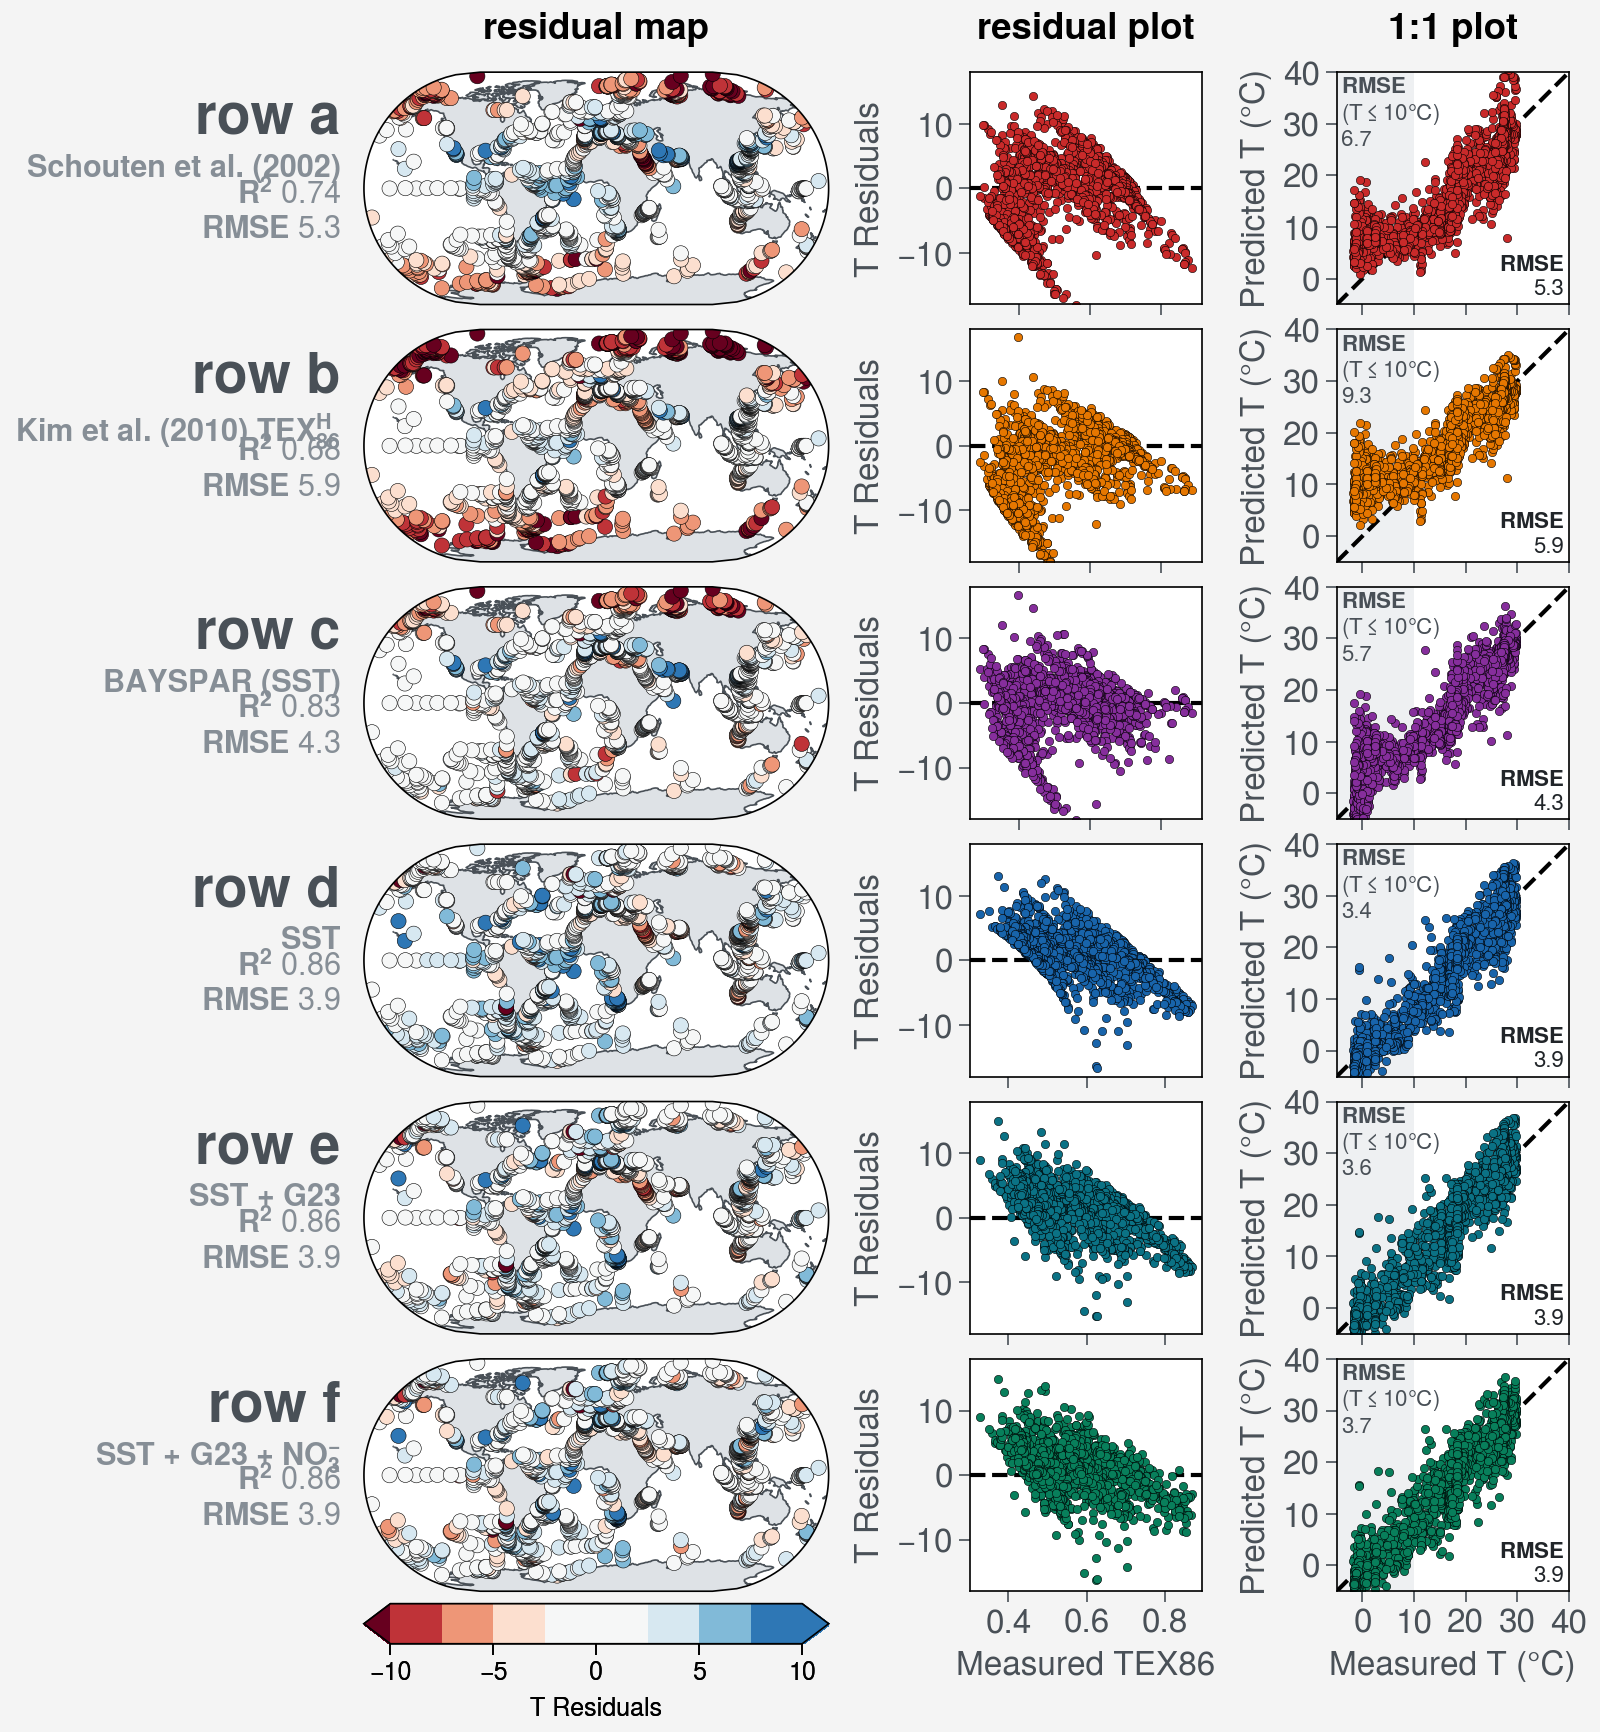

In [147]:
%matplotlib inline  
# ============================================================================
# FIGURE 1: TEX86 (Previous Work)
# ============================================================================
temp_param = 'SST'
y_param = 'scaledRI_cren3'

predT_TEXAS = combined_datasets.get((temp_param,y_param,'univ'))['t_est'].sel(quantile=0.5).values
predT_TEXAS_g23r_corr = combined_datasets.get((temp_param,y_param,'multiv_g23'))['t_est'].sel(quantile=0.5).values
predT_TEXAS_g23r_no3_corr = combined_datasets.get((temp_param,y_param,'multiv_no3'))['t_est'].sel(quantile=0.5).values

Tres_TEXAS = coretop_df[temp_param] - predT_TEXAS
Tres_TEXAS_g23r = coretop_df[temp_param] - predT_TEXAS_g23r_corr
Tres_TEXAS_g23r_no3 = coretop_df[temp_param] - predT_TEXAS_g23r_no3_corr

# TEX86 data: (measured, predicted, residuals, color, method_label)
data = [
    (coretop_df['TEX86'], coretop_df[temp_param], pred_TfromTEX_schouten02, T_residuals_schouten02, 'red9', 'Schouten et al. (2002)'),
    (coretop_df['TEX86'], coretop_df[temp_param], pred_TfromTEX_kim2010, T_residuals_kim2010, 'yellow9', r'Kim et al. (2010) TEX$_{86}^H$'),
    (coretop_df['TEX86'], coretop_df[temp_param], pred_SST_BAYSPAR_TEX86, T_residuals_BAYSPAR_SST, 'grape9', 'BAYSPAR (SST)'),
    
    (coretop_df[y_param], coretop_df[temp_param], predT_TEXAS, Tres_TEXAS, 'blue9', f'{temp_param}'),
    (coretop_df[y_param], coretop_df[temp_param], predT_TEXAS_g23r_corr, Tres_TEXAS_g23r, 'cyan9', f'{temp_param} + G23'),
    (coretop_df[y_param], coretop_df[temp_param], predT_TEXAS_g23r_no3_corr, Tres_TEXAS_g23r_no3, 'teal9', f'{temp_param}'+r' + G23 + NO$_{3}^{-}$')
    
]

# Calculate metrics
metrics = []
for _, measured, predicted, residuals, _, _ in data:
    # print(f"Type of measured: {measured.dtype}, Type of predicted: {predicted.dtype}, Type of residuals: {residuals.dtype}")
    nonnan_idx = ~np.isnan(residuals) & ~np.isnan(measured)
    r2 = r2_score(measured[nonnan_idx], predicted[nonnan_idx])
    rmse = np.sqrt(np.mean(residuals[nonnan_idx]**2))
    metrics.append((r2, rmse))
    
metrics_above10C = []
for _, measured, predicted, residuals, _, _ in data:
    mask = measured > 10
    nonnan_idx = mask & ~np.isnan(residuals) & ~np.isnan(measured)
    r2_above10C = r2_score(measured[nonnan_idx], predicted[nonnan_idx])
    rmse_above10C = np.sqrt(np.mean(residuals[nonnan_idx]**2))
    metrics_above10C.append((r2_above10C, rmse_above10C))
    print(f"length of non-nan values above 10C: {np.sum(nonnan_idx)}")
    print(measured[nonnan_idx])
    
metrics_below10C = []
for _, measured, predicted, residuals, _, _ in data:
    mask = measured <= 10
    nonnan_idx = mask & ~np.isnan(residuals) & ~np.isnan(measured)
    r2_below10C = r2_score(measured[nonnan_idx], predicted[nonnan_idx])
    rmse_below10C = np.sqrt(np.mean(residuals[nonnan_idx]**2))
    metrics_below10C.append((r2_below10C, rmse_below10C))
    print(f"length of non-nan values below 10C: {np.sum(nonnan_idx)}")
    print(measured[nonnan_idx])

# Create TEX86 figure
fig, axs = plot.subplots(
    proj={1:'eck3', 4:'eck3', 7:'eck3', 10:'eck3', 13:'eck3', 16:'eck3'},
    width=8, ncols=3, nrows=6, share=0, wratios=[2, 1, 1],
    hspace=1
)

axs.format(
    land=True, landzorder=0, landcolor='gray3',
    coast=True, coastzorder=1, coastcolor='gray7',
    lonlines=30, latlines=30, fontsize=12,
    collabels=['residual map', 'residual plot', '1:1 plot'],
)

norm = FlatCenterNormalize(vmin=-10, vmax=10, center=0, plateau_width=2)
row_labels_letter = ['a', 'b', 'c', 'd', 'e', 'f']


# Plot TEX86 rows
for i, ((predictor, measured, predicted, residuals, color, method_label), 
        (r2, rmse), (r2_above10C, rmse_above10C), (r2_below10C, rmse_below10C)) in enumerate(zip(data, metrics, metrics_above10C, metrics_below10C)):
    
    # Column 0: Map of residuals
    ax = axs[i, 0]
    sc = ax.scatter(
        coretop_df['match_lon_04deg'],
        coretop_df['match_lat_04deg'],
        c=residuals,
        cmap='BuRd_r',
        levels=np.linspace(-10,10,9),
        norm=norm,  # <-- Diverging norm centers at 0
        extend='both',
        m='o',
        s=30,
        zorder=2,
        mec='k',
        mew=0.2
    )
    
    text = 'row '+row_labels_letter[i]
    ax.text(-0.05, 0.68, text, transform=ax.transAxes,
            fontsize=20, fontweight='bold', ha='right', va='bottom',
            c='gray7')
    
    # Add method label
    ax.text(-0.05, 0.65, method_label, transform=ax.transAxes,
            fontsize=11, fontweight='bold', ha='right', va='top', c='gray6')
    
    # Add metrics
    text = f'$\\mathbf{{R^2}}$ {r2:.2f}\n$\\mathbf{{RMSE}}$ {rmse:.1f}'
    ax.text(-0.05, 0.4, text, transform=ax.transAxes,
            fontsize=11, ha='right', va='center', c='gray6')
    
    # Column 1: Residuals vs Temperature
    ax = axs[i, 1]
    ax.scatter(predictor, residuals, m='.', c=color, mec='k', mew=0.2, zorder=2)
    ax.axhline(0, c='k', ls='--', zorder=0)
    ax.format(
        xticks=np.arange(0, 1.1, 0.2),
    )
    
    # Column 2: Predicted vs Measured
    ax = axs[i, 2]
    ax.scatter(measured, predicted, m='.', c=color, mec='k', mew=0.2, zorder=2)
    ax.plot([-5, 40], [-5, 40], c='k', ls='--', zorder=0)
    ax.format(
        xticks=np.arange(0,41, 10),
        yticks=np.arange(0,41, 10),
    )
    
    text = f"$\\mathbf{{RMSE}}$\n{rmse:.1f}"
    ax.text(0.98, 0.02, text, transform=ax.transAxes,
            fontsize=8, ha='right', va='bottom', color='gray9')
    
    rect = Rectangle((-5, -5), 15, 45, transform=ax.transData, 
                     facecolor='gray3',alpha=0.5,zorder=0)
    ax.add_patch(rect)
    
    text = r"$\mathbf{{RMSE}}$"+"\n"+r"(T$\leq$10$\degree$C)"+f"\n{rmse_below10C:.1f}"
    ax.text(0.02, 0.98, text, transform=ax.transAxes,
            fontsize=8, ha='left', va='top', color='gray7')

# Format TEX86 figure
axs[-1, 0].colorbar(sc, loc='b', label=r'T Residuals', extend='both')
axs[:, 0].format(yticklabels=[])
axs[:, 1].format(xlabel='Measured TEX86', ylabel='T Residuals', ylim=(-18, 18), tickminor=False)
axs[:, 2].format(xlim=(-5,40), ylim=(-5,40), tickminor=False, 
                     xlabel='Measured T (°C)', ylabel='Predicted T (°C)')

axs[:-1, :].format(xlabel='',xticklabels=[])
axs.format(
    grid=False,
    labelcolor='gray7',
    xtickcolor='gray7', xticklabelcolor='gray7',
    ytickcolor='gray7', yticklabelcolor='gray7',
)

plot.rc['abc'] = False
fig.show()
fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fig.savefig(os.path.join(fpath,f'fig11_TEX86_calibrations_{temp_param}_residuals_{y_param}_maps_and_scatterplots.pdf'), dpi=300)

In [ ]:
# from TEXAS.plotting import plot_residual_maps                                                                                         
    
# # ── Coordinates ───────────────────────────────────────────────────────────────                                                            
# lons = coretop_df["match_lon_04deg"].values                                                                                                 
# lats = coretop_df["match_lat_04deg"].values                                                                                                 
    
# # ── Config ────────────────────────────────────────────────────────────────────                                                            
# sel_temp_param = "SST"
# temp_param_alt = "SST"
# y_param        = "scaledRI_cren3"     # key used in combined_datasets                                                                             
# KRIGE_RES      = 1.0                                                                                                                        
# MAX_DIST_DEG   = 10.0                                                                                                                       
    
# # ── Predictions + residuals from invT combined_datasets ──────────────────────                                                             
# predT_TEXAS          = combined_datasets.get((temp_param_alt, y_param, "univ"))["t_est"].sel(quantile=0.5).values                       
# predT_TEXAS_g23r     = combined_datasets.get((temp_param_alt, y_param, "multiv_g23"))["t_est"].sel(quantile=0.5).values                         
# predT_TEXAS_g23r_no3 = combined_datasets.get((temp_param_alt, y_param, "multiv_no3"))["t_est"].sel(quantile=0.5).values                         
    
# Tres_TEXAS          = coretop_df[sel_temp_param] - predT_TEXAS                                                                              
# Tres_TEXAS_g23r     = coretop_df[sel_temp_param] - predT_TEXAS_g23r                                                                         
# Tres_TEXAS_g23r_no3 = coretop_df[sel_temp_param] - predT_TEXAS_g23r_no3
    
# # ── data: (predictor, measured, predicted, residuals, color, label) ───────────                                                            
# data = [
#     (coretop_df['TEX86'], coretop_df[temp_param], pred_TfromTEX_schouten02, T_residuals_schouten02, 'red9', 'Schouten et al. (2002)'),
#     (coretop_df['TEX86'], coretop_df[temp_param], pred_TfromTEX_kim2010, T_residuals_kim2010, 'yellow9', r'Kim et al. (2010) TEX$_{86}^H$'),
#     (coretop_df['TEX86'], coretop_df[temp_param], pred_SST_BAYSPAR_TEX86, T_residuals_BAYSPAR_SST, 'grape9', 'BAYSPAR (SST)'),
    
#     (coretop_df[y_param], coretop_df[sel_temp_param], predT_TEXAS,              Tres_TEXAS,                 "blue9",  f"{temp_param_alt}"),       
#     (coretop_df[y_param], coretop_df[sel_temp_param], predT_TEXAS_g23r,         Tres_TEXAS_g23r,            "cyan9",  f"{temp_param_alt} + G23"), 
#     (coretop_df[y_param], coretop_df[sel_temp_param], predT_TEXAS_g23r_no3,     Tres_TEXAS_g23r_no3,        "teal9",  fr"{temp_param_alt} + G23 + NO$_3$"),                                                                                                                                   
# ]
                                                                                                                                        
# # ── Plot ──────────────────────────────────────────────────────────────────────                                                            
# fig, axs = plot_residual_maps(
#     data, lons, lats,
#     temp_param      = sel_temp_param,
#     y_param         = y_param,
#     residual_tag    = 'temp_residual',                                                                                                          
#     recompute       = True,
#     krige_res       = KRIGE_RES,                                                                                                            
#     max_dist_deg    = MAX_DIST_DEG,
#     vlim            = 10.0,                                                                                                                 
#     boundary_step   = 2.0,
#     cmap            = "RdBu",                                                                                                             
#     colorbar_label  = "T Residuals (°C)",
#     rmse_fmt        = ".1f",                                                                                                                
#     rmse_unit       = "°C",                                                                                                                 
#     hspace          = [1, 1, 4, 1, 1],    # big gap above row 1 (BAYSPAR → TEXAS)
#     annotations     = [(40, 55, "1"), (23, 2, "2")],                                                                                        
#     section_headers = [                                                                                                                     
#         (0, 0, fr"Existing Calibration | TEX$_{86}$ → T ({temp_param_alt})"),                                                                                   
#         (3, 3, f"TEXAS | Scaled RI → T ({temp_param_alt})"),                                                                                                    
#     ],          
#     save_dir = os.path.join(local_github_path, "figures", "manuscript", "finalized", "main-text"),                                          
#     fname    = f"fig11_TEX86_calibrations_{sel_temp_param}_T_residuals_{y_param}_maps",                                                                                 
# )  

In [ ]:
# from TEXAS.plotting import plot_residual_maps                                                                                         
    
# # ── Coordinates ───────────────────────────────────────────────────────────────                                                            
# lons = coretop_df["match_lon_04deg"].values                                                                                                 
# lats = coretop_df["match_lat_04deg"].values                                                                                                 
    
# # ── Config ────────────────────────────────────────────────────────────────────                                                            
# sel_temp_param = "t_sf2tc_avg"
# temp_param_alt = "thermoT"
# y_param        = "scaledRI_cren3"     # key used in combined_datasets                                                                             
# KRIGE_RES      = 1.0                                                                                                                        
# MAX_DIST_DEG   = 10.0                                                                                                                       
    
# # ── Predictions + residuals from invT combined_datasets ──────────────────────                                                             
# predT_TEXAS          = combined_datasets.get((temp_param_alt, y_param, "univ"))["t_est"].sel(quantile=0.5).values                       
# predT_TEXAS_g23r     = combined_datasets.get((temp_param_alt, y_param, "multiv_g23"))["t_est"].sel(quantile=0.5).values                         
# predT_TEXAS_g23r_no3 = combined_datasets.get((temp_param_alt, y_param, "multiv_no3"))["t_est"].sel(quantile=0.5).values                         
    
# Tres_TEXAS          = coretop_df[sel_temp_param] - predT_TEXAS                                                                              
# Tres_TEXAS_g23r     = coretop_df[sel_temp_param] - predT_TEXAS_g23r                                                                         
# Tres_TEXAS_g23r_no3 = coretop_df[sel_temp_param] - predT_TEXAS_g23r_no3                                                                     
    
# # ── data: (predictor, measured, predicted, residuals, color, label) ───────────                                                            
# data = [                                                                                                                                    
#     (coretop_df["TEX86"], coretop_df["subT_gamma"], pred_subT_BAYSPAR_TEX86,  T_residuals_BAYSPAR_subT,   "grape9", "BAYSPAR (SubT)"), 
#     (coretop_df[y_param], coretop_df[sel_temp_param], predT_TEXAS,              Tres_TEXAS,                 "blue9",  f"{temp_param_alt}"),       
#     (coretop_df[y_param], coretop_df[sel_temp_param], predT_TEXAS_g23r,         Tres_TEXAS_g23r,            "cyan9",  f"{temp_param_alt} + G23"), 
#     (coretop_df[y_param], coretop_df[sel_temp_param], predT_TEXAS_g23r_no3,     Tres_TEXAS_g23r_no3,        "teal9",  fr"{temp_param_alt} + G23 + NO$_3$"),                                                                                                                                   
# ]   
    
                                                                                                                                  
# # ── Plot ──────────────────────────────────────────────────────────────────────                                                            
# fig, axs = plot_residual_maps(
#     data, lons, lats,             
#     temp_param      = sel_temp_param,
#     y_param         = y_param,
#     residual_tag    = 'temp_residual',                                                                                                          
#     recompute       = True,
#     krige_res       = KRIGE_RES,                                                                                                            
#     max_dist_deg    = MAX_DIST_DEG,
#     vlim            = 10.0,                                                                                                                 
#     boundary_step   = 2.0,
#     cmap            = "RdBu",                                                                                                             
#     colorbar_label  = "T Residuals (°C)",
#     rmse_fmt        = ".1f",                                                                                                                
#     rmse_unit       = "°C",                                                                                                                 
#     hspace          = [4, 1, 1],    # big gap above row 1 (BAYSPAR → TEXAS)
#     annotations     = [(40, 55, "1"), (23, 2, "2")],                                                                                        
#     section_headers = [                                                                                                                     
#         (0, 0, r"Existing Calibration | TEX$_{86}$ → T (subT; gamma$_{200m}$)"),                                                                                   
#         (1, 1, f"TEXAS | Scaled RI → T ({temp_param_alt})"),                                                                                                    
#     ],          
#     save_dir = os.path.join(local_github_path, "figures", "manuscript", "finalized", "main-text"),                                          
#     fname    = f"fig11_TEX86_calibrations_{sel_temp_param}_T_residuals_{y_param}_maps",                                                                                 
# )  

# Uncertainty maps

In [150]:
pred_SST_BAYSPAR_TEX86

0        2.440497
1       -1.809790
2       -1.897142
3       -4.648953
4       -4.043832
          ...    
1508     6.471235
1509     6.005429
1510     9.155602
1511    14.694745
1512    14.020997
Name: predT_bsr_sst_p50, Length: 1513, dtype: float64

In [151]:
# # ============================================================================
# # FIGURE: ±1σ Uncertainty Maps
# # ============================================================================
# %matplotlib inline
# import numpy as np
# import pandas as pd
# import os
# from TEXAS.plotting.residual_maps import plot_residual_maps

# # ── Read predictions ─────────────────────────────────────────────────
# lons = coretop_df['match_lon_04deg'].values
# lats = coretop_df['match_lat_04deg'].values

# def _read_texas(fname, quantile):
#     return combined_datasets.get(fname)['t_est'].sel(quantile=quantile).values

# temp_param = 'SST'
# y_param = 'scaledRI_cren3'
# temp_param_bsr = 'SST'
# _fname_univ = (temp_param,y_param,'univ')
# _fname_g23  = (temp_param,y_param,'multiv_g23')
# _fname_g23_no3  = (temp_param,y_param,'multiv_no3')

# predT_TEXAS_T_p16     = _read_texas(_fname_univ, 0.16)
# predT_TEXAS_T_p84     = _read_texas(_fname_univ, 0.84)
# predT_TEXAS_T_g23r_p16 = _read_texas(_fname_g23, 0.16)
# predT_TEXAS_T_g23r_p84 = _read_texas(_fname_g23, 0.84)
# predT_TEXAS_T_g23r_no3_p16 = _read_texas(_fname_g23_no3, 0.16)
# predT_TEXAS_T_g23r_no3_p84 = _read_texas(_fname_g23_no3, 0.84)

# def _sigma(p16, p84):
#     return (p84 - p16) / 2

# sigmas = {
#     'bayspar': _sigma(pred_SST_BAYSPAR_TEX86_p16, pred_SST_BAYSPAR_TEX86_p84),
#     'univ':    _sigma(predT_TEXAS_T_p16,         predT_TEXAS_T_p84),
#     'g23':     _sigma(predT_TEXAS_T_g23r_p16,    predT_TEXAS_T_g23r_p84),
#     'g23_no3': _sigma(predT_TEXAS_T_g23r_no3_p16, predT_TEXAS_T_g23r_no3_p84),
# }



# # ── data list ────────────────────────────────────────────────────────
# _variants = [
#     ('bayspar', 'grape9', f'BAYSPAR ({temp_param_bsr})'),
#     ('univ',    'blue9',  f'{temp_param}'),
#     ('g23',     'cyan9',  f'{temp_param} + G23'),
#     ('g23_no3', 'teal9',  f'{temp_param}'+r' + G23 + NO$_3$'),
# ]

# print("lons length:", len(lons))
# for vkey, _, label in _variants:
#     s = sigmas[vkey]
#     print(f"  {label:<45}  len={len(s)}  nan={np.sum(np.isnan(s))}")

# data = [
#     (None, None, None, pd.Series(sigmas[vkey]), color, label)
#     for vkey, color, label in _variants
# ]

# # ── Summary ──────────────────────────────────────────────────────────
# print("±1σ summary (°C):")
# for (vkey, _, label), (_, _, _, s, _, _) in zip(_variants, data):
#     v = s.values
#     print(f"  {label:<45}  median={np.nanmedian(v):.1f}  "
#         f"p5={np.nanpercentile(v,5):.1f}  p95={np.nanpercentile(v,95):.1f}")

# # ── Row annotations (median σ) ────────────────────────────────────────
# row_annotations = [
#     f"$\\mathbf{{\\tilde{{\\sigma}}}}$ {np.nanmedian(sigmas[vkey]):.1f}°C"
#     for vkey, _, _ in _variants
# ]

# # ── Plot ──────────────────────────────────────────────────────────────
# fig, axs = plot_residual_maps(
#     data, lons, lats,
#     residual_tag = 'uncertainty',
#     recompute=False,
#     vmin=2.0, vmax=9.0, boundary_step=1,
#     cmap='spectral_r',
#     colorbar_label=r'$\pm 1\sigma$ Uncertainty (°C)',
#     row_annotations=row_annotations,
#     annotations=[(40, 55, "1"), (23, 2, "2")],
#     section_headers=[
#         (0, 0, r'Existing Calibration | Predictive Uncertainty ($\pm 1\sigma$)'),
#         (1, 1, r'TEXAS | Predictive Uncertainty ($\pm 1\sigma$)'),
#     ],
#     hspace=[4, 1, 1],
#     fig_width=7,
# )

# # ── Save ──────────────────────────────────────────────────────────────
# fpath = os.path.join(local_github_path, 'figures', 'manuscript', 'finalized', 'main-text')
# fname = f'fig9_TEXAS_1sigma_uncertainty_maps_p16p84_{temp_param}_{y_param}'
# fig.savefig(os.path.join(fpath, fname + '.png'), dpi=400, facecolor='white', bbox_inches='tight')
# fig.savefig(os.path.join(fpath, fname + '.pdf'), dpi=400, facecolor='white', bbox_inches='tight')
# print(f"Saved → {os.path.join(fpath, fname)}")

In [152]:
# # ============================================================================
# # FIGURE: ±1σ Uncertainty Maps
# # ============================================================================
# %matplotlib inline
# import numpy as np
# import pandas as pd
# import os
# from TEXAS.plotting.residual_maps import plot_residual_maps

# # ── Read predictions ─────────────────────────────────────────────────
# lons = coretop_df['match_lon_04deg'].values
# lats = coretop_df['match_lat_04deg'].values

# def _read_texas(fname, quantile):
#     return combined_datasets.get(fname)['t_est'].sel(quantile=quantile).values

# temp_param = 'thermoT'
# y_param = 'scaledRI_cren3'
# temp_param_bsr = 'SubT'
# _fname_univ = (temp_param,y_param,'univ')
# _fname_g23  = (temp_param,y_param,'multiv_g23')
# _fname_g23_no3  = (temp_param,y_param,'multiv_no3')

# predT_TEXAS_T_p16     = _read_texas(_fname_univ, 0.16)
# predT_TEXAS_T_p84     = _read_texas(_fname_univ, 0.84)
# predT_TEXAS_T_g23r_p16 = _read_texas(_fname_g23, 0.16)
# predT_TEXAS_T_g23r_p84 = _read_texas(_fname_g23, 0.84)
# predT_TEXAS_T_g23r_no3_p16 = _read_texas(_fname_g23_no3, 0.16)
# predT_TEXAS_T_g23r_no3_p84 = _read_texas(_fname_g23_no3, 0.84)

# def _sigma(p16, p84):
#     return (p84 - p16) / 2

# sigmas = {
#     'bayspar': _sigma(pred_subT_BAYSPAR_TEX86_p16, pred_subT_BAYSPAR_TEX86_p84),
#     'univ':    _sigma(predT_TEXAS_T_p16,         predT_TEXAS_T_p84),
#     'g23':     _sigma(predT_TEXAS_T_g23r_p16,    predT_TEXAS_T_g23r_p84),
#     'g23_no3': _sigma(predT_TEXAS_T_g23r_no3_p16, predT_TEXAS_T_g23r_no3_p84),
# }

# # ── data list ────────────────────────────────────────────────────────
# _variants = [
#     ('bayspar', 'grape9', f'BAYSPAR ({temp_param_bsr})'),
#     ('univ',    'blue9',  f'{temp_param}'),
#     ('g23',     'cyan9',  f'{temp_param} + G23'),
#     ('g23_no3', 'teal9',  f'{temp_param}'+r' + G23 + NO$_3$'),
# ]

# data = [
#     (None, None, None, pd.Series(sigmas[vkey]), color, label)
#     for vkey, color, label in _variants
# ]

# # ── Summary ──────────────────────────────────────────────────────────
# print("±1σ summary (°C):")
# for (vkey, _, label), (_, _, _, s, _, _) in zip(_variants, data):
#     v = s.values
#     print(f"  {label:<45}  median={np.nanmedian(v):.1f}  "
#         f"p5={np.nanpercentile(v,5):.1f}  p95={np.nanpercentile(v,95):.1f}")

# # ── Row annotations (median σ) ────────────────────────────────────────
# row_annotations = [
#     f"$\\mathbf{{\\tilde{{\\sigma}}}}$ {np.nanmedian(sigmas[vkey]):.1f}°C"
#     for vkey, _, _ in _variants
# ]

# # ── Plot ──────────────────────────────────────────────────────────────
# fig, axs = plot_residual_maps(
#     data, lons, lats,
#     residual_tag = 'uncertainty',
#     recompute=True,
#     vmin=2.0, vmax=12.0, boundary_step=1.0,
#     cmap='spectral_r',
#     colorbar_label=r'$\pm 1\sigma$ Uncertainty (°C)',
#     row_annotations=row_annotations,
#     annotations=[(40, 55, "1"), (23, 2, "2")],
#     section_headers=[
#         (0, 0, r'Existing Calibration | Predictive Uncertainty ($\pm 1\sigma$)'),
#         (1, 1, r'TEXAS | Predictive Uncertainty ($\pm 1\sigma$)'),
#     ],
#     hspace=[4, 1, 1],
#     fig_width=7,
# )

# # ── Save ──────────────────────────────────────────────────────────────
# fpath = os.path.join(local_github_path, 'figures', 'manuscript', 'finalized', 'main-text')
# fname = f'figXX_TEXAS_1sigma_uncertainty_maps_p16p84_{temp_param}_{y_param}'
# fig.savefig(os.path.join(fpath, fname + '.png'), dpi=400, facecolor='white', bbox_inches='tight')
# fig.savefig(os.path.join(fpath, fname + '.pdf'), dpi=400, facecolor='white', bbox_inches='tight')
# print(f"Saved → {os.path.join(fpath, fname)}")

In [153]:
# Replace both fig.savefig calls at the bottom with:
from matplotlib.backends.backend_pdf import FigureCanvasPdf
from matplotlib.backends.backend_agg import FigureCanvasAgg

FigureCanvasAgg(fig).print_figure(
    os.path.join(fpath, fname + '.png'),
    dpi=400, facecolor='white', bbox_inches='tight',
)
FigureCanvasPdf(fig).print_figure(
    os.path.join(fpath, fname + '.pdf'),
    dpi=400, facecolor='white', bbox_inches='tight',
)
print(f"Saved → {os.path.join(fpath, fname)}")

Saved → /home/micromamba/app/figures/manuscript/finalized/main-text/predT_bayspar_p50.csv


Forward r²:  0.7948
Inverse r²:  0.5532
r² drop:     0.2416


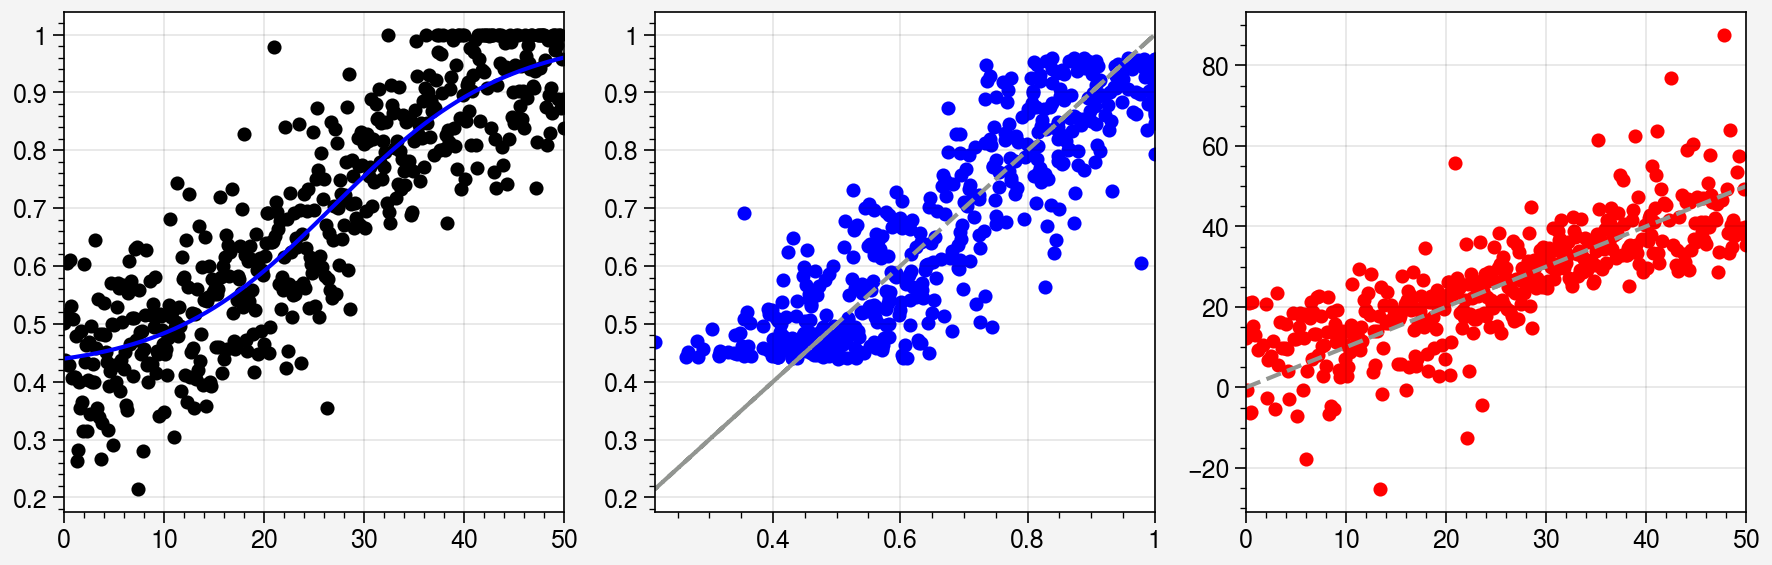

In [154]:
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

# Generate synthetic data with known relationship
T_true = np.linspace(0, 50, 500)
b, k, t0, v, Q = 0.428, 0.156, 28.605, 1.608, 1.918  # True parameters

# Perfect forward relationship (no noise!)
RI_true = b + (1 - b) / (1 + Q * np.exp(-k * (T_true - t0)))**(1/v)

# Add small measurement noise + capped max value to 1
np.random.seed(42)
RI_obs = RI_true + np.random.normal(0, 0.1, len(RI_true))
RI_obs = np.clip(RI_obs, 0, 1)  # Cap max value to 1


# Forward model: Predict RI from T
def sigmoid(T, b, k, t0, v, Q):
    return b + (1 - b) / (1 + Q * np.exp(-k * (T - t0)))**(1/v)

popt, _ = curve_fit(sigmoid, T_true, RI_obs)
RI_pred_forward = sigmoid(T_true, *popt)
r2_forward = r2_score(RI_obs, RI_pred_forward)

# Inverse model: Predict T from RI
# Invert the sigmoid analytically
def inverse_sigmoid(RI, b, k, t0, v, Q):
    return np.log( Q / (( (1 - b) / (RI - b) )**v - 1) ) / k + t0

T_pred_inverse = inverse_sigmoid(RI_obs, *popt)
nonnan_naninf_idx = ~np.isnan(T_pred_inverse) & ~np.isnan(T_true) & ~np.isinf(T_pred_inverse)
r2_inverse = r2_score(T_true[nonnan_naninf_idx], T_pred_inverse[nonnan_naninf_idx])

print(f"Forward r²:  {r2_forward:.4f}")
print(f"Inverse r²:  {r2_inverse:.4f}")
print(f"r² drop:     {r2_forward - r2_inverse:.4f}")

######
fig, axs = plot.subplots(ncols=3,share=0)

ax = axs[0]
ax.scatter(T_true, RI_obs, label='Observed', c='black', s=20)
ax.plot(T_true, RI_pred_forward, label='Forward Pred', c='blue')

ax = axs[1]
ax.scatter(RI_obs, RI_pred_forward, label='Forward Pred', c='blue', s=20)
ax.plot(RI_obs, RI_obs, label='1:1 Line', c='gray', ls='--')

ax = axs[2]
ax.scatter(T_true, T_pred_inverse, label='Inverse Pred', c='red', s=20)
ax.plot(T_true, T_true, label='1:1 Line', c='gray', ls='--')

axs.format(
    xreverse=False
)